# SolarTech Lab telemetry — per-day viewer

Prints the measured photovoltaic telemetry for a chosen set of days, as intensity against time of
day. These are the values the control agent of Section 11 would be reading.

Set `DAYS` to a list of integers. Each is a **day of year** in 2017, `1`–`365`.

The notebook also reports, for each requested day, the longest run of consecutive valid samples —
which is what decides whether that day can be fed to the decomposition notebook, since the model
needs `CANON_LEN = CTX + PRED = 544` contiguous samples and `PV_Power` is `NaN` outside daylight.

## 0, Configuration

In [118]:
# ------------------------------------------------------------------------------------- #
#  CONFIGURATION
# ------------------------------------------------------------------------------------- #
DAYS = [186, 158, 212, 15]        # day of year, 1-365. Any length; one panel per day.

CHANNEL   = "PV_Power"            # PV_Power | T_air | G_h | G_tilt | W_s | W_d
CSV_PATH  = "../data/dataset/Dataset-SolarTechLab.csv"

STACKED      = True               # one cumulative figure, the same panels one under another
OVERLAY      = True                # one extra figure with every requested day superimposed
SAVE_FIGURES = True
OUT_DIR      = "_run/solar"

# The tokenisation geometry the cpp/cps table below is written for.
REF_P, REF_S = 16, 16

# ------------------------------------------------------------------------------------- #
#  FORECAST (section 4). Set RUN_FORECAST = False to use the notebook without any model.
# ------------------------------------------------------------------------------------- #
RUN_FORECAST  = True
FCST_DAY      = 186               # day of year to forecast on
FCST_TIME     = "13:00"           # the cut: context is the day up to here, forecast is what follows
CONTEXT_MODE  = "window"          # "window" = the CONTEXT_LEN samples before the cut, crossing
                                  #            midnight into the previous days as needed
                                  # "day"    = only that calendar day, from 00:00 to the cut
                                  # "valid"  = only the unbroken observed stretch ending at the cut
CONTEXT_LEN   = 2048              # samples. Chronos-Bolt's context_length and the length the sweep
                                  # was trained at, so nothing is truncated by the pipeline.
DEVICE        = None              # None -> cuda when available, else cpu
BASE_MODEL_ID = "amazon/chronos-bolt-tiny"   # the published (16,16) checkpoint, not retrained

# Retrained geometries to forecast with. Each is loaded, used and released in turn, so the list
# costs run time rather than memory. The pairwise figures are drawn once per geometry, each
# against the published checkpoint; the grouped figures below use the whole list at once.
# FCST_GEOMETRIES = [(16, 16)]
# The full sweep, to paste over the line above when the grouped figures are wanted:
FCST_GEOMETRIES = [(8, 8), (16, 8), (16, 12), (16, 16),
                    (24, 8), (24, 12), (24, 16), (24, 20), (24, 24),
                    (32, 8), (32, 12), (32, 16), (32, 20), (32, 24), (32, 32)]
GROUP_MIN_MEMBERS       = 2       # a patch-size or stride group with fewer members is skipped
GROUP_INCLUDE_PUBLISHED = False   # see the note above the grouped figures before setting True

NAN_POLICY    = "zero_interp_short"   # recommended: missing = no production = 0, EXCEPT daylight
                                      #   gaps of at most SHORT_GAP minutes, which are interpolated
                                      # "zero"       = every missing sample -> 0
                                      # "zero_night" = only sun-below-horizon -> 0, rest left NaN
                                      # "mask"       = leave every NaN, the model masks them
SHORT_GAP     = 15                # minutes
SPIKE_MAX     = 1000.0            # PV_Power above this is a recording glitch, treated as missing
SITE_LAT, SITE_LON, SITE_TZ = 45.5028, 9.1560, 1.0    # SolarTech Lab, Milano; CET = UTC+1


## 1, Loading

The file is semicolon-separated with a `dd-MMM-yyyy HH:MM:SS` timestamp. Two things are cleaned on
the way in and both are properties of the recording, not of this notebook:

* `PV_Power` is `NaN` outside daylight. That is structural — the plant is not producing — so those
  samples are left as `NaN` rather than filled with zero, which would invent a signal.
* the weather channels carry `-999999` as a missing-value sentinel, which is mapped to `NaN`.

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

FS, CTX, PRED = 512, 480, 64          # the design's convention; see section 4 below
CANON_LEN = CTX + PRED

RAW = pd.read_csv(CSV_PATH, sep=";", parse_dates=["Time"], dayfirst=True)
RAW = RAW.replace(-999999.0, np.nan)
RAW["doy"] = RAW["Time"].dt.dayofyear
RAW["tod"] = RAW["Time"].dt.hour + RAW["Time"].dt.minute / 60.0

assert CHANNEL in RAW.columns, f"{CHANNEL} not in {list(RAW.columns)}"
UNITS = {"PV_Power": "W", "T_air": "°C", "G_h": "W/m²",
         "G_tilt": "W/m²", "W_s": "m/s", "W_d": "°"}
UNIT = UNITS.get(CHANNEL, "")

step = RAW["Time"].diff().mode()[0]
print(f"{len(RAW):,} rows   {RAW.Time.min().date()} → {RAW.Time.max().date()}   cadence {step}")
print(f"{CHANNEL}: {RAW[CHANNEL].notna().sum():,} valid "
      f"({100 * RAW[CHANNEL].notna().mean():.1f}%), "
      f"range {RAW[CHANNEL].min():.3g} – {RAW[CHANNEL].max():.3g} {UNIT}")


525,601 rows   2017-01-01 → 2018-01-01   cadence 0 days 00:01:00
PV_Power: 198,730 valid (37.8%), range 0.316 – 5.97e+04 W


## 2, What each requested day contains

`run` is the longest block of consecutive valid samples. A day is usable by the decomposition
notebook only when `run` reaches 544.

In [120]:
def longest_valid_run(values):
    """(length, start_index) of the longest consecutive non-NaN block."""
    ok = np.asarray(pd.notna(values))
    best = best_at = cur = 0
    start = 0
    for i, v in enumerate(ok):
        if v:
            if cur == 0:
                start = i
            cur += 1
            if cur > best:
                best, best_at = cur, start
        else:
            cur = 0
    return best, best_at


def day_frame(doy):
    d = RAW[RAW.doy == doy].sort_values("Time").reset_index(drop=True)
    if d.empty:
        raise ValueError(f"day {doy} is not in the file")
    return d


rows = []
for doy in DAYS:
    d = day_frame(doy)
    run, at = longest_valid_run(d[CHANNEL])
    rows.append({
        "doy": doy,
        "date": d.Time.iloc[0].date(),
        "samples": len(d),
        "valid": int(d[CHANNEL].notna().sum()),
        "run": run,
        "run_from": str(d.Time.iloc[at].time())[:5] if run else "-",
        "peak": round(float(d[CHANNEL].max()), 1) if d[CHANNEL].notna().any() else np.nan,
        "usable_544": "yes" if run >= CANON_LEN else "no",
    })
SUMMARY = pd.DataFrame(rows)
print(SUMMARY.to_string(index=False))


 doy       date  samples  valid  run run_from  peak usable_544
 186 2017-07-05     1440    902  880    05:12 197.4        yes
 158 2017-06-07     1440    898  866    05:22 217.0        yes
 212 2017-07-31     1440    851  831    05:37 260.1        yes
  15 2017-01-15     1440    524  234    08:29 173.8         no


### Every day in the file, ranked by usable run

Run this when you want to choose days rather than check them. It is the list the decomposition
notebook draws from.

In [121]:
ALL = []
for doy, d in RAW.groupby("doy"):
    run, at = longest_valid_run(d[CHANNEL])
    ALL.append({"doy": int(doy), "date": d.Time.iloc[0].date(), "run": run,
                "peak": round(float(d[CHANNEL].max()), 1) if d[CHANNEL].notna().any() else np.nan})
ALL = pd.DataFrame(ALL).sort_values("run", ascending=False).reset_index(drop=True)

n_ok = int((ALL.run >= CANON_LEN).sum())
print(f"{n_ok} of {len(ALL)} days carry {CANON_LEN} contiguous valid {CHANNEL} samples\n")
print(ALL.head(20).to_string(index=False))


64 of 365 days carry 544 contiguous valid PV_Power samples

 doy       date  run  peak
 186 2017-07-05  880 197.4
 158 2017-06-07  866 217.0
 212 2017-07-31  831 260.1
 134 2017-05-14  829 240.3
 127 2017-05-07  829 146.3
 153 2017-06-02  826 202.8
 125 2017-05-05  821 220.7
 196 2017-07-15  819 220.3
 224 2017-08-12  792 215.4
 229 2017-08-17  792 200.7
 119 2017-04-29  790   0.9
 225 2017-08-13  786 224.0
 110 2017-04-20  783 225.3
 109 2017-04-19  770 275.0
 107 2017-04-17  765 268.5
  98 2017-04-08  754 210.4
 150 2017-05-30  750 198.6
 168 2017-06-17  743 207.4
 111 2017-04-21  741 222.7
 117 2017-04-27  732   0.9


## 3, The telemetry

One **separate figure per requested day**: every valid sample as a point, positioned by time of day
and coloured by its own value, so a thin arc is a clear day and a ragged one is a day with cloud
transients. Each figure carries its own colour scale and is written to its own file.

**The grey band is the longest run of consecutive valid samples in that day.** It is not a
measurement and not a confidence interval: it is a bookkeeping mark. `PV_Power` is `NaN` at night
and drops out whenever the logger misses a minute, so a day is a set of fragments rather than one
series. A model can only be handed an unbroken stretch, and the design needs
`CANON_LEN = CTX + PRED = 544` samples of it. The band shows where in the day that longest unbroken
stretch sits and, through its label, how long it is. Points falling outside it are perfectly valid
readings; they simply belong to a shorter fragment. Where the band is shorter than $544$ the day is
unusable for the decomposition notebook, and the legend says so.

wrote _run\solar\solar_PV_Power_day186.png


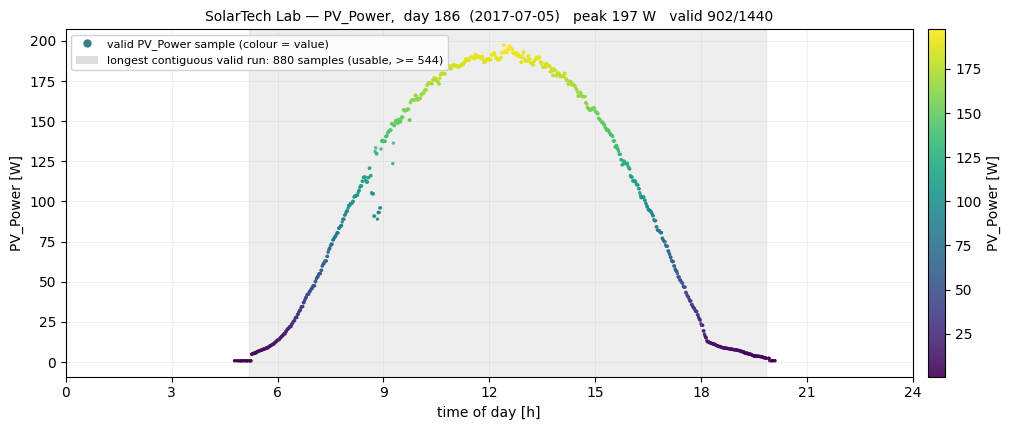

wrote _run\solar\solar_PV_Power_day158.png


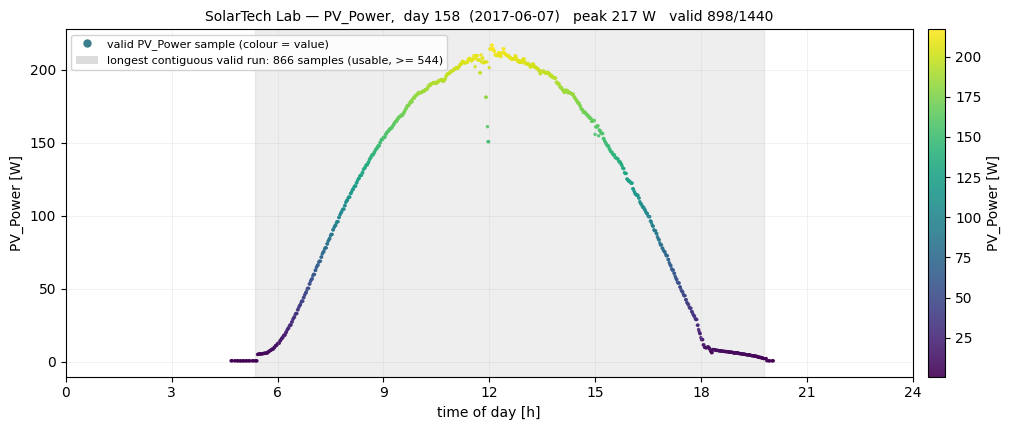

wrote _run\solar\solar_PV_Power_day212.png


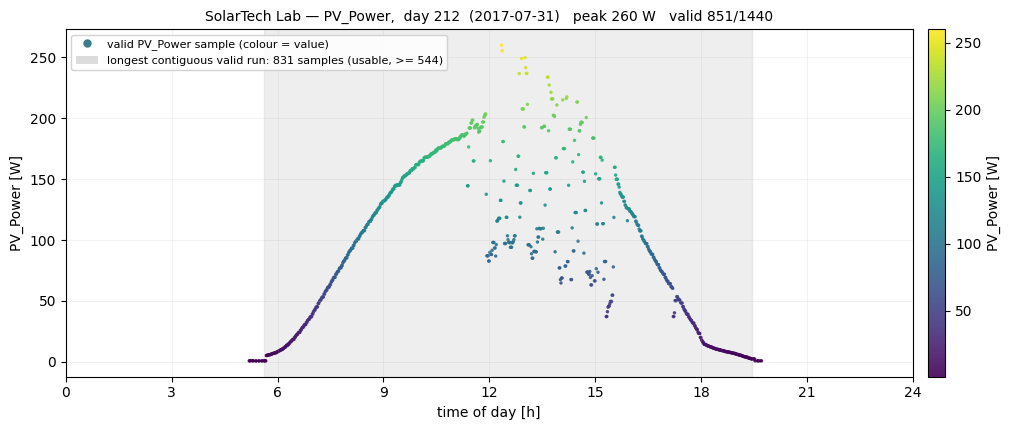

wrote _run\solar\solar_PV_Power_day015.png


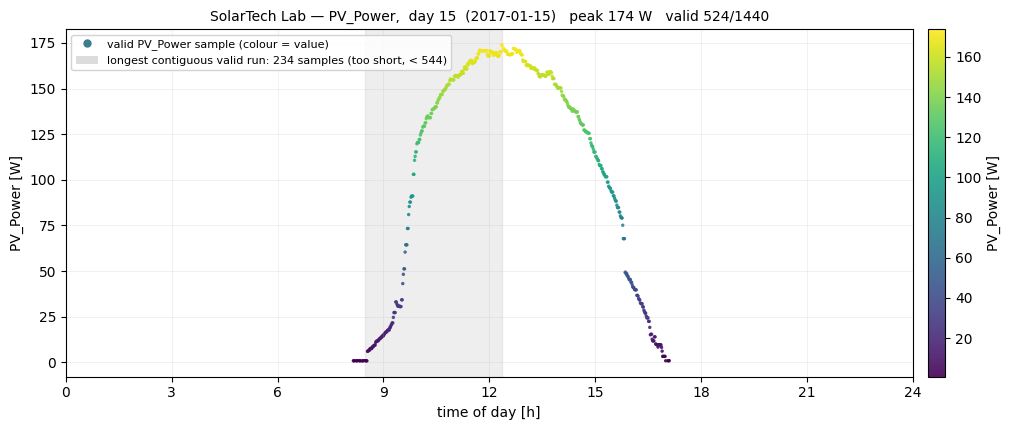

In [122]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

SPAN_KW = dict(color="0.55", alpha=0.14, zorder=0)


def run_label(run):
    """The legend text for the grey band."""
    if not run:
        return "no valid sample in this day"
    verdict = f"usable, >= {CANON_LEN}" if run >= CANON_LEN else f"too short, < {CANON_LEN}"
    return f"longest contiguous valid run: {run} samples ({verdict})"


def draw_day(ax, doy, norm=None, annotate_run=True):
    """Draw one day onto ax. Returns (scatter, run length)."""
    d = day_frame(doy)
    run, at = longest_valid_run(d[CHANNEL])
    ok = d[d[CHANNEL].notna()]

    sc = ax.scatter(ok.tod, ok[CHANNEL], c=ok[CHANNEL], cmap="viridis",
                    norm=norm, s=6, linewidths=0, alpha=0.9,
                    label=f"valid {CHANNEL} sample (colour = value)")
    if run:
        ax.axvspan(d.tod.iloc[at], d.tod.iloc[at + run - 1], **SPAN_KW)

    ttl = (f"day {doy}  ({d.Time.iloc[0].date()})   peak {d[CHANNEL].max():.0f} {UNIT}   "
           f"valid {d[CHANNEL].notna().sum()}/1440")
    if annotate_run:
        ttl += f"   longest run {run}"
    ax.set_title(ttl, fontsize=9)
    ax.set_xlabel("time of day [h]")
    ax.set_ylabel(f"{CHANNEL} [{UNIT}]")
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 3))
    ax.grid(alpha=0.25, lw=0.5)
    return sc, run


def figure_for_day(doy):
    """One standalone figure for one day, with its own legend and colour scale."""
    fig, ax = plt.subplots(figsize=(11, 4.4))
    sc, run = draw_day(ax, doy, annotate_run=False)
    fig.colorbar(sc, ax=ax, pad=0.015, label=f"{CHANNEL} [{UNIT}]")
    ax.set_title(f"SolarTech Lab — {CHANNEL},  " + ax.get_title(), fontsize=10)
    ax.legend(handles=[Line2D([], [], marker="o", ls="", ms=5, color="#3a7d8c",
                              label=f"valid {CHANNEL} sample (colour = value)"),
                       Patch(facecolor="0.55", alpha=0.30, label=run_label(run))],
              loc="upper left", fontsize=8, frameon=True, framealpha=0.85)
    fig.tight_layout()
    return fig


if SAVE_FIGURES:
    Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

for doy in DAYS:
    fig = figure_for_day(doy)
    if SAVE_FIGURES:
        p = Path(OUT_DIR) / f"solar_{CHANNEL}_day{doy:03d}.png"
        fig.savefig(p, dpi=160, bbox_inches="tight")
        print("wrote", p)
    plt.show()


### The cumulative figure

The same panels, one under another, on a **single colour scale** shared by every day so that panel
heights and colours are comparable, and with a **single legend** for the whole figure. Each panel
title carries its own longest-run length.

wrote _run\solar\solar_PV_Power_stacked_186-158-212-15.png


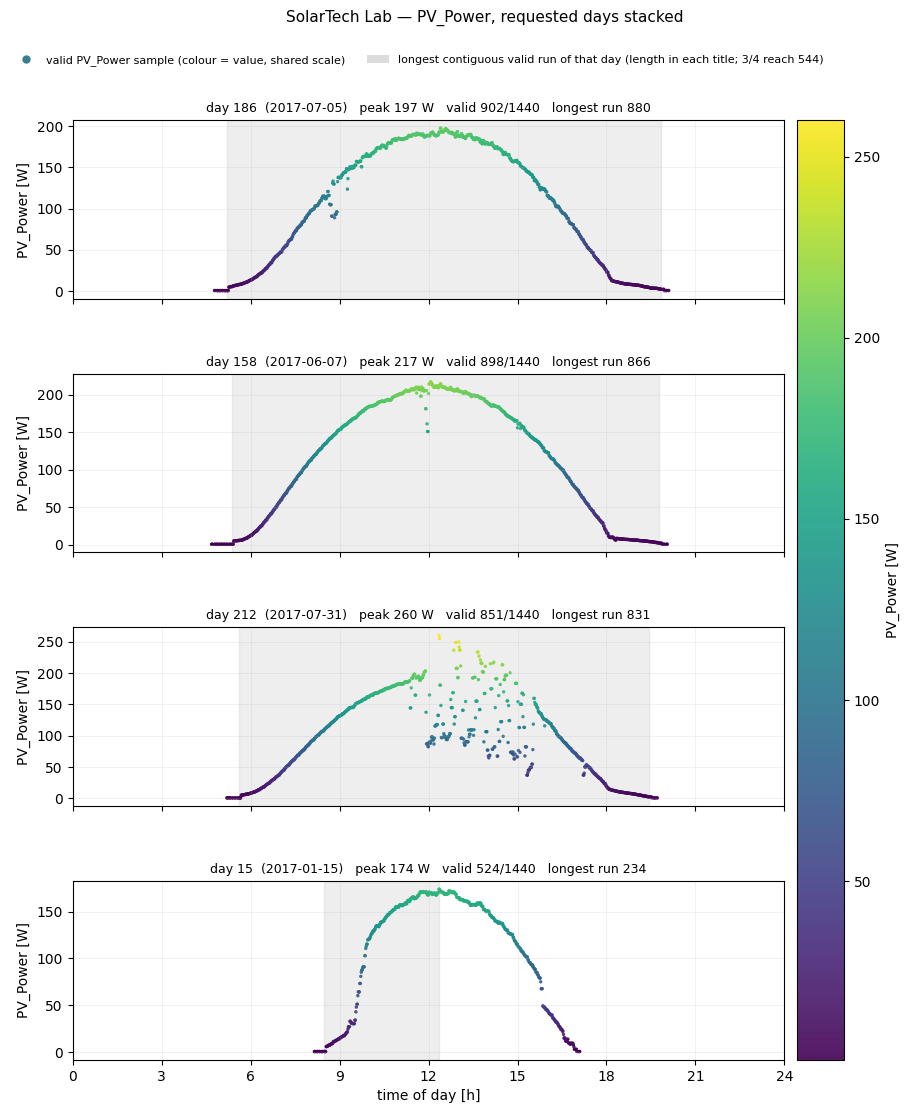

In [123]:
if STACKED and len(DAYS) >= 1:
    import matplotlib.colors as mcolors

    vals = pd.concat([day_frame(doy)[CHANNEL].dropna() for doy in DAYS])
    NORM = mcolors.Normalize(vmin=float(vals.min()), vmax=float(vals.max()))

    n = len(DAYS)
    fig, axes = plt.subplots(n, 1, figsize=(11, 2.9 * n), squeeze=False, sharex=True)
    runs = []
    for ax, doy in zip(axes[:, 0], DAYS):
        sc, run = draw_day(ax, doy, norm=NORM, annotate_run=True)
        runs.append(run)
    for ax in axes[:-1, 0]:
        ax.set_xlabel("")

    fig.subplots_adjust(hspace=0.42, top=0.90, bottom=0.09)
    fig.colorbar(sc, ax=axes[:, 0].tolist(), pad=0.015, label=f"{CHANNEL} [{UNIT}]")

    n_ok_req = sum(r >= CANON_LEN for r in runs)
    fig.legend(handles=[Line2D([], [], marker="o", ls="", ms=5, color="#3a7d8c",
                               label=f"valid {CHANNEL} sample (colour = value, shared scale)"),
                        Patch(facecolor="0.55", alpha=0.30,
                              label=f"longest contiguous valid run of that day "
                                    f"(length in each title; {n_ok_req}/{n} reach {CANON_LEN})")],
               loc="upper center", bbox_to_anchor=(0.44, 0.965),
               ncol=2, fontsize=8, frameon=False)
    fig.suptitle(f"SolarTech Lab — {CHANNEL}, requested days stacked", y=0.995, fontsize=11)

    if SAVE_FIGURES:
        p = Path(OUT_DIR) / f"solar_{CHANNEL}_stacked_{'-'.join(map(str, DAYS))}.png"
        fig.savefig(p, dpi=160, bbox_inches="tight")
        print("wrote", p)
    plt.show()


wrote _run\solar\solar_PV_Power_overlay.png


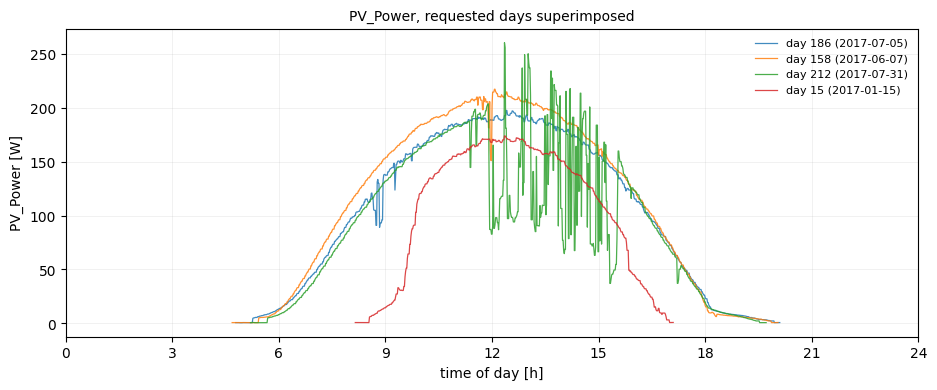

In [124]:
if OVERLAY and len(DAYS) > 1:
    fig, ax = plt.subplots(figsize=(11, 4))
    for doy in DAYS:
        d = day_frame(doy)
        ok = d[d[CHANNEL].notna()]
        ax.plot(ok.tod, ok[CHANNEL], lw=0.9, alpha=0.85,
                label=f"day {doy} ({d.Time.iloc[0].date()})")
    ax.set_xlabel("time of day [h]"); ax.set_ylabel(f"{CHANNEL} [{UNIT}]")
    ax.set_xlim(0, 24); ax.set_xticks(range(0, 25, 3))
    ax.grid(alpha=0.25, lw=0.5); ax.legend(fontsize=8, frameon=False)
    ax.set_title(f"{CHANNEL}, requested days superimposed", fontsize=10)
    if SAVE_FIGURES:
        p = Path(OUT_DIR) / f"solar_{CHANNEL}_overlay.png"
        fig.savefig(p, dpi=160, bbox_inches="tight"); print("wrote", p)
    plt.show()


## 4, One horizon ahead from a chosen time of day

Pick a day and a time. The forecast is the $\mathrm{PRED} = 64$ samples that follow it, which at this
one-minute cadence is **64 minutes**, so "the next hour" is the next $64$ points rather than $60$.

The context is, by default, the `CONTEXT_LEN = 2048` samples immediately before the cut, taken by
position and therefore **crossing midnight into the preceding days**. Day 80 at 16:00 gives $960$
minutes of day 80 and the $1088$ that precede them on day 79 — about $34$ hours ending at the cut.
Two reasons for that length rather than a single calendar day: it is Chronos-Bolt's
`context_length`, so the pipeline truncates nothing, and it is the window the sweep was trained at
(`CONTEXT_LENGTH = 2048` in `train_sweep.py`), so the model is being asked a question of the shape it
was trained on. A multi-day context also carries more than one sunrise, which is the only way the
daily cycle itself is inside the window rather than being the whole of it.

Two models are run on the same context:

* **retrained $(16,16)$** — the sweep checkpoint `p16-s16-seed42`, resolved by the project's own
  `model_loader`, trained from scratch for $100{,}000$ steps on the synthetic mixture at seed 42.
* **published $(16,16)$** — `amazon/chronos-bolt-tiny` as released. $(16,16)$ is its stock geometry,
  which is why it is the reference geometry of the sweep.

**Read the difference between the two as a difference in training corpus, not as a result about
aliasing.** The published checkpoint was pretrained on a large observational corpus that includes
energy and weather series; the retrained one has seen only the synthetic mixture. It would be
surprising if the published model did not fit measured telemetry better, and that gap says nothing
about either hypothesis. This figure exists to show what the agent of Section 11 is acting on, on
one day, with no folds and no repetition.

### Missing samples: why they become zeros

Reading a missing sample as zero production is right nearly everywhere in this file, and the
measurements say how nearly. Classifying all $326{,}871$ missing `PV_Power` samples by the sun's
elevation at that minute, and the daylight ones further by the length of the gap they belong to:

| missing samples | count | share | reading |
|---|---:|---:|---|
| sun below the horizon | $260{,}094$ | $79.6\%$ | the plant produces nothing. $0$ W is the true value. |
| daylight, gap $>15$ min | $56{,}317$ | $17.2\%$ | plant or logger down — $78$ of these runs are longer than four hours and hold $49{,}204$ samples on their own. Nothing was produced or recorded. $0$ W stands. |
| daylight, gap $\le 15$ min | $10{,}460$ | $3.2\%$ | a short dropout inside a production curve. $6{,}029$ runs, median $2$ min. |

So the rule "missing means no production" survives for $96.8\%$ of the missing samples, and the
default policy applies it there. The last row is the exception and it is worth one line of code:
$34\%$ of those short gaps are flanked by more than $50$ W and their $90$th percentile flank is
$166$ W, so zeroing them stamps a rectangular notch — down to $0$ and back within two minutes — into
the middle of a working day. The plant never did that. A notch is also broadband in frequency, which
in a report about which frequencies a patch grid can represent is the one artefact worth not
inventing. Those gaps are short enough to interpolate linearly between their own endpoints, which is
both closer to the truth and smooth.

Hence `NAN_POLICY = "zero_interp_short"`: **missing is zero, except a daylight gap of at most
`SHORT_GAP` minutes, which is interpolated.** `"zero"` implements the flat rule if you prefer it; the
difference touches $3.2\%$ of missing samples and no conclusion in the report depends on it.

The elevation test is not a heuristic. On day 15 the sun is up from $8.10$ to $16.97$ h and the valid
samples run $8.15$ to $17.10$; on day 186, $4.77$–$20.15$ against $4.78$–$20.10$. The two boundaries
agree to a few minutes all year.

### One thing that is not missing data

Twenty samples, on four days, report between $1{,}000$ and $59{,}701$ W against a $99.9$th percentile
of $246$ W. One of them reads $43{,}730$ W at 06:24 with a measured irradiance of $32$ W/m², which is
not physically possible. They are recording glitches, and they matter more than their count suggests:
Chronos-Bolt normalises each context by its own mean and standard deviation, so a single $59.7$ kW
sample anywhere in a $2048$-sample window flattens the real production curve to nothing. `SPIKE_MAX`
removes them by treating them as missing.

In [125]:
PIPE_PUB = None
RETRAINED_LOADER = None

if RUN_FORECAST:
    import torch
    from chronos import BaseChronosPipeline

    DEV = DEVICE or ("cuda" if torch.cuda.is_available() else "cpu")

    def _resolve_retrained(P, S, device):
        """(pipeline, label) for one retrained geometry, through the project's own loader."""
        try:
            import probe_lib as pl
            return pl.load_checkpoint(P, S, device=device)
        except Exception as exc:                   # probe_lib pulls in the whole probing stack
            print(f"probe_lib unavailable ({type(exc).__name__}), using model_loader directly")
            import model_loader as ml
            ck = ml.resolve_local_checkpoint(P, S)
            if ck is not None:
                return (BaseChronosPipeline.from_pretrained(str(ck), device_map=device),
                        f"p{P}-s{S} (local {ck.name})")
            return (BaseChronosPipeline.from_pretrained(
                        ml.SWEEP_REPO, subfolder=f"p{P}-s{S}-seed42",
                        revision=ml.SWEEP_REVISION, device_map=device),
                    f"p{P}-s{S} (hub {ml.SWEEP_REPO}@{ml.SWEEP_REVISION[:8]})")

    RETRAINED_LOADER = _resolve_retrained
    PIPE_PUB = BaseChronosPipeline.from_pretrained(BASE_MODEL_ID, device_map=DEV)
    c = PIPE_PUB.model.config.chronos_config
    print(f"published : {BASE_MODEL_ID}  P={c['input_patch_size']} S={c['input_patch_stride']} "
          f"pred={c['prediction_length']} ctx={c['context_length']}")
    print(f"retrained : {len(FCST_GEOMETRIES)} geometr{'y' if len(FCST_GEOMETRIES) == 1 else 'ies'} "
          f"{['p%d-s%d' % g for g in FCST_GEOMETRIES]}, loaded one at a time")
else:
    print("RUN_FORECAST is False, section 4 is skipped.")


published : amazon/chronos-bolt-tiny  P=16 S=16 pred=64 ctx=2048
retrained : 15 geometries ['p8-s8', 'p16-s8', 'p16-s12', 'p16-s16', 'p24-s8', 'p24-s12', 'p24-s16', 'p24-s20', 'p24-s24', 'p32-s8', 'p32-s12', 'p32-s16', 'p32-s20', 'p32-s24', 'p32-s32'], loaded one at a time


In [126]:
def solar_elevation(ts, lat=SITE_LAT, lon=SITE_LON, tz=SITE_TZ):
    """Solar elevation in degrees for a series of local timestamps (NOAA low-precision equations).

    Accurate to a fraction of a degree, which is far more than the zero crossing needs: a few km of
    error in the site coordinates moves sunrise by seconds.
    """
    t = pd.DatetimeIndex(ts)
    utc = t - pd.Timedelta(hours=tz)
    n = utc.dayofyear.to_numpy(float)
    hr = utc.hour.to_numpy(float) + utc.minute.to_numpy(float) / 60 + utc.second.to_numpy(float) / 3600
    g = 2 * np.pi / 365.0 * (n - 1 + (hr - 12) / 24.0)
    eqtime = 229.18 * (0.000075 + 0.001868 * np.cos(g) - 0.032077 * np.sin(g)
                       - 0.014615 * np.cos(2 * g) - 0.040849 * np.sin(2 * g))
    decl = (0.006918 - 0.399912 * np.cos(g) + 0.070257 * np.sin(g) - 0.006758 * np.cos(2 * g)
            + 0.000907 * np.sin(2 * g) - 0.002697 * np.cos(3 * g) + 0.00148 * np.sin(3 * g))
    tst = (hr * 60 + eqtime + 4 * lon) % 1440
    ha = np.deg2rad(tst / 4.0 - 180.0)
    la = np.deg2rad(lat)
    sin_el = np.sin(la) * np.sin(decl) + np.cos(la) * np.cos(decl) * np.cos(ha)
    return np.rad2deg(np.arcsin(np.clip(sin_el, -1, 1)))


RAW["elev"] = solar_elevation(RAW["Time"])

# spike guard: physically impossible readings are treated as missing, not as data
_spike = (RAW[CHANNEL] > SPIKE_MAX).to_numpy()
if _spike.any():
    print(f"{CHANNEL}: {_spike.sum()} samples above {SPIKE_MAX:g} {UNIT} "
          f"(max {RAW[CHANNEL].max():.0f}) treated as missing")
    RAW.loc[_spike, CHANNEL] = np.nan

_nan = RAW[CHANNEL].isna().to_numpy()
_night = _nan & (RAW["elev"].to_numpy() <= 0)
print(f"{CHANNEL}: {_nan.sum():,} missing samples, "
      f"{_night.sum():,} with the sun below the horizon "
      f"({100 * _night.sum() / _nan.sum():.1f}%)")


def _gap_runs(miss):
    """Yield (start, length) for every maximal run of True in `miss`."""
    i = 0
    while i < len(miss):
        if miss[i]:
            j = i
            while j < len(miss) and miss[j]:
                j += 1
            yield i, j - i
            i = j
        else:
            i += 1


def apply_nan_policy(df, values, policy=NAN_POLICY, short_gap=SHORT_GAP):
    """Apply the missing-data policy.

    Returns (values, filled, interpolated): the series the model receives, the samples set to zero,
    and the samples filled by interpolation.
    """
    v = np.asarray(values, float).copy()
    miss = ~np.isfinite(v)
    night = df["elev"].to_numpy() <= 0
    interp = np.zeros_like(miss)

    if policy == "mask":
        fill = np.zeros_like(miss)
    elif policy == "zero_night":
        fill = miss & night
    elif policy == "zero":
        fill = miss.copy()
    elif policy == "zero_interp_short":
        fill = miss.copy()
        for i0, n in _gap_runs(miss):
            if n <= short_gap and not night[i0:i0 + n].any() and i0 > 0 and i0 + n < len(v):
                a, b = v[i0 - 1], v[i0 + n]
                if np.isfinite(a) and np.isfinite(b):      # interpolate between real endpoints
                    v[i0:i0 + n] = np.linspace(a, b, n + 2)[1:-1]
                    fill[i0:i0 + n] = False
                    interp[i0:i0 + n] = True
    else:
        raise ValueError(f"unknown NAN_POLICY {policy!r}")

    v[fill] = 0.0
    return v, fill, interp


PV_Power: 20 samples above 1000 W (max 59701) treated as missing
PV_Power: 326,891 missing samples, 260,094 with the sun below the horizon (79.6%)


In [127]:
def forecast_window(doy, hhmm, mode=CONTEXT_MODE, horizon=PRED, ctx_len=CONTEXT_LEN):
    """Context ending at `hhmm` on `doy`, and the true continuation.

    Both are taken from the file **by position**, so the context crosses midnight backwards into the
    preceding days and a cut near midnight still returns a full horizon.
    """
    d = day_frame(doy)
    h, m = (int(x) for x in hhmm.split(":"))
    cut = d.Time.iloc[0].normalize() + pd.Timedelta(hours=h, minutes=m)

    pos = RAW.index[RAW.Time < cut]
    if len(pos) == 0:
        raise ValueError(f"{cut} precedes the file")
    i_cut = int(pos[-1]) + 1                       # first row at or after the cut

    if mode == "window":
        i0 = max(0, i_cut - int(ctx_len))
        ctx_df = RAW.iloc[i0:i_cut]
        if len(ctx_df) < ctx_len:
            print(f"note: only {len(ctx_df)} samples precede the cut, asked for {ctx_len}")
    elif mode in ("day", "valid"):
        ctx_df = RAW.iloc[:i_cut]
        ctx_df = ctx_df[ctx_df.doy == doy]         # "the day up to that hour"
    else:
        raise ValueError(f"unknown CONTEXT_MODE {mode!r}")
    ctx = ctx_df[CHANNEL].to_numpy(float)

    if mode == "valid":                            # keep only the unbroken observed tail
        good = np.isfinite(ctx)
        k = 0
        while k < len(good) and good[len(good) - 1 - k]:
            k += 1
        ctx_df, ctx = ctx_df.iloc[len(ctx) - k:], ctx[len(ctx) - k:]

    ctx_raw = ctx.copy()
    ctx, filled, interp = apply_nan_policy(ctx_df, ctx)   # the series the model actually receives

    fut_df = RAW.iloc[i_cut:i_cut + horizon]
    if len(fut_df) < horizon:
        raise ValueError(f"only {len(fut_df)} rows after the cut, need {horizon}")

    n_obs = int(np.isfinite(ctx_raw).sum())        # genuinely measured, before any filling
    if n_obs < 60:
        raise ValueError(f"context has {n_obs} measured samples, the trainer's floor is 60")

    # the same policy on the horizon, so context and truth make the same claim about missing data
    fut, fut_filled, fut_interp = apply_nan_policy(fut_df, fut_df[CHANNEL].to_numpy(float))

    days = sorted(set(int(x) for x in ctx_df.doy))
    return {"doy": doy, "cut": cut, "ctx_df": ctx_df, "ctx": ctx, "ctx_raw": ctx_raw,
            "filled": filled, "interp": interp, "policy": NAN_POLICY,
            "fut_df": fut_df, "fut": fut, "fut_filled": fut_filled, "fut_interp": fut_interp,
            "n_obs": n_obs, "horizon": horizon, "mode": mode,
            "days": days, "span_h": len(ctx) / 60.0}


def forecast_with(pipe, ctx, horizon):
    """{q10, q50, q90} for one pipeline on one context."""
    qs = list(pipe.model.config.chronos_config["quantiles"])
    x = torch.tensor(ctx[None, :], dtype=torch.float32)
    with torch.no_grad():
        y = pipe.predict(x, prediction_length=horizon)[0].float().cpu().numpy()
    pick = lambda q: y[int(np.argmin(np.abs(np.array(qs) - q)))]
    return {"q50": pick(0.5), "q10": pick(0.1), "q90": pick(0.9)}


PUB = "published (16,16)"


def geom_name(P, S):
    return f"retrained p{P}-s{S}"


if RUN_FORECAST:
    WIN = forecast_window(FCST_DAY, FCST_TIME)

    dd = WIN["days"]
    print(f"cut       {WIN['cut']}  (day {WIN['doy']})")
    print(f"context   {len(WIN['ctx'])} samples = {WIN['span_h']:.1f} h, mode {WIN['mode']!r}, "
          f"spanning day{'s' if len(dd) > 1 else ''} "
          f"{f'{dd[0]}-{dd[-1]}' if len(dd) > 1 else dd[0]}, from {WIN['ctx_df'].Time.iloc[0]}")
    print(f"          {WIN['n_obs']} measured "
          f"({100 * WIN['n_obs'] / len(WIN['ctx']):.0f}%), "
          f"{int(WIN['filled'].sum())} set to 0, {int(WIN['interp'].sum())} interpolated "
          f"[policy {WIN['policy']!r}]")
    print(f"horizon   {WIN['horizon']} samples = {WIN['horizon']} min, "
          f"{int(WIN['fut_filled'].sum())} of them filled\n")

    FC = {PUB: forecast_with(PIPE_PUB, WIN["ctx"], WIN["horizon"])}
    GEOM = {}                                   # model name -> (P, S), retrained only
    for P_, S_ in FCST_GEOMETRIES:              # one checkpoint held at a time
        pipe, label = RETRAINED_LOADER(P_, S_, DEV)
        cfg = pipe.model.config.chronos_config
        if (int(cfg["input_patch_size"]), int(cfg["input_patch_stride"])) != (P_, S_):
            raise ValueError(f"checkpoint for p{P_}-s{S_} reports a different geometry")
        name = geom_name(P_, S_)
        FC[name] = forecast_with(pipe, WIN["ctx"], WIN["horizon"])
        GEOM[name] = (P_, S_)
        print(f"  {name:22s} {label}")
        del pipe
        if DEV == "cuda":
            torch.cuda.empty_cache()

    RETRAINED = list(GEOM)
    ok = np.isfinite(WIN["fut"])
    rows = []
    for name, f in FC.items():
        e = f["q50"][ok] - WIN["fut"][ok]
        inside = ((WIN["fut"] >= f["q10"]) & (WIN["fut"] <= f["q90"]))[ok]
        rows.append({"model": name,
                     "MAE [W]": round(float(np.abs(e).mean()), 2),
                     "RMSE [W]": round(float(np.sqrt((e ** 2).mean())), 2),
                     "bias [W]": round(float(e.mean()), 2),
                     "in 80%": f"{int(inside.sum())}/{int(ok.sum())}"})
    print("\n" + pd.DataFrame(rows).to_string(index=False))
    print("\nOne day, one cut, no repetition: these numbers describe these figures, nothing more.")


cut       2017-07-05 13:00:00  (day 186)
context   2048 samples = 34.1 h, mode 'window', spanning days 185-186, from 2017-07-04 02:52:00
          1377 measured (67%), 634 set to 0, 37 interpolated [policy 'zero_interp_short']
horizon   64 samples = 64 min, 0 of them filled

  retrained p8-s8        p8-s8 (HF p8-s8-seed42)
  retrained p16-s8       p16-s8 (HF p16-s8-seed42)
  retrained p16-s12      p16-s12 (HF p16-s12-seed42)
  retrained p16-s16      p16-s16 (HF p16-s16-seed42)
  retrained p24-s8       p24-s8 (HF p24-s8-seed42)
  retrained p24-s12      p24-s12 (HF p24-s12-seed42)
  retrained p24-s16      p24-s16 (HF p24-s16-seed42)
  retrained p24-s20      p24-s20 (HF p24-s20-seed42)
  retrained p24-s24      p24-s24 (HF p24-s24-seed42)
  retrained p32-s8       p32-s8 (HF p32-s8-seed42)
  retrained p32-s12      p32-s12 (HF p32-s12-seed42)
  retrained p32-s16      p32-s16 (HF p32-s16-seed42)
  retrained p32-s20      p32-s20 (HF p32-s20-seed42)
  retrained p32-s24      p32-s24 (HF p32-s24-

### One retrained model per figure, each against the published checkpoint

Every retrained geometry gets its own figures, always paired with the published checkpoint so that
the reference is the same in all of them. With one geometry configured this is the pair of models
discussed in the report; with the whole sweep configured it is fifteen such pairs.

In [128]:
from matplotlib import colormaps

C_RETRAINED = "#C2482B"
C_PUBLISHED = "#2B6CB0"
C_TRUE = "#111111"
C_FILL = "#9AA5B1"
TAIL = 90                                    # minutes of context redrawn on the right panel


def colour_of(name):
    return C_PUBLISHED if name == PUB else C_RETRAINED


def horizon_ylim(names, pad=0.06):
    """One vertical range over the models named, so panels can be compared by eye."""
    lo = [np.nanmin(WIN["fut"]), np.nanmin(WIN["ctx"][-TAIL:])]
    hi = [np.nanmax(WIN["fut"]), np.nanmax(WIN["ctx"][-TAIL:])]
    for n in names:
        f = FC[n]
        lo += [np.nanmin(f["q10"]), np.nanmin(f["q50"])]
        hi += [np.nanmax(f["q90"]), np.nanmax(f["q50"])]
    lo, hi = float(np.nanmin(lo)), float(np.nanmax(hi))
    m = (hi - lo) * pad or 1.0
    return lo - m, hi + m


YLIM = horizon_ylim(list(FC)) if RUN_FORECAST else None
STEM = f"solar_forecast_day{WIN['doy']:03d}_{FCST_TIME.replace(':','')}" if RUN_FORECAST else ""


def tag_of(name):
    return name.replace("retrained ", "").replace("published (16,16)", "published")


In [129]:
import matplotlib.dates as mdates


def draw_context(ax, win, colorbar_fig=None):
    """The context on a real time axis, so a window spanning several days reads correctly."""
    t = win["ctx_df"]["Time"]
    measured = np.isfinite(win["ctx_raw"])

    sc = ax.scatter(t[measured], win["ctx"][measured], c=win["ctx"][measured], cmap="viridis",
                    s=6, linewidths=0, alpha=0.9)
    if win["filled"].any():
        ax.scatter(t[win["filled"]], win["ctx"][win["filled"]],
                   s=4, linewidths=0, color=C_FILL, alpha=0.85)
    if win["interp"].any():
        ax.scatter(t[win["interp"]], win["ctx"][win["interp"]],
                   s=14, facecolors="none", edgecolors="#B8860B", linewidths=0.8)

    for m in pd.date_range(t.iloc[0].ceil("D"), t.iloc[-1], freq="D"):
        ax.axvline(m, color="0.75", ls=":", lw=0.9, zorder=0)
    ax.axvline(win["cut"], color="0.25", ls="--", lw=1.1)

    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=9))
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.set_xlabel("local time (CET)")
    ax.set_ylabel(f"{CHANNEL} [{UNIT}]")
    ax.grid(alpha=0.25, lw=0.5)

    dd = win["days"]
    ax.set_title(f"context: {len(win['ctx'])} samples ({win['span_h']:.1f} h) ending {FCST_TIME}, "
                 f"day{'s' if len(dd) > 1 else ''} "
                 f"{f'{dd[0]}-{dd[-1]}' if len(dd) > 1 else dd[0]}   "
                 f"{win['n_obs']} measured", fontsize=9)
    if colorbar_fig is not None:
        colorbar_fig.colorbar(sc, ax=ax, pad=0.015, label=f"{CHANNEL} [{UNIT}]")
    return sc


def context_handles(win):
    h = [Line2D([], [], marker="o", ls="", ms=5, color="#3a7d8c",
                label=f"measured {CHANNEL} (colour = value)")]
    if win["filled"].any():
        h.append(Line2D([], [], marker="o", ls="", ms=4, color=C_FILL,
                        label=f"missing, set to 0 {UNIT} ({int(win['filled'].sum())})"))
    if win["interp"].any():
        h.append(Line2D([], [], marker="o", ls="", ms=5, mfc="none", mec="#B8860B",
                        label=f"short daylight gap, interpolated ({int(win['interp'].sum())})"))
    h.append(Line2D([], [], color="0.75", ls=":", lw=0.9, label="midnight"))
    h.append(Line2D([], [], color="0.25", lw=1.1, ls="--", label=f"cut at {FCST_TIME}"))
    return h


def draw_horizon(ax, win, which, band=True):
    t = np.arange(1, win["horizon"] + 1)
    tail_t = np.arange(-min(TAIL, len(win["ctx"])) + 1, 1)
    ax.plot(tail_t, win["ctx"][-len(tail_t):], color="0.62", lw=1.0)

    for name in which:
        f = FC[name]
        if band:
            ax.fill_between(t, f["q10"], f["q90"], color=colour_of(name), alpha=0.16, lw=0)
        ax.plot(t, f["q50"], color=colour_of(name), lw=1.2, marker="o", ms=2.6, alpha=0.95)

    ax.plot(t, win["fut"], color=C_TRUE, lw=1.0, ls="--", marker="o", ms=2.6,
            mfc="none", alpha=0.95)
    ax.axvline(0, color="0.25", ls="--", lw=1.1)
    ax.set_xlabel("minutes after the cut")
    ax.set_ylabel(f"{CHANNEL} [{UNIT}]")
    ax.grid(alpha=0.25, lw=0.5)
    if YLIM is not None:
        ax.set_ylim(*YLIM)


def horizon_handles(which, band=True):
    h = [Line2D([], [], color="0.62", lw=1.0, label=f"context, last {TAIL} min")]
    for name in which:
        h.append(Line2D([], [], color=colour_of(name), lw=1.2, marker="o", ms=3.5,
                        label=f"{name} forecast, median of {PRED} points"))
        if band:
            h.append(Patch(facecolor=colour_of(name), alpha=0.16,
                           label=f"{name} 80% interval ($q_{{0.1}}$-$q_{{0.9}}$)"))
    h.append(Line2D([], [], color=C_TRUE, lw=1.0, ls="--", marker="o", ms=3.5, mfc="none",
                    label="measured values over the same minutes"))
    h.append(Line2D([], [], color="0.25", lw=1.1, ls="--", label=f"cut at {FCST_TIME}"))
    return h


def figure_legend(fig, *handle_lists, ncol=3):
    handles, seen = [], set()
    for hl in handle_lists:
        for h in hl:
            if h.get_label() not in seen:
                seen.add(h.get_label())
                handles.append(h)
    fig.legend(handles=handles, loc="lower center", ncol=ncol, fontsize=8,
               frameon=False, bbox_to_anchor=(0.5, 0.005))


wrote _run\solar\solar_forecast_day186_1300_published.png


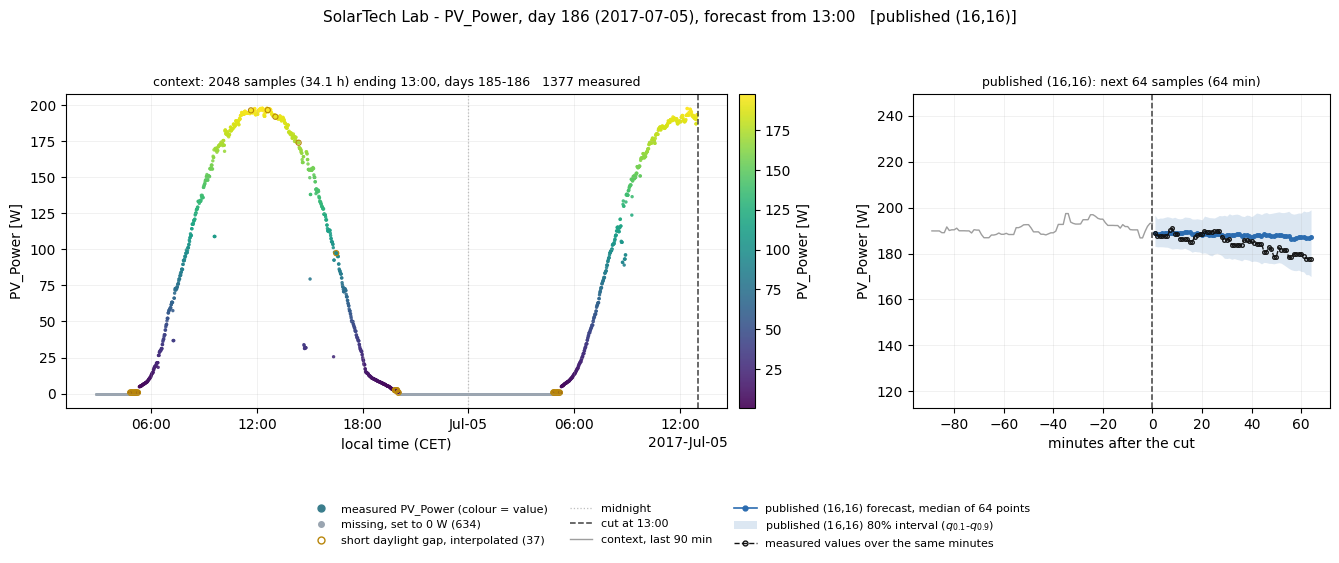

wrote _run\solar\solar_forecast_day186_1300_p8-s8.png


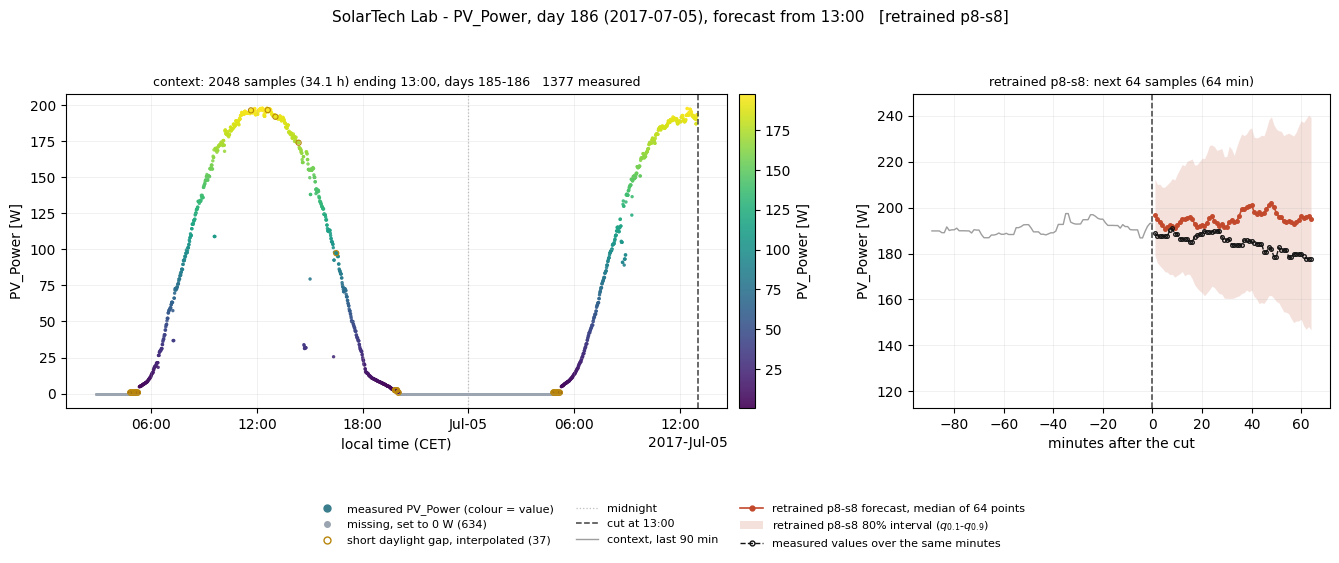

wrote _run\solar\solar_forecast_day186_1300_p16-s8.png


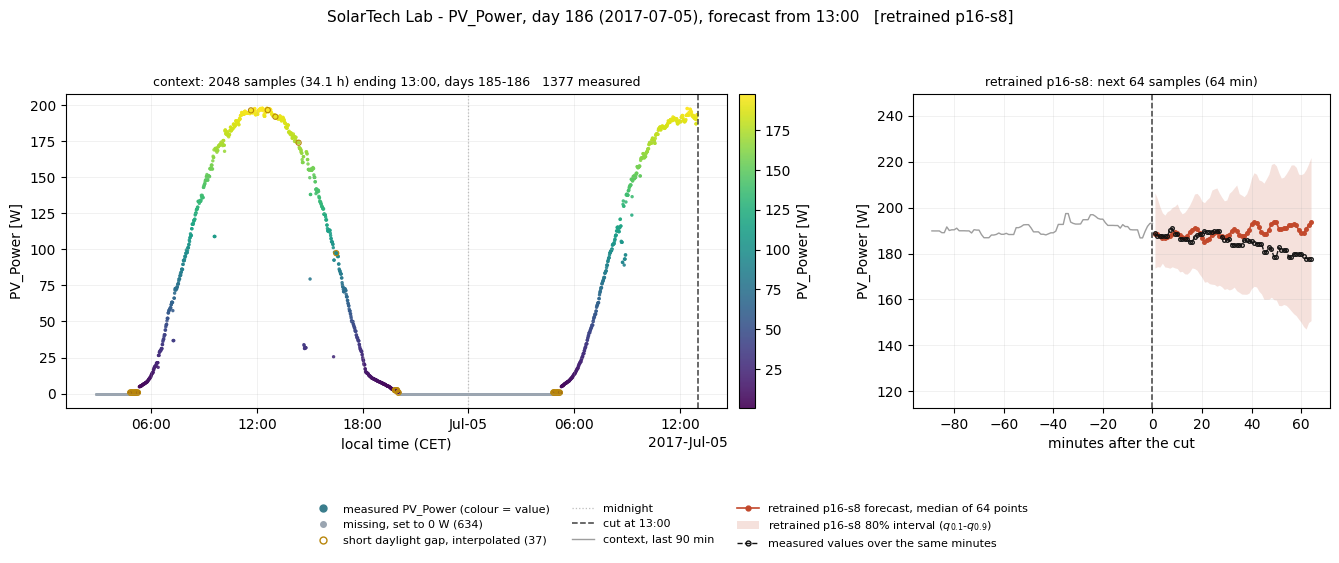

wrote _run\solar\solar_forecast_day186_1300_p16-s12.png


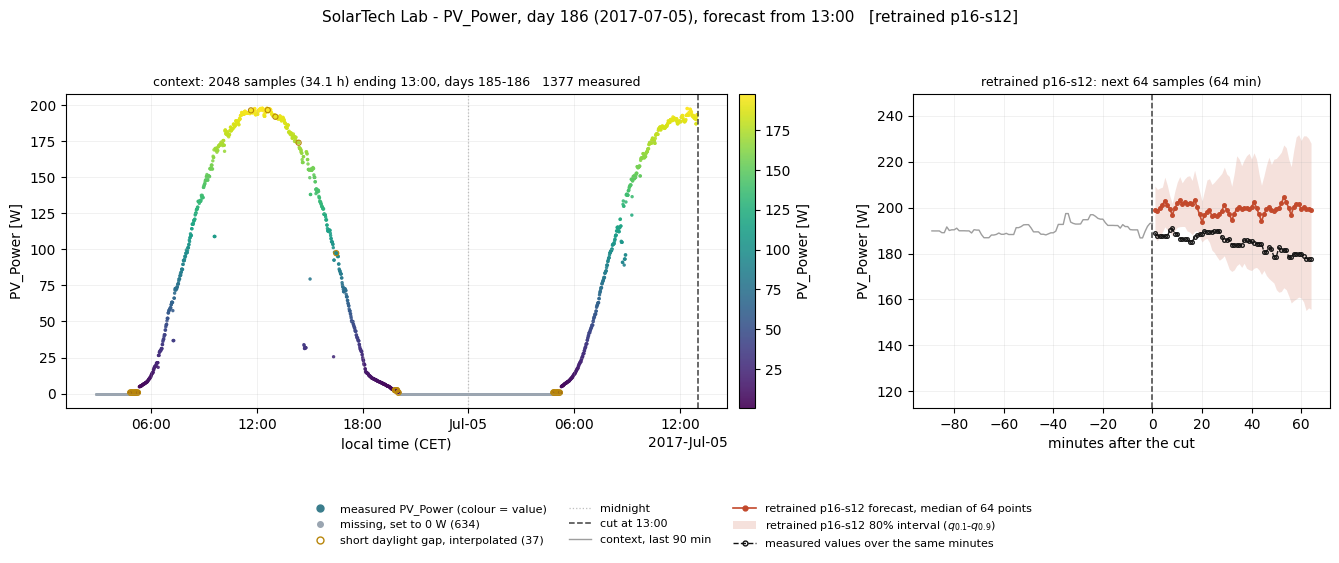

wrote _run\solar\solar_forecast_day186_1300_p16-s16.png


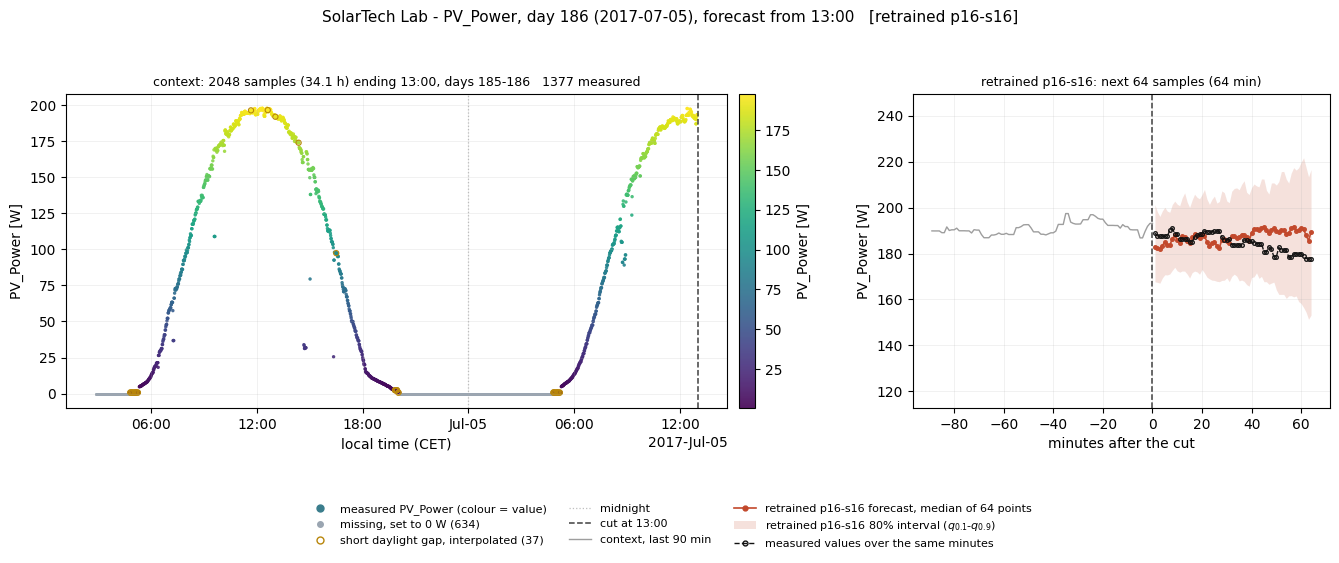

wrote _run\solar\solar_forecast_day186_1300_p24-s8.png


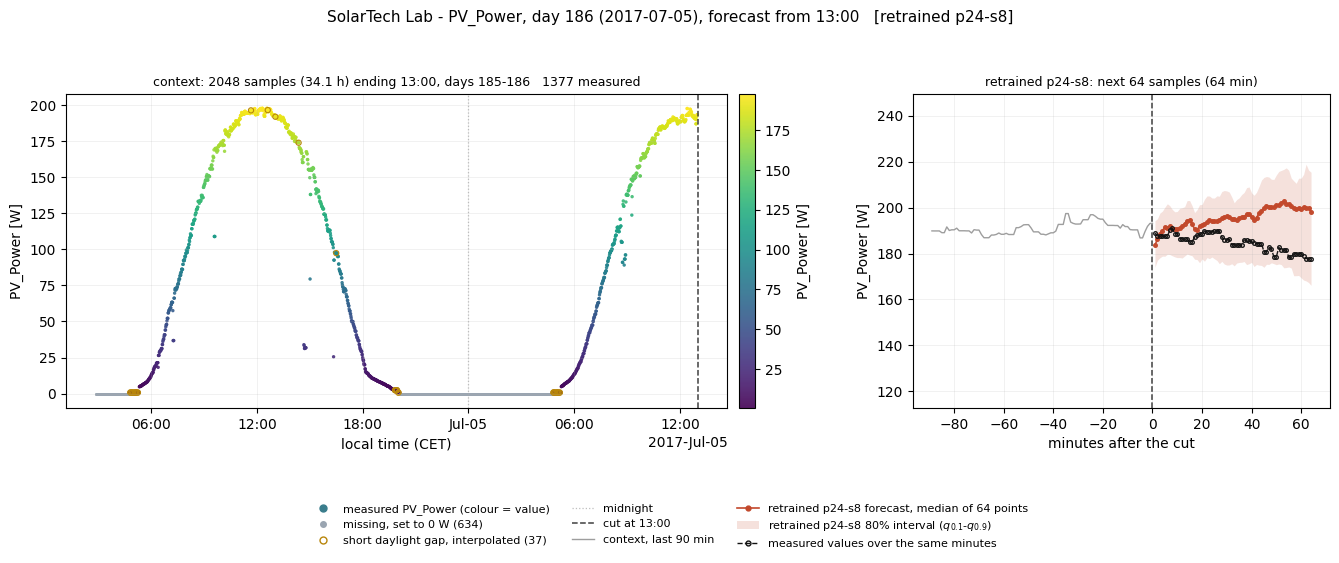

wrote _run\solar\solar_forecast_day186_1300_p24-s12.png


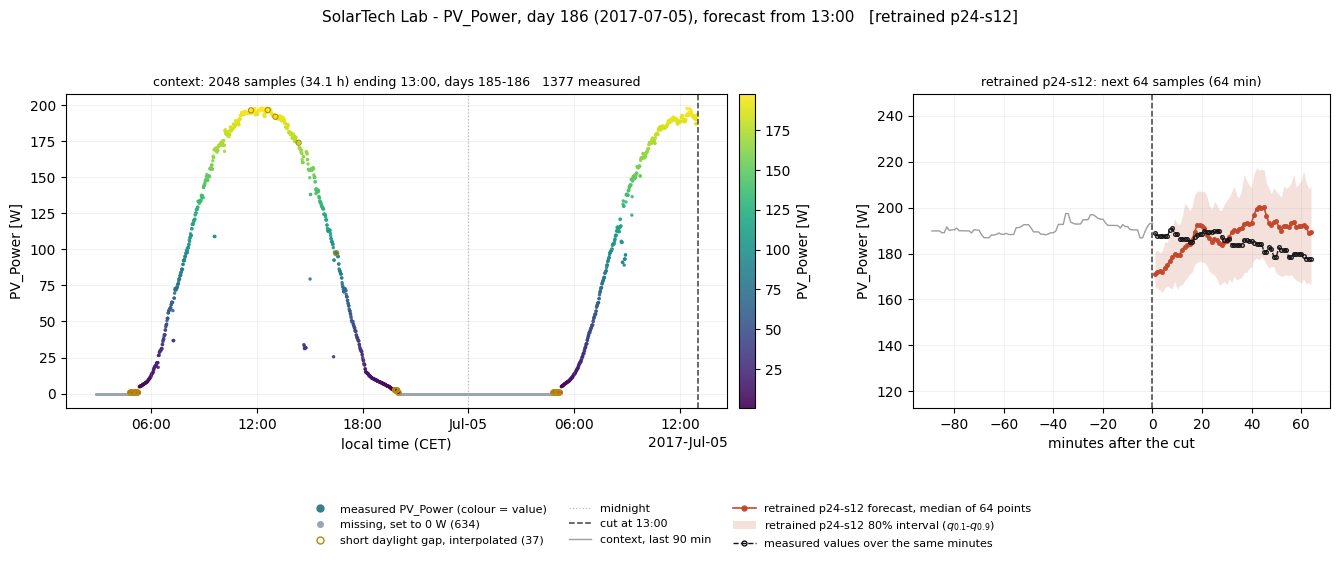

wrote _run\solar\solar_forecast_day186_1300_p24-s16.png


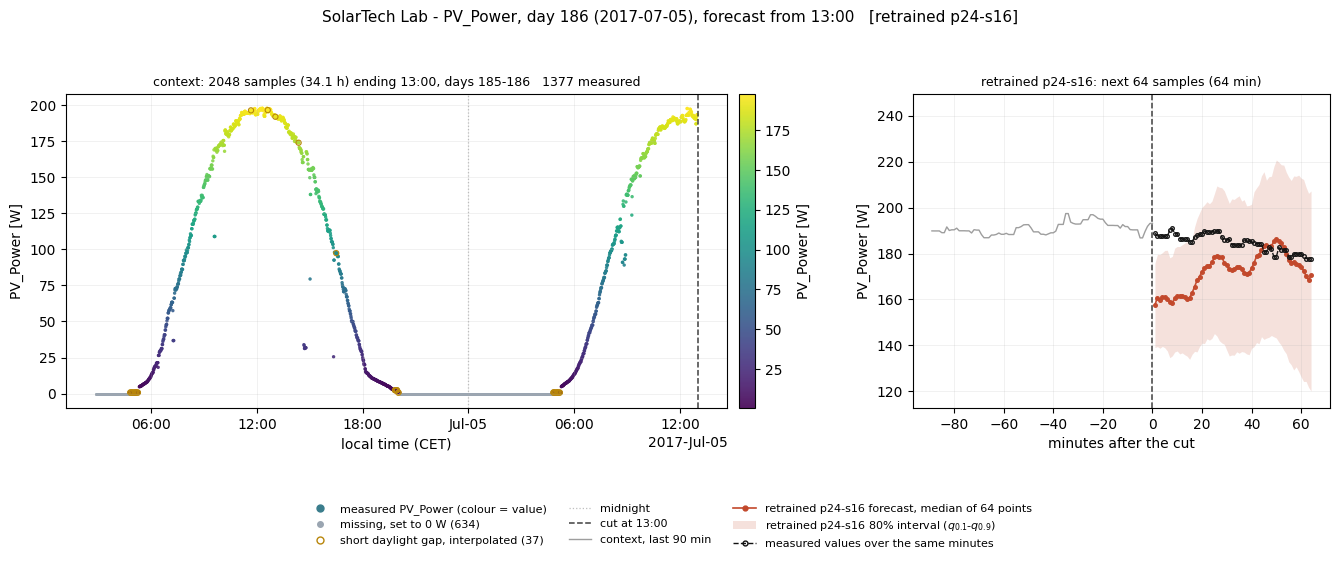

wrote _run\solar\solar_forecast_day186_1300_p24-s20.png


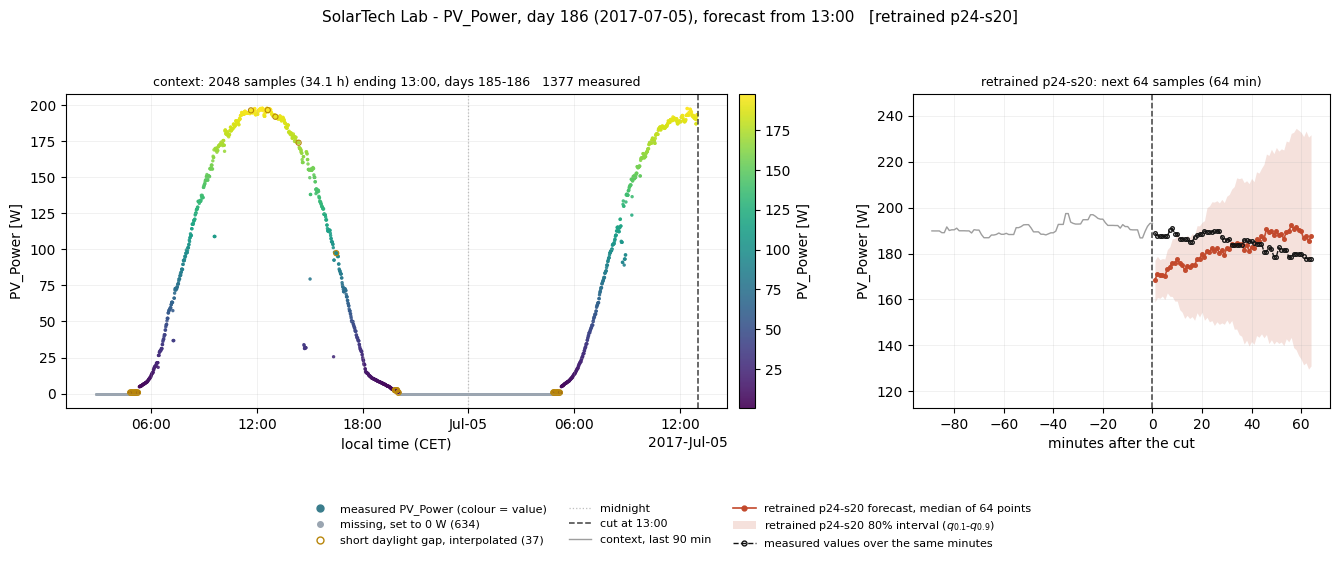

wrote _run\solar\solar_forecast_day186_1300_p24-s24.png


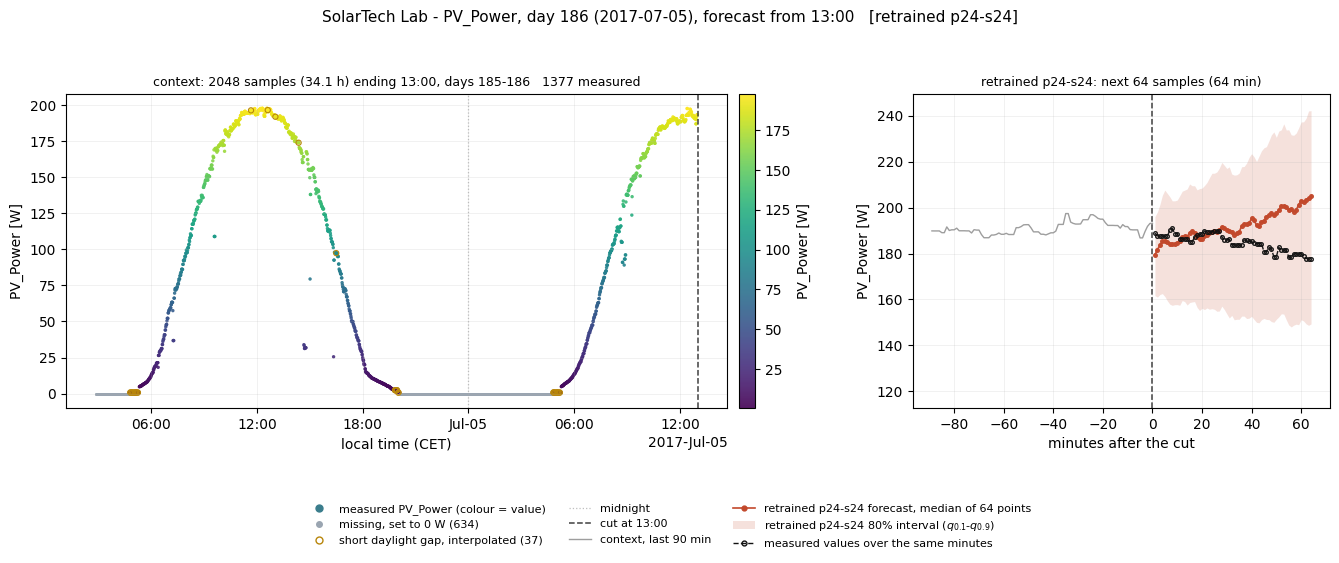

wrote _run\solar\solar_forecast_day186_1300_p32-s8.png


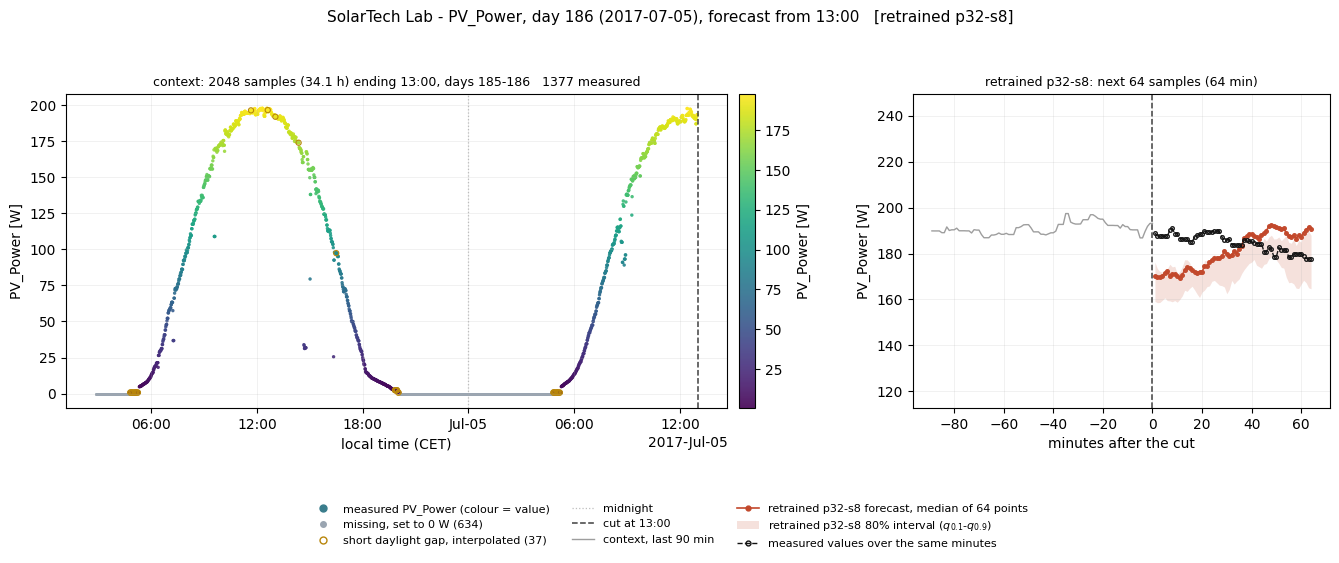

wrote _run\solar\solar_forecast_day186_1300_p32-s12.png


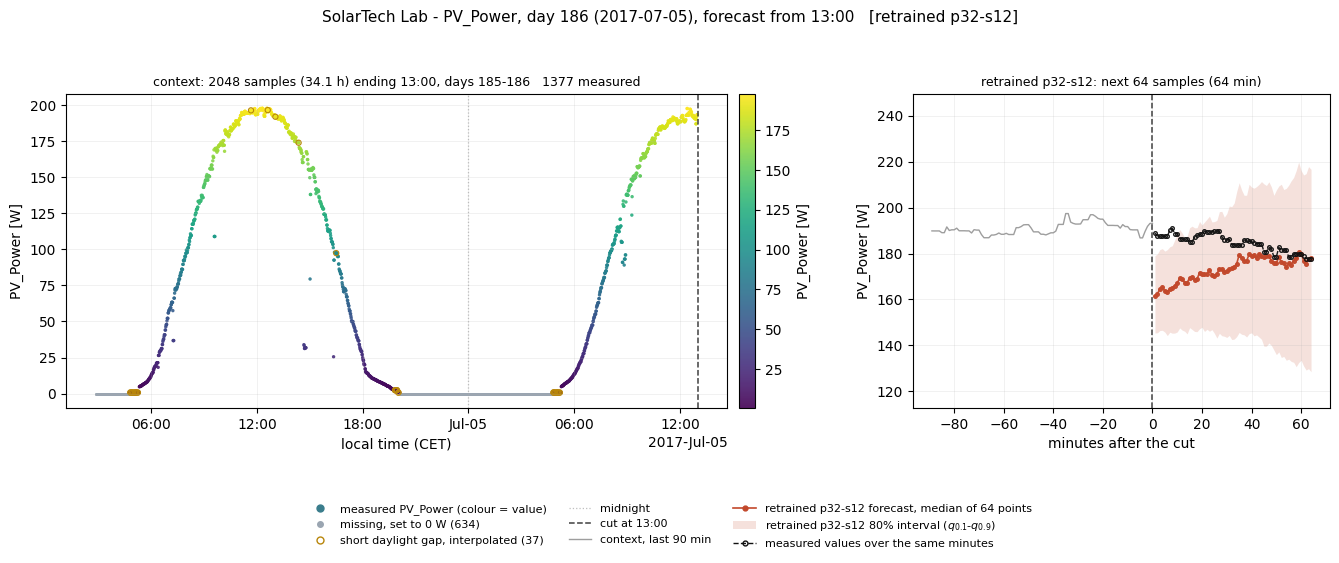

wrote _run\solar\solar_forecast_day186_1300_p32-s16.png


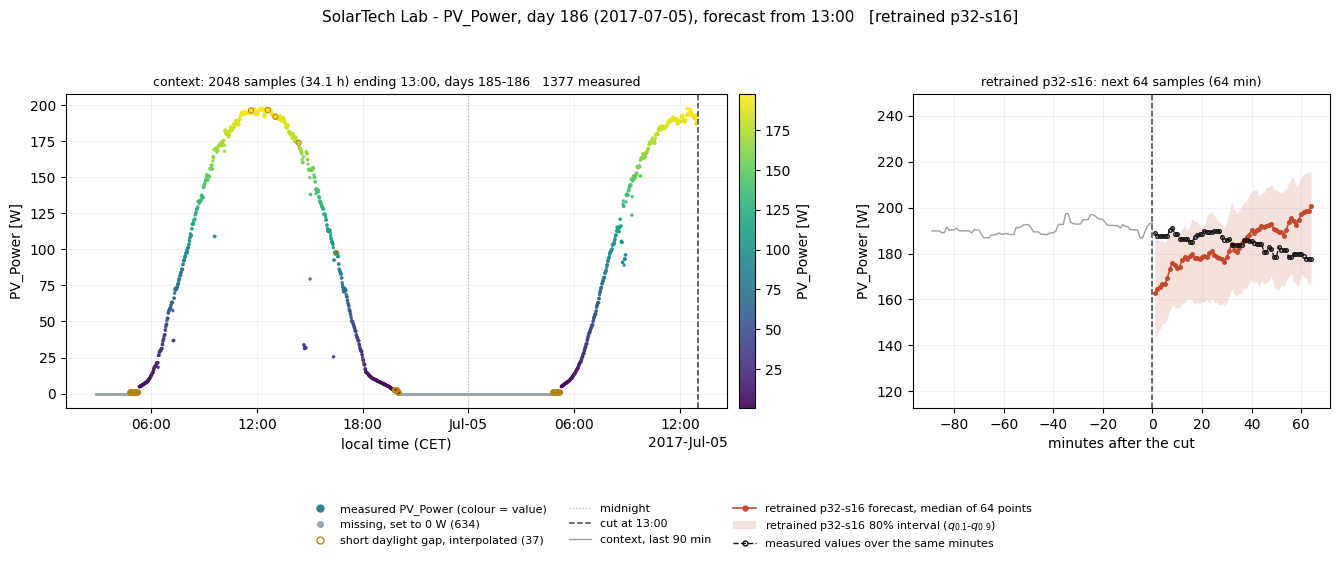

wrote _run\solar\solar_forecast_day186_1300_p32-s20.png


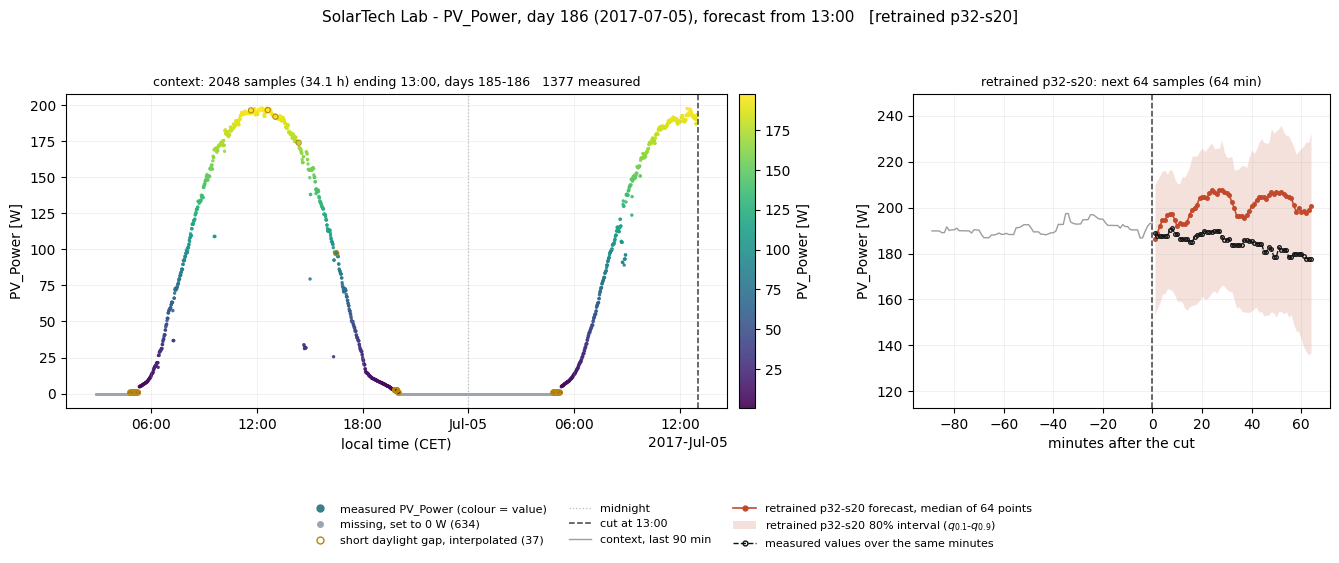

wrote _run\solar\solar_forecast_day186_1300_p32-s24.png


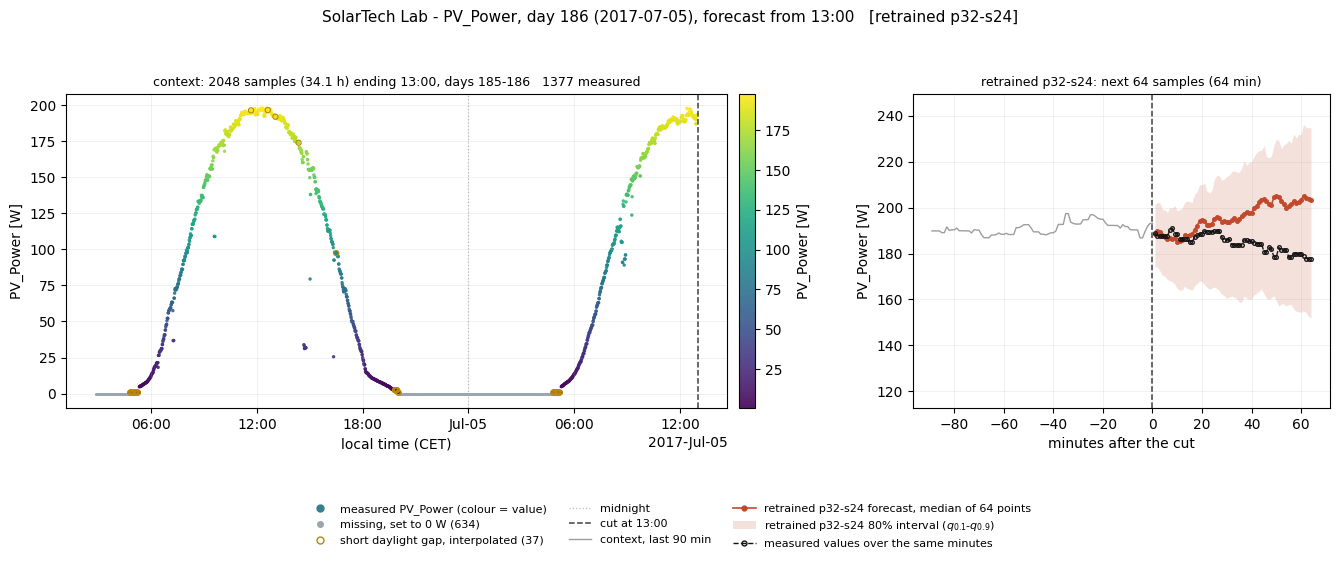

wrote _run\solar\solar_forecast_day186_1300_p32-s32.png


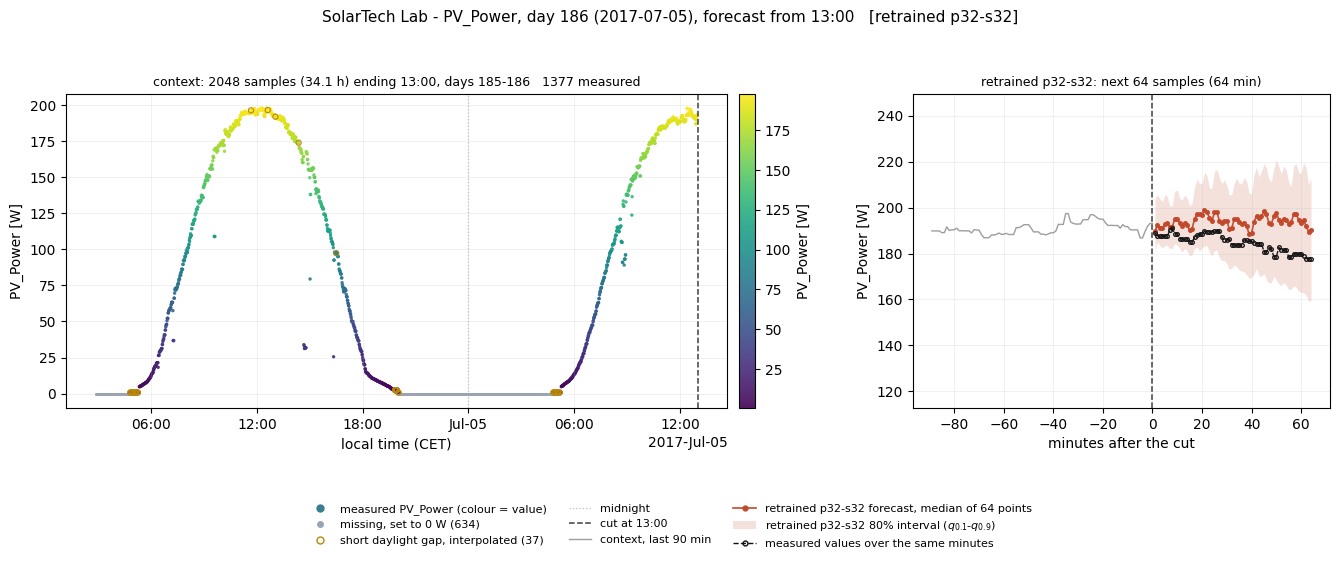

In [130]:
if RUN_FORECAST:
    for name in [PUB] + RETRAINED:
        fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5.6),
                                       gridspec_kw={"width_ratios": [1.9, 1.0]})
        draw_context(axL, WIN, colorbar_fig=fig)
        draw_horizon(axR, WIN, [name])
        axR.set_title(f"{name}: next {PRED} samples ({PRED} min)", fontsize=9)
        fig.suptitle(f"SolarTech Lab - {CHANNEL}, day {WIN['doy']} ({WIN['cut'].date()}), "
                     f"forecast from {FCST_TIME}   [{name}]", y=0.985, fontsize=11)
        fig.tight_layout(rect=(0, 0.17, 1, 0.95))
        figure_legend(fig, context_handles(WIN), horizon_handles([name]))
        if SAVE_FIGURES:
            p = Path(OUT_DIR) / f"{STEM}_{tag_of(name)}.png"
            fig.savefig(p, dpi=160, bbox_inches="tight")
            print("wrote", p)
        plt.show()


### Each retrained geometry against the published checkpoint

Three views per pair, all on the shared vertical range: context and horizon together, the horizon
alone, and the horizon as distance from the measurement.

wrote _run\solar\solar_forecast_day186_1300_p8-s8_both.png


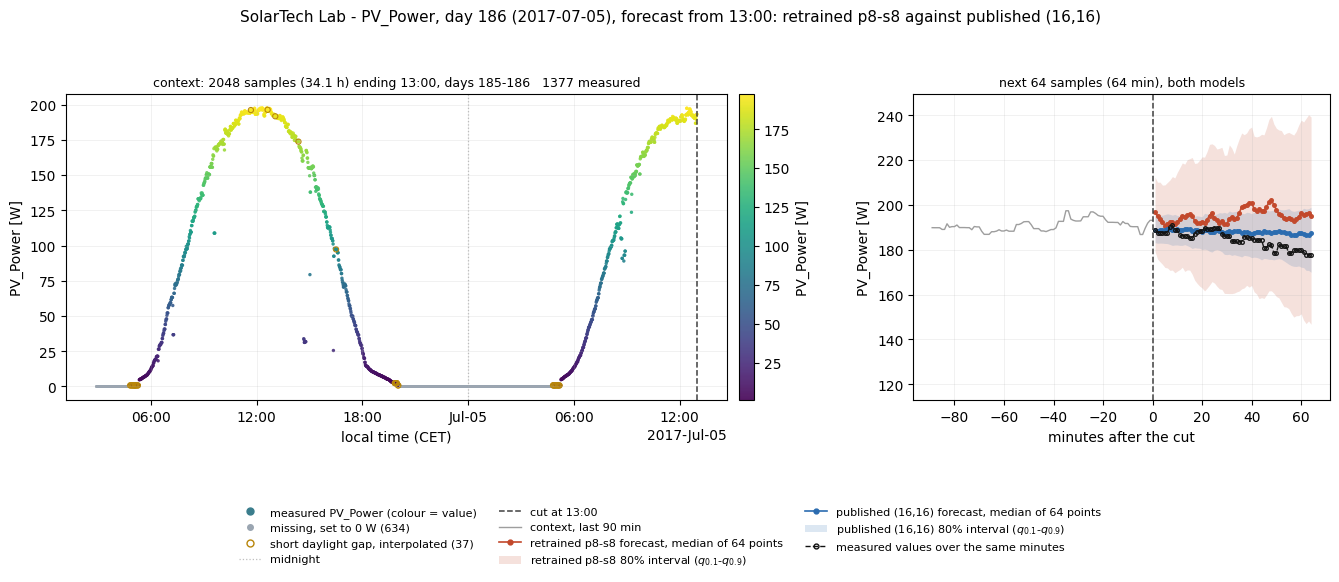

wrote _run\solar\solar_forecast_day186_1300_p8-s8_horizon.png


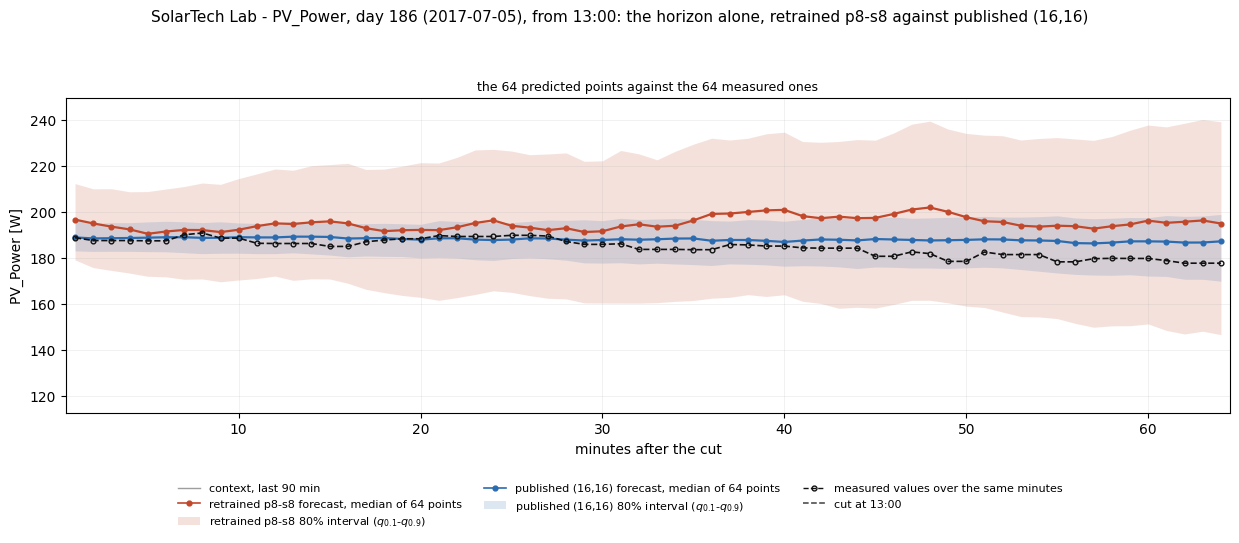

wrote _run\solar\solar_forecast_day186_1300_p8-s8_error.png


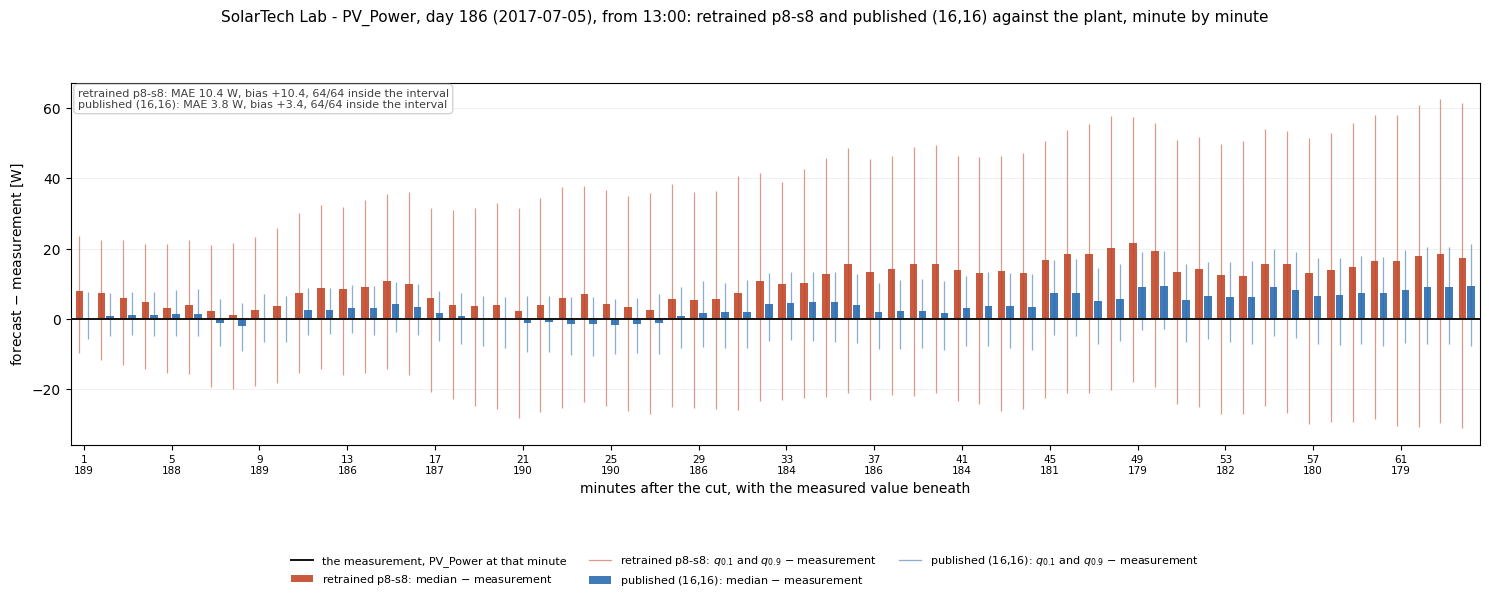

wrote _run\solar\solar_forecast_day186_1300_p16-s8_both.png


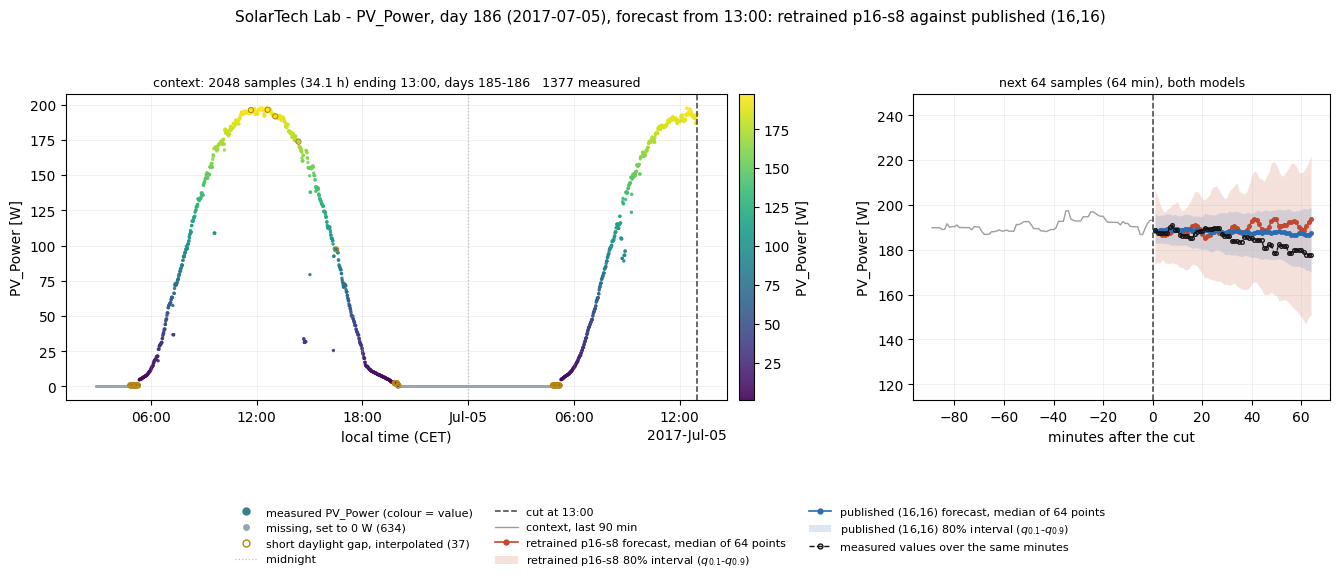

wrote _run\solar\solar_forecast_day186_1300_p16-s8_horizon.png


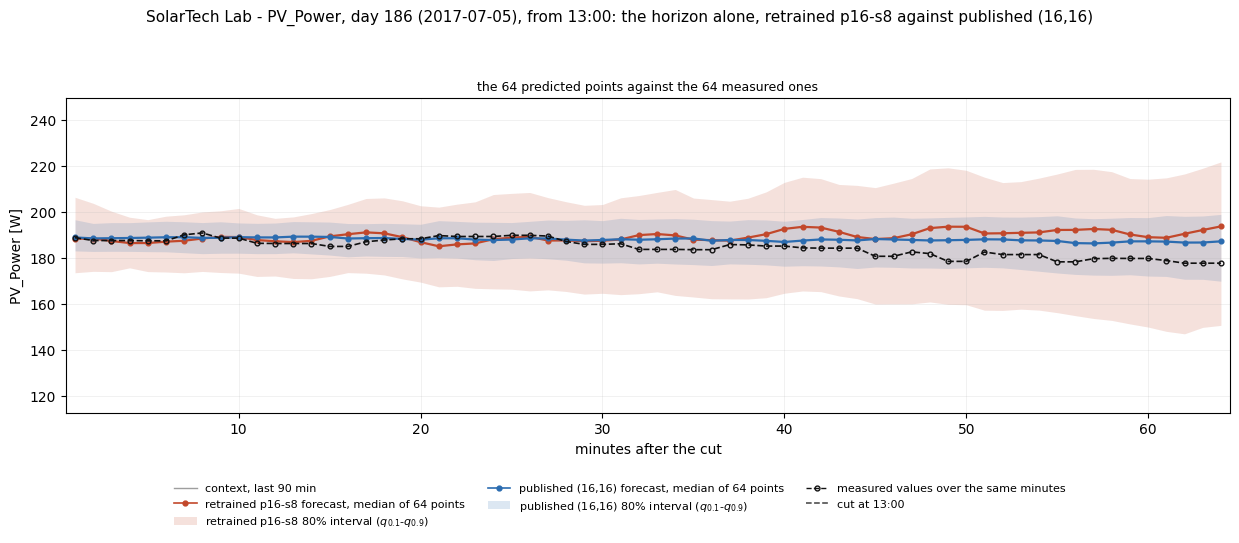

wrote _run\solar\solar_forecast_day186_1300_p16-s8_error.png


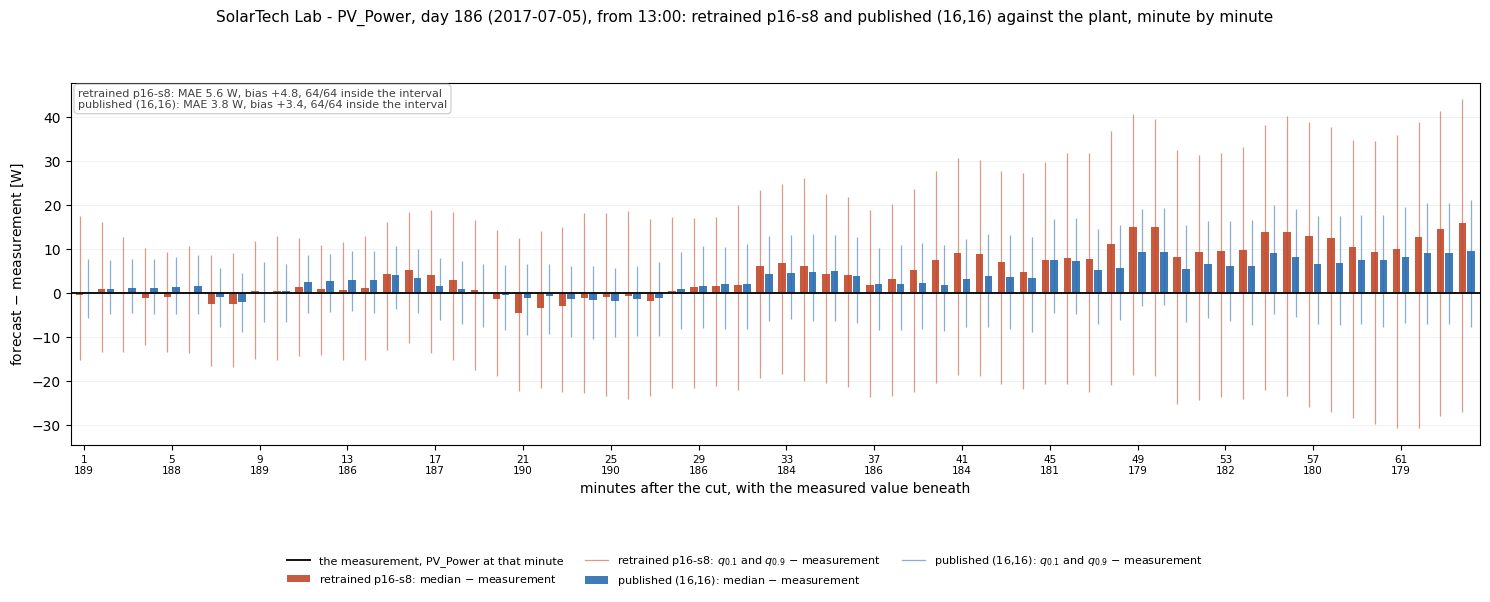

wrote _run\solar\solar_forecast_day186_1300_p16-s12_both.png


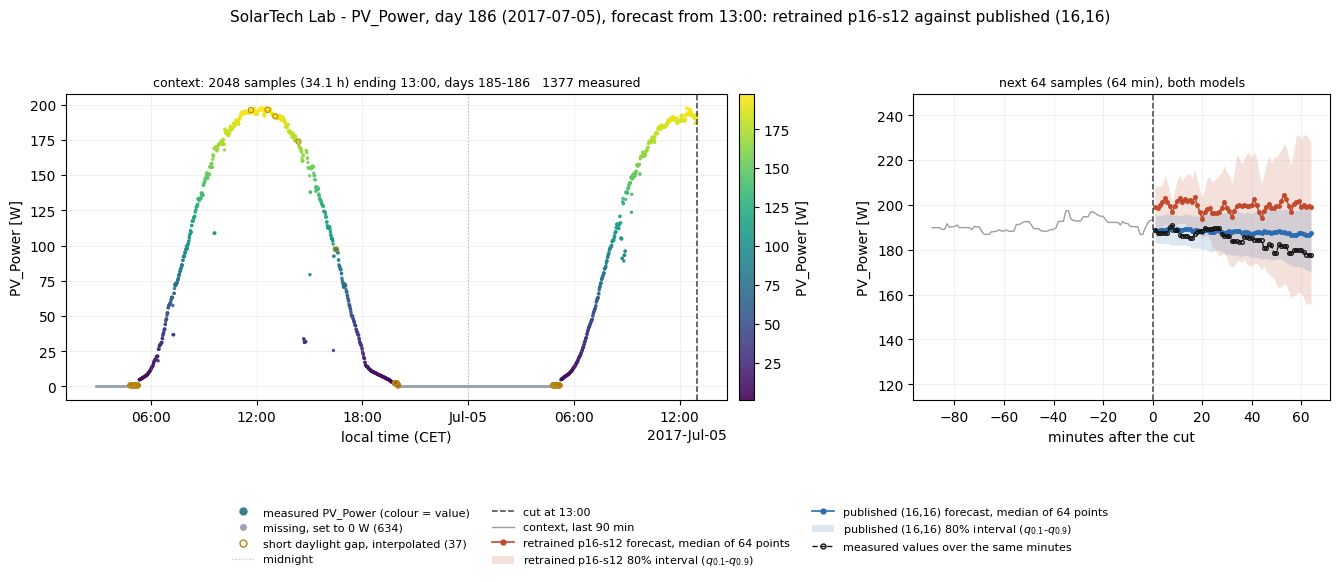

wrote _run\solar\solar_forecast_day186_1300_p16-s12_horizon.png


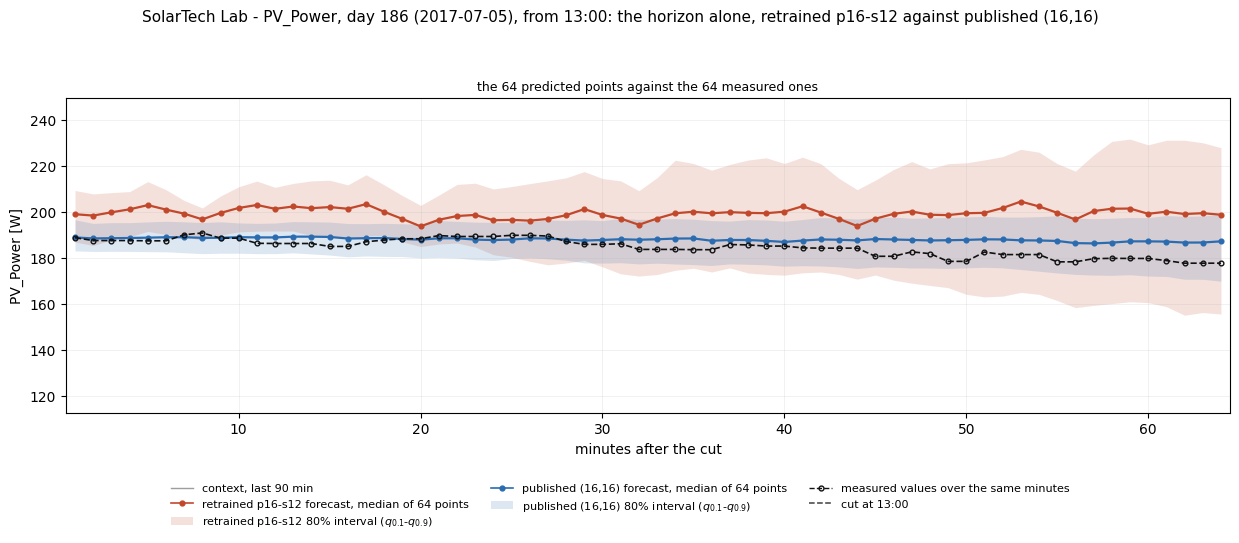

wrote _run\solar\solar_forecast_day186_1300_p16-s12_error.png


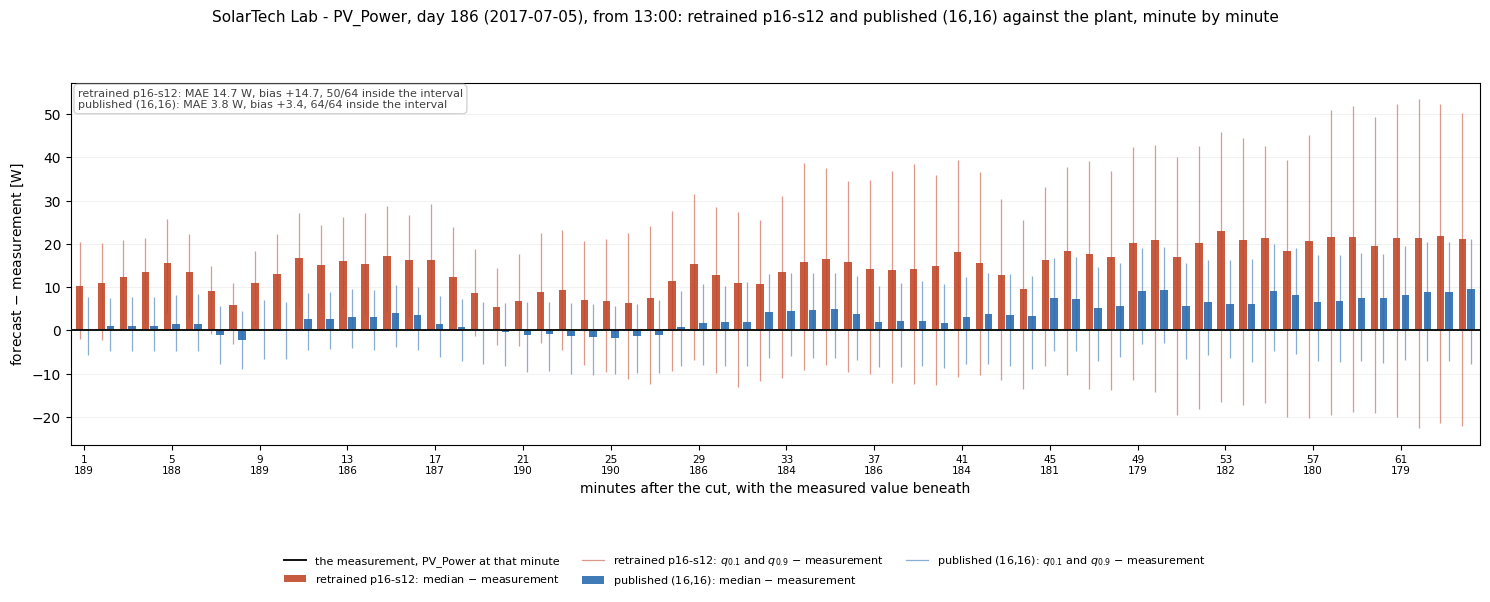

wrote _run\solar\solar_forecast_day186_1300_p16-s16_both.png


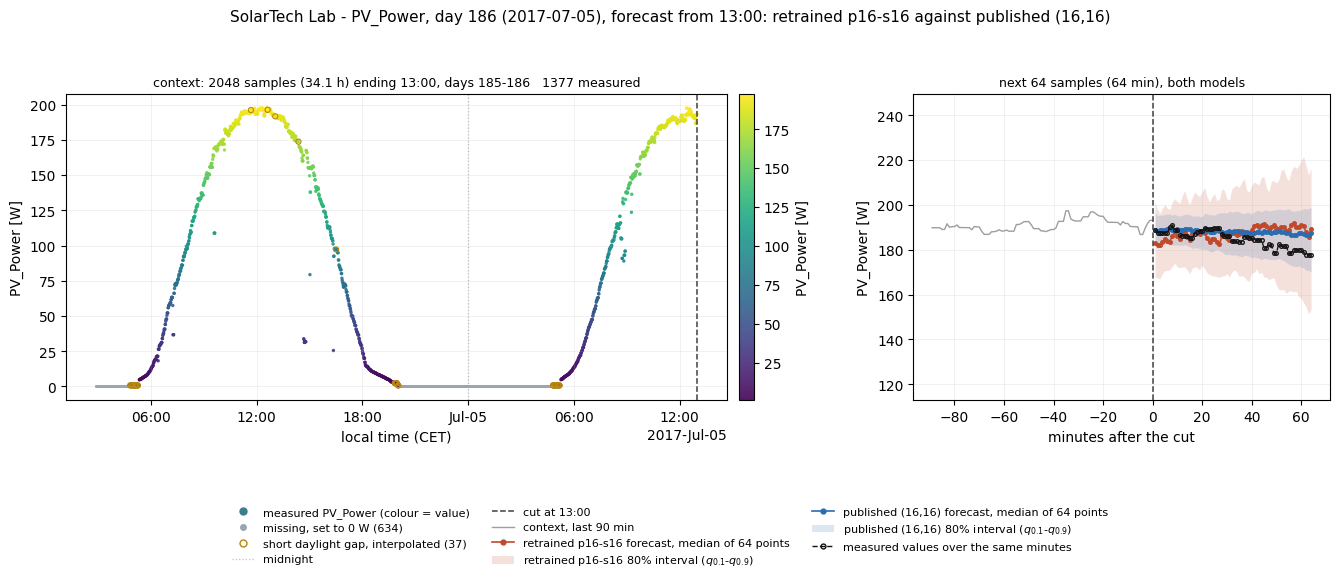

wrote _run\solar\solar_forecast_day186_1300_p16-s16_horizon.png


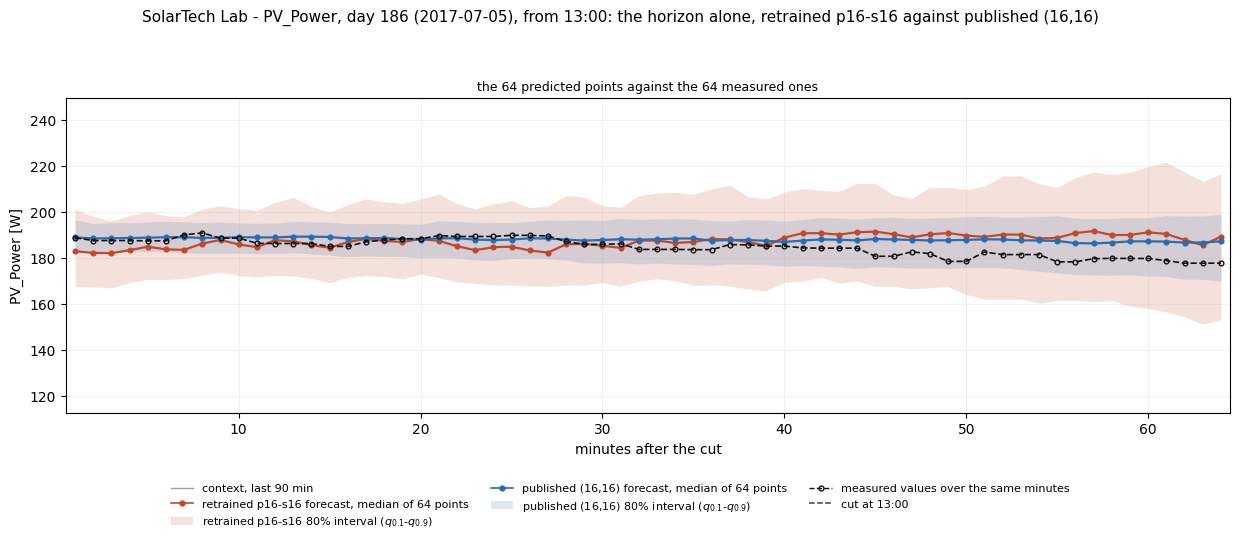

wrote _run\solar\solar_forecast_day186_1300_p16-s16_error.png


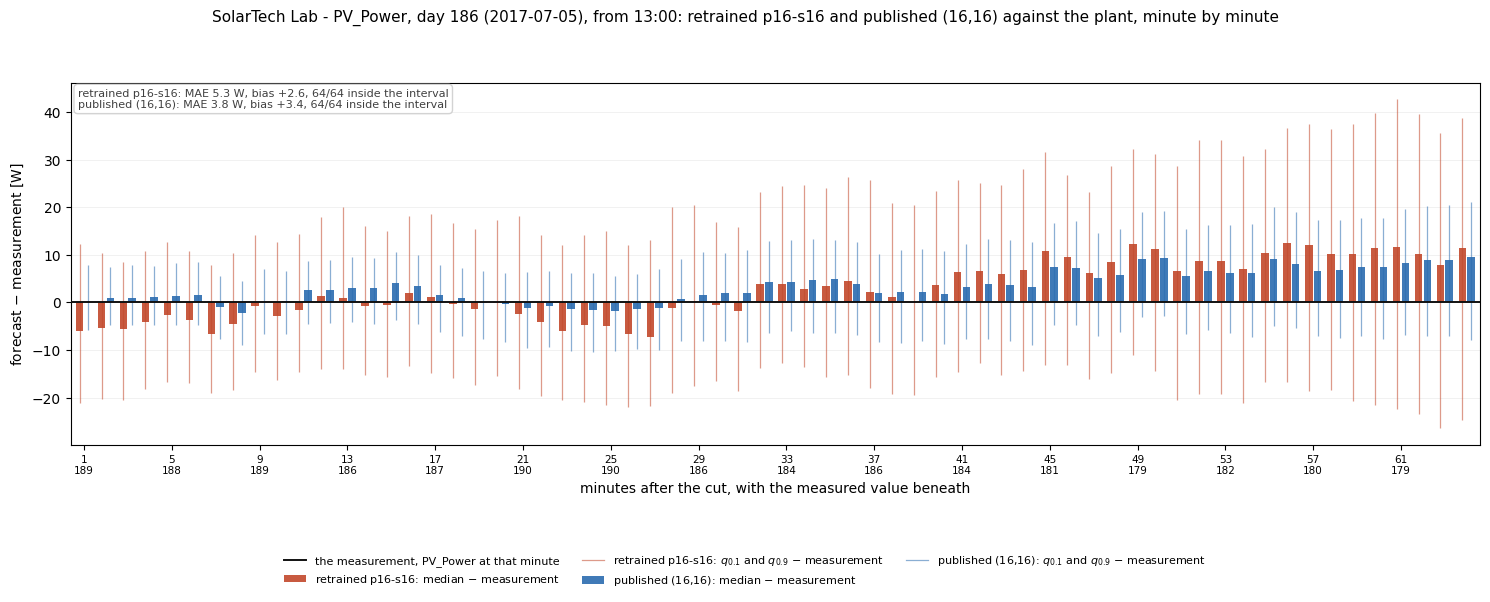

wrote _run\solar\solar_forecast_day186_1300_p24-s8_both.png


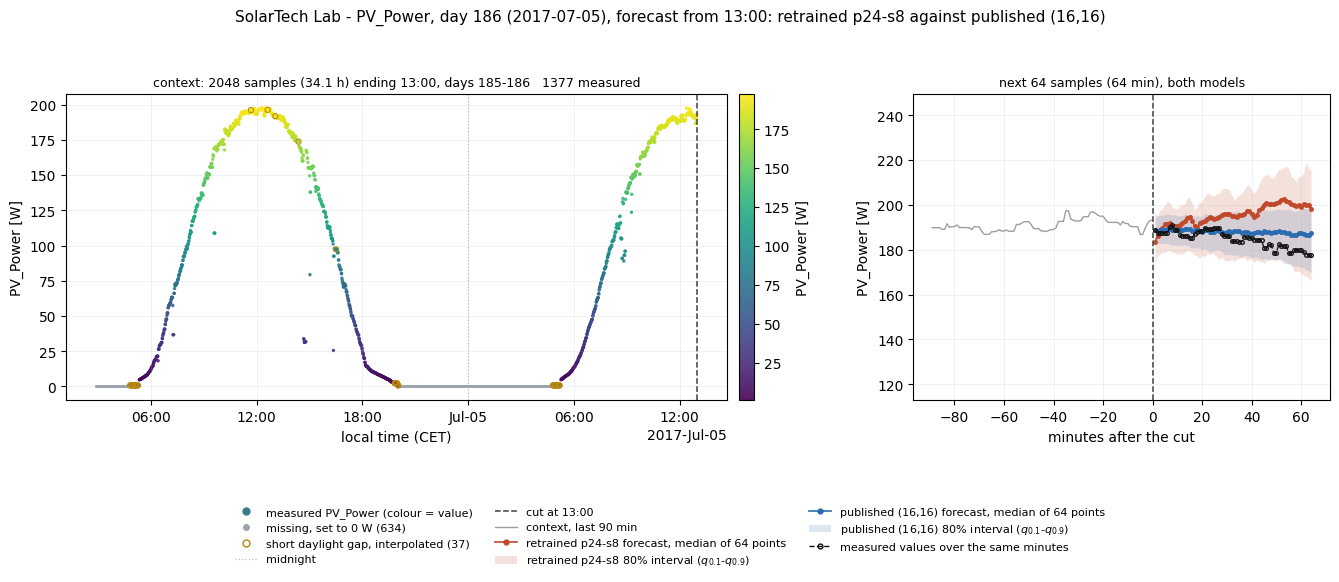

wrote _run\solar\solar_forecast_day186_1300_p24-s8_horizon.png


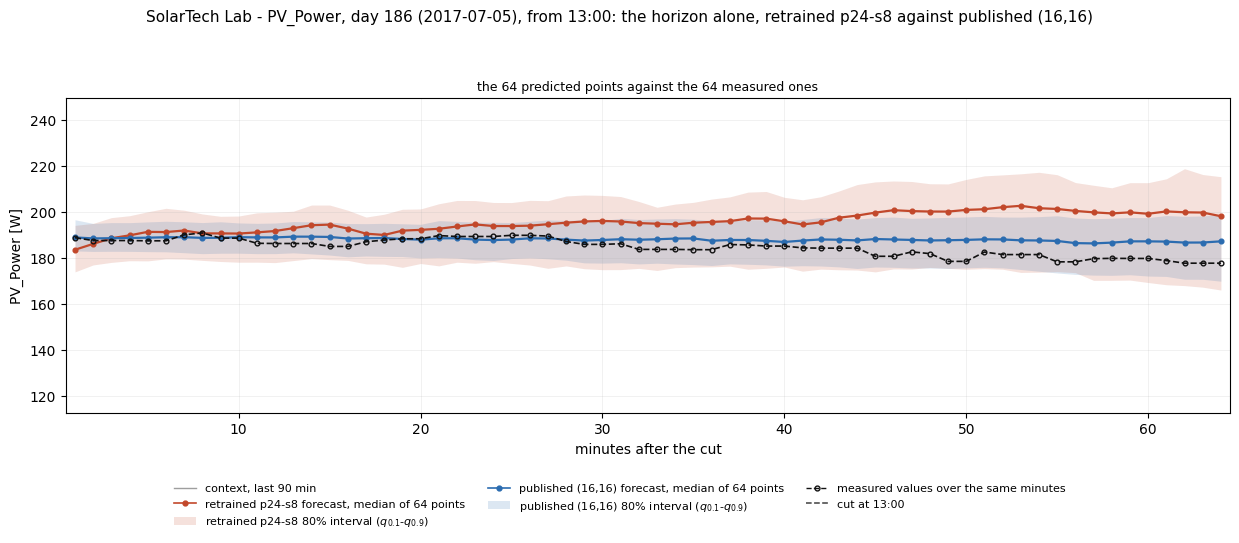

wrote _run\solar\solar_forecast_day186_1300_p24-s8_error.png


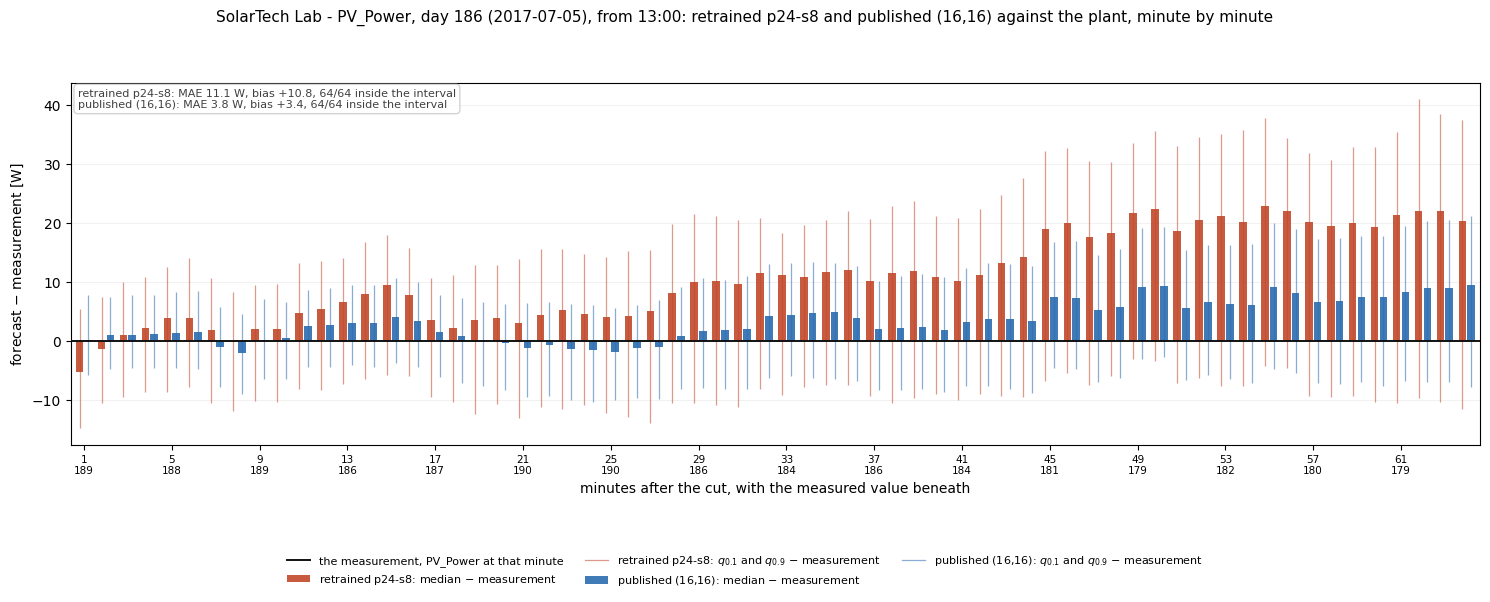

wrote _run\solar\solar_forecast_day186_1300_p24-s12_both.png


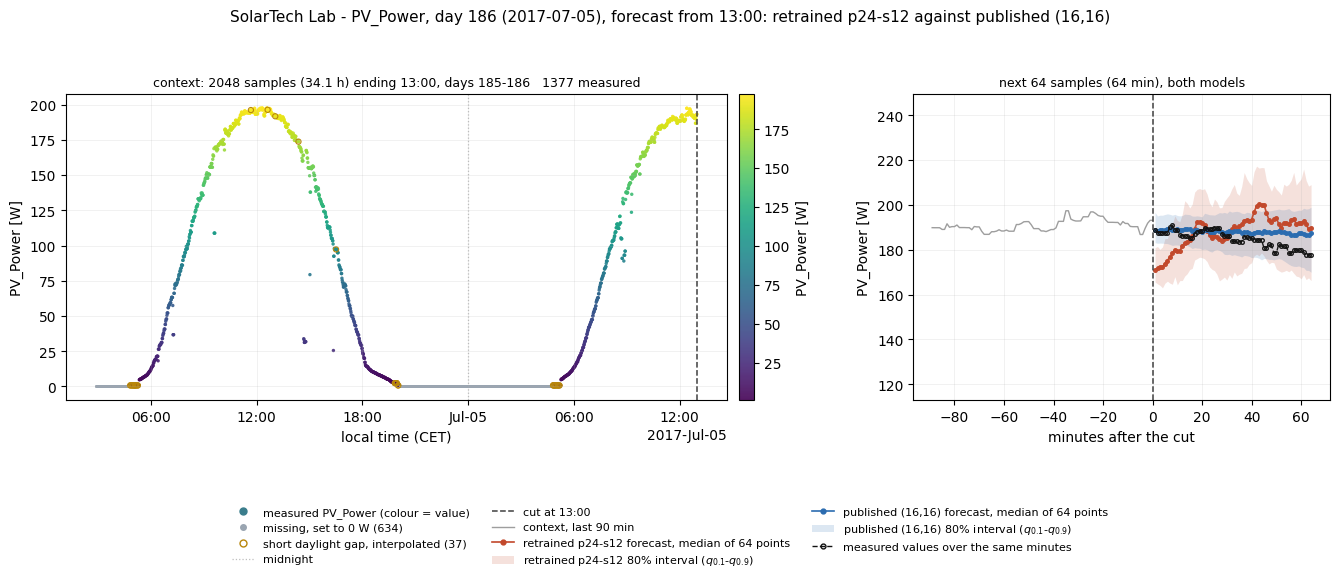

wrote _run\solar\solar_forecast_day186_1300_p24-s12_horizon.png


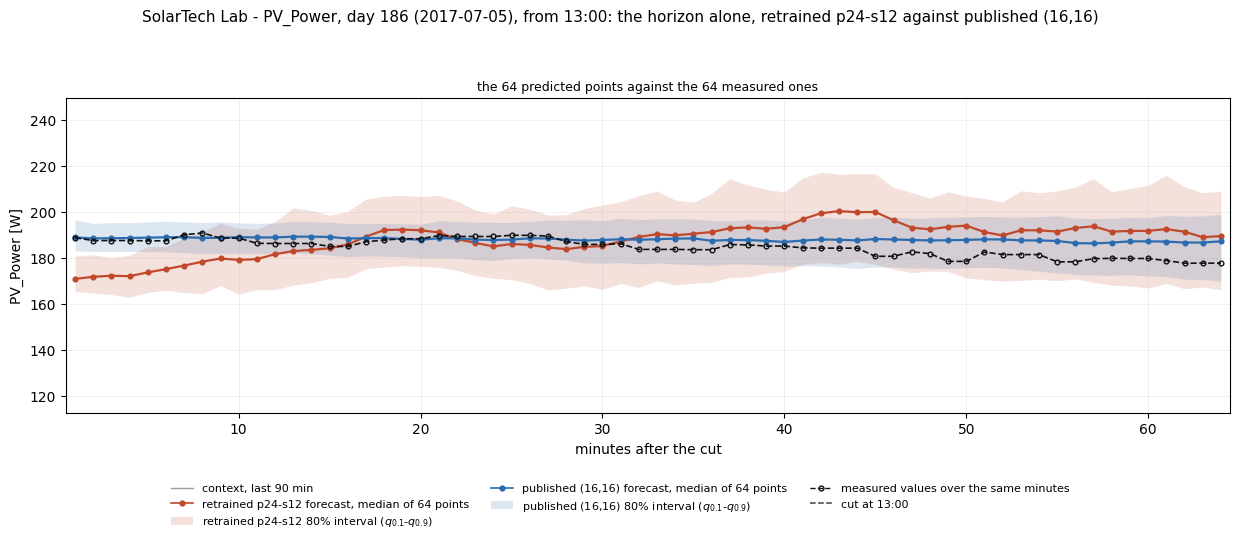

wrote _run\solar\solar_forecast_day186_1300_p24-s12_error.png


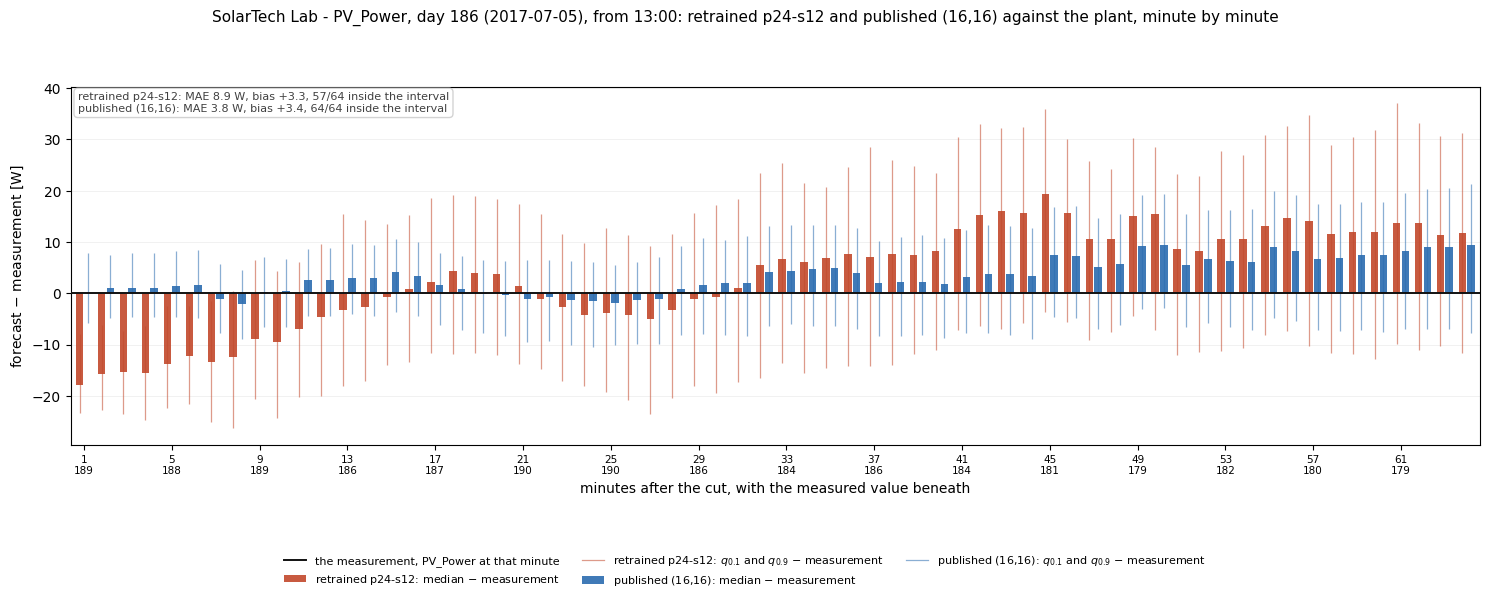

wrote _run\solar\solar_forecast_day186_1300_p24-s16_both.png


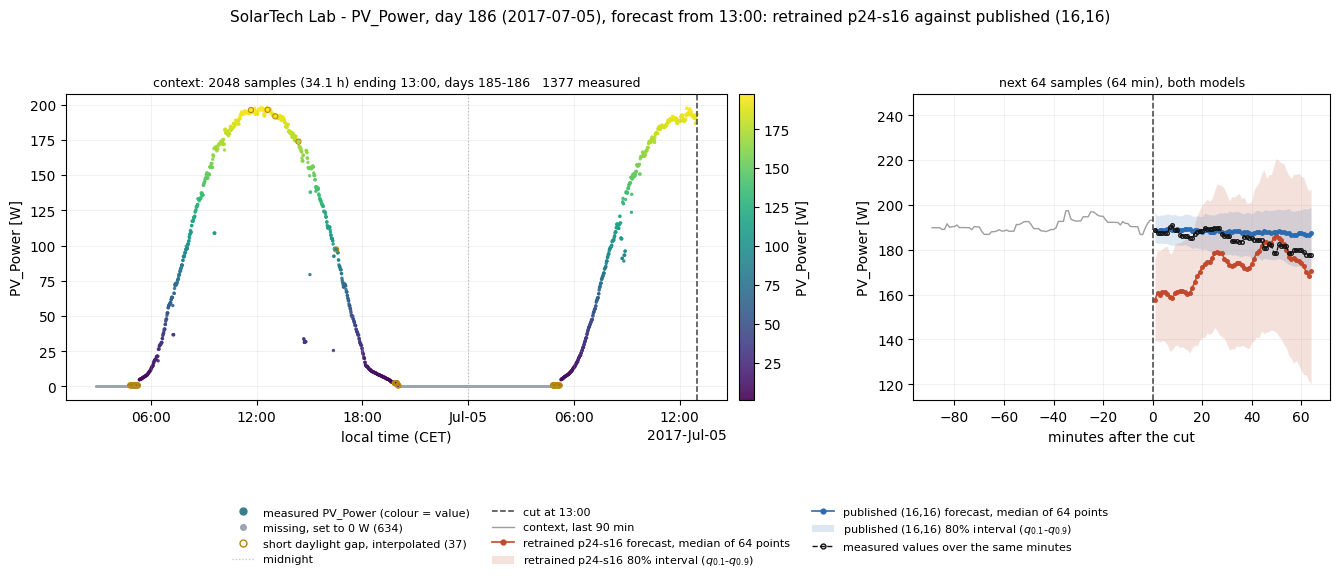

wrote _run\solar\solar_forecast_day186_1300_p24-s16_horizon.png


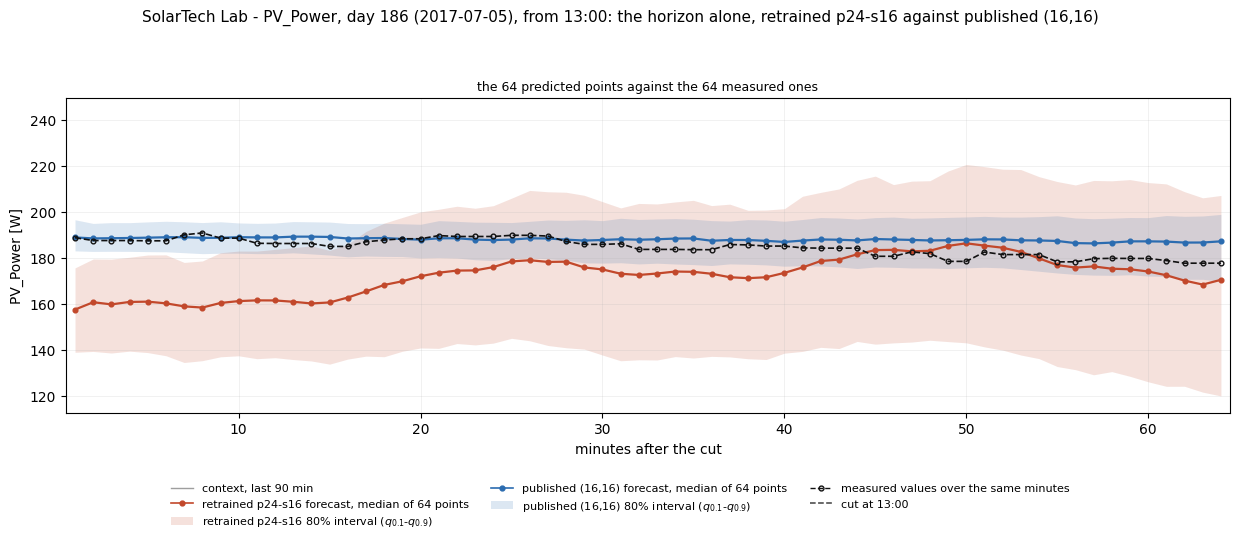

wrote _run\solar\solar_forecast_day186_1300_p24-s16_error.png


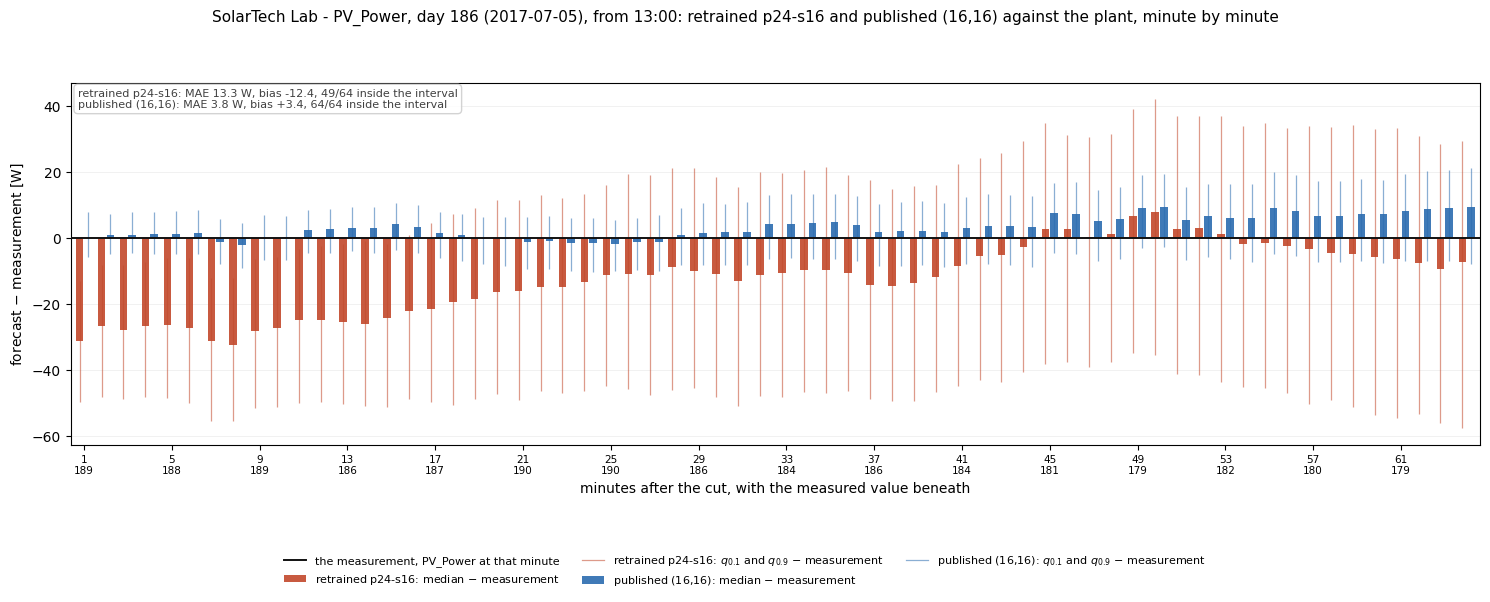

wrote _run\solar\solar_forecast_day186_1300_p24-s20_both.png


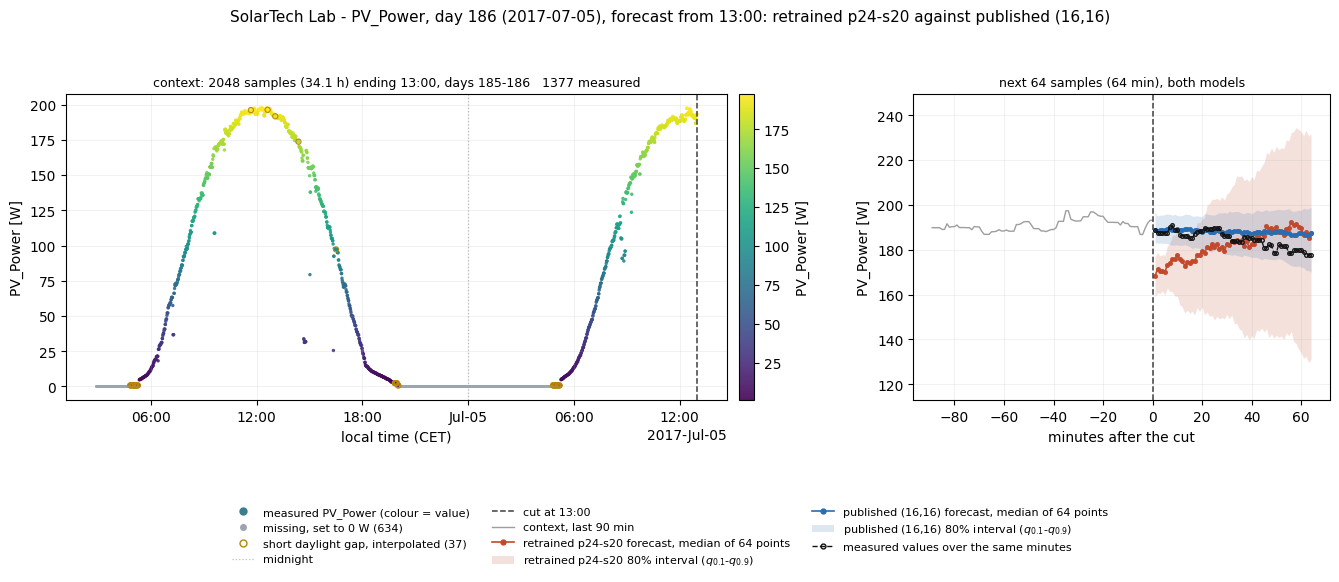

wrote _run\solar\solar_forecast_day186_1300_p24-s20_horizon.png


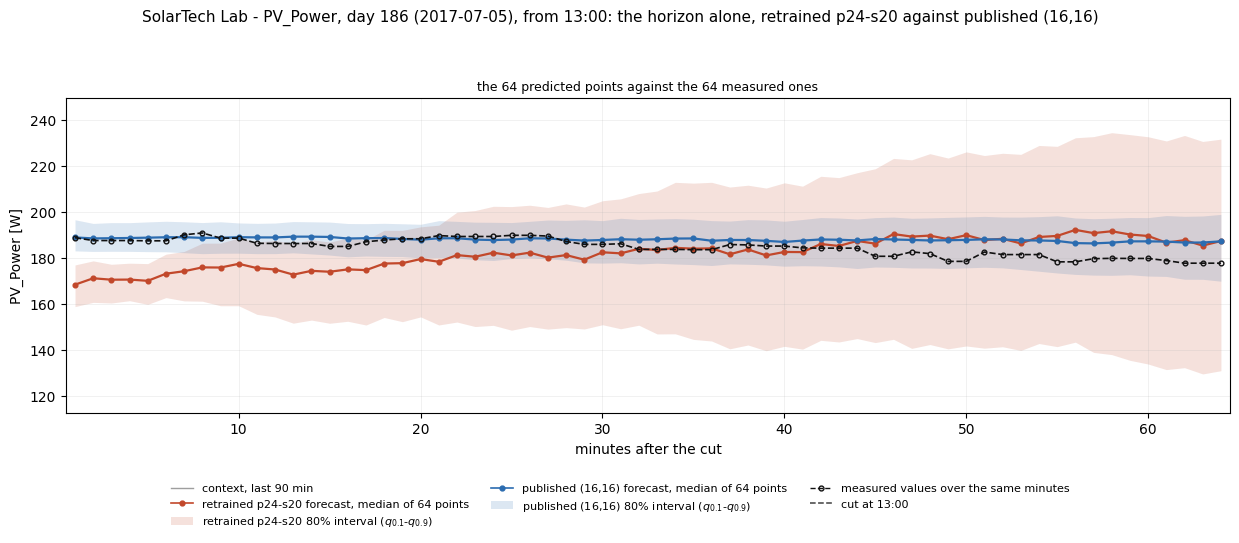

wrote _run\solar\solar_forecast_day186_1300_p24-s20_error.png


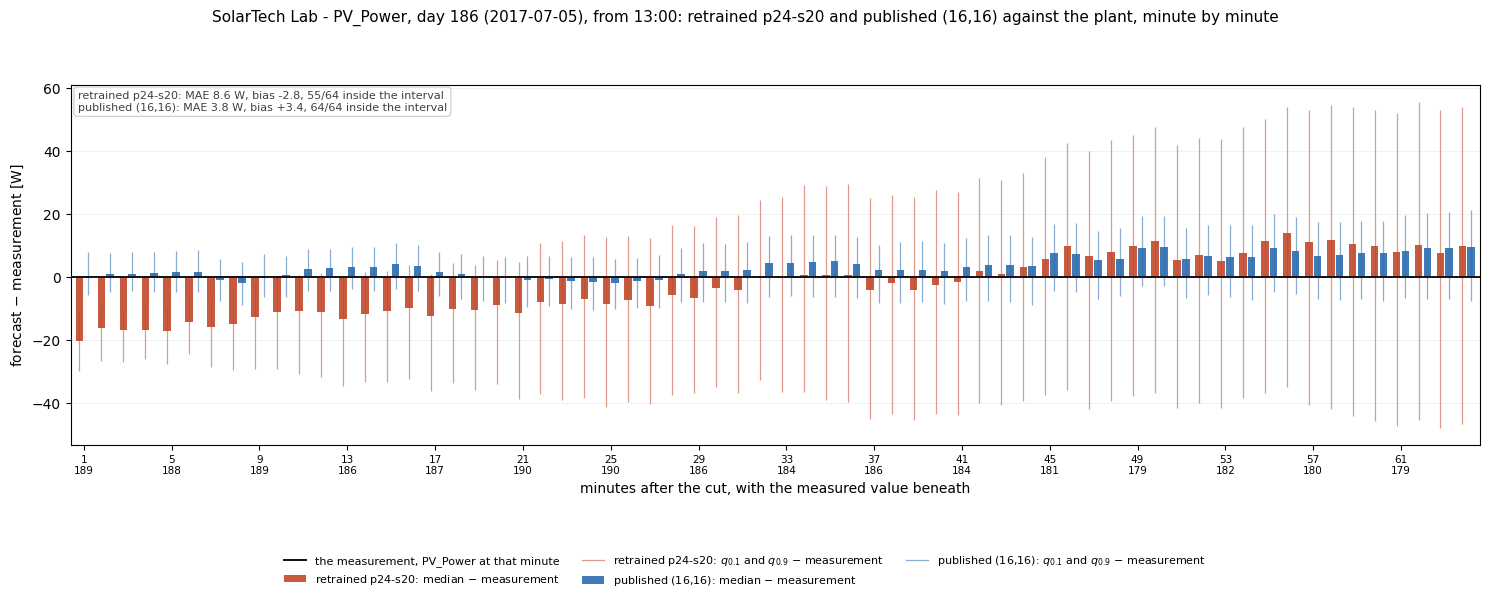

wrote _run\solar\solar_forecast_day186_1300_p24-s24_both.png


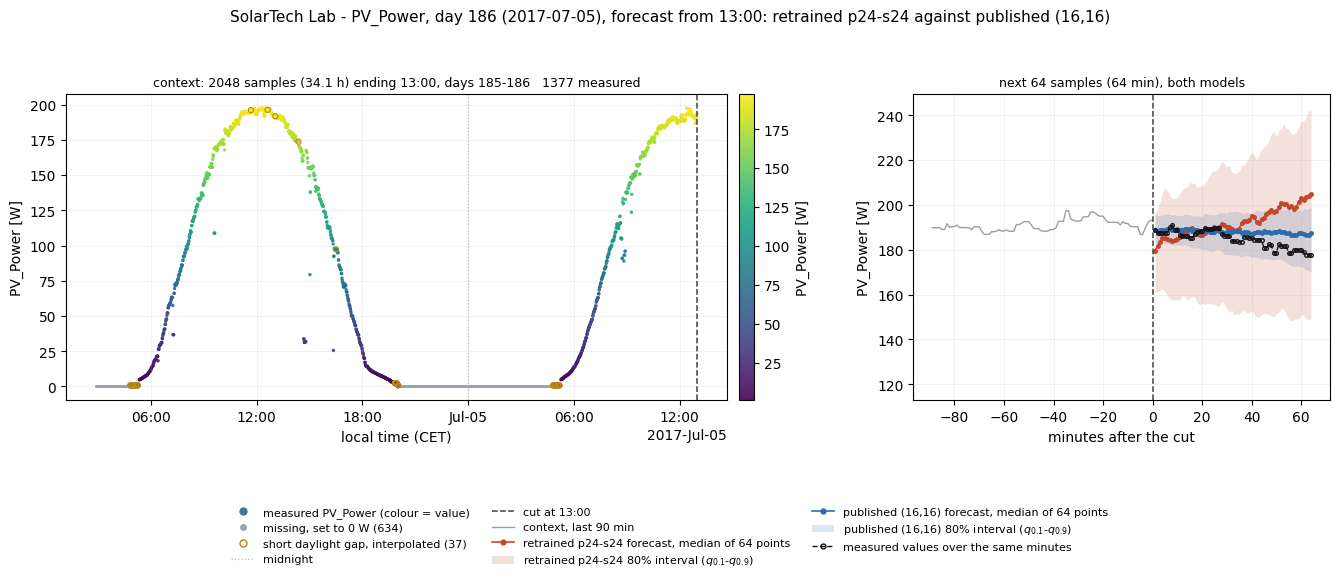

wrote _run\solar\solar_forecast_day186_1300_p24-s24_horizon.png


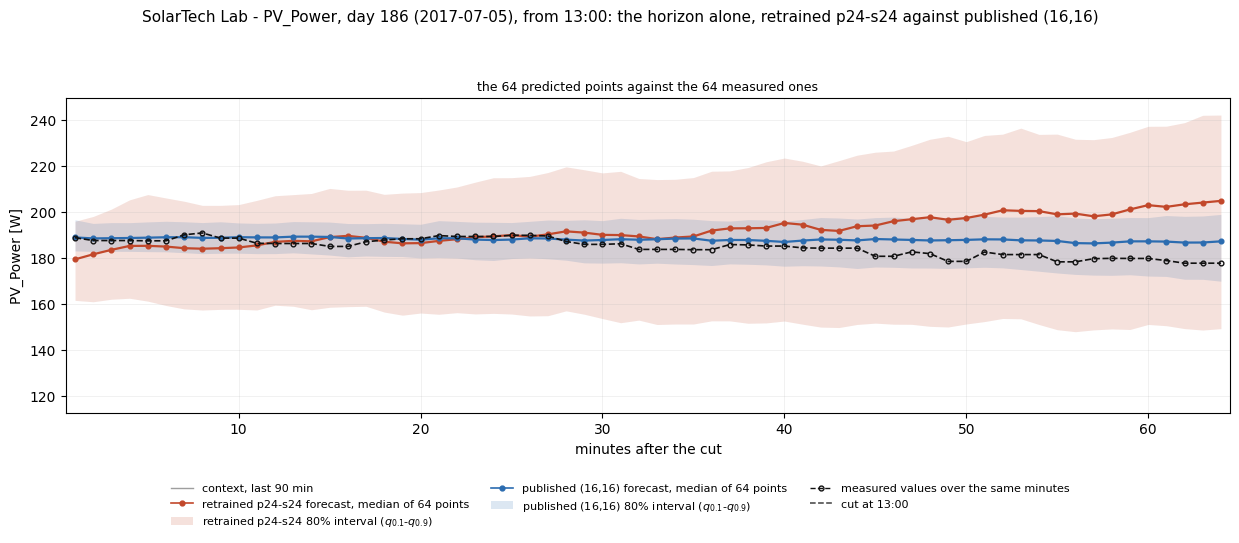

wrote _run\solar\solar_forecast_day186_1300_p24-s24_error.png


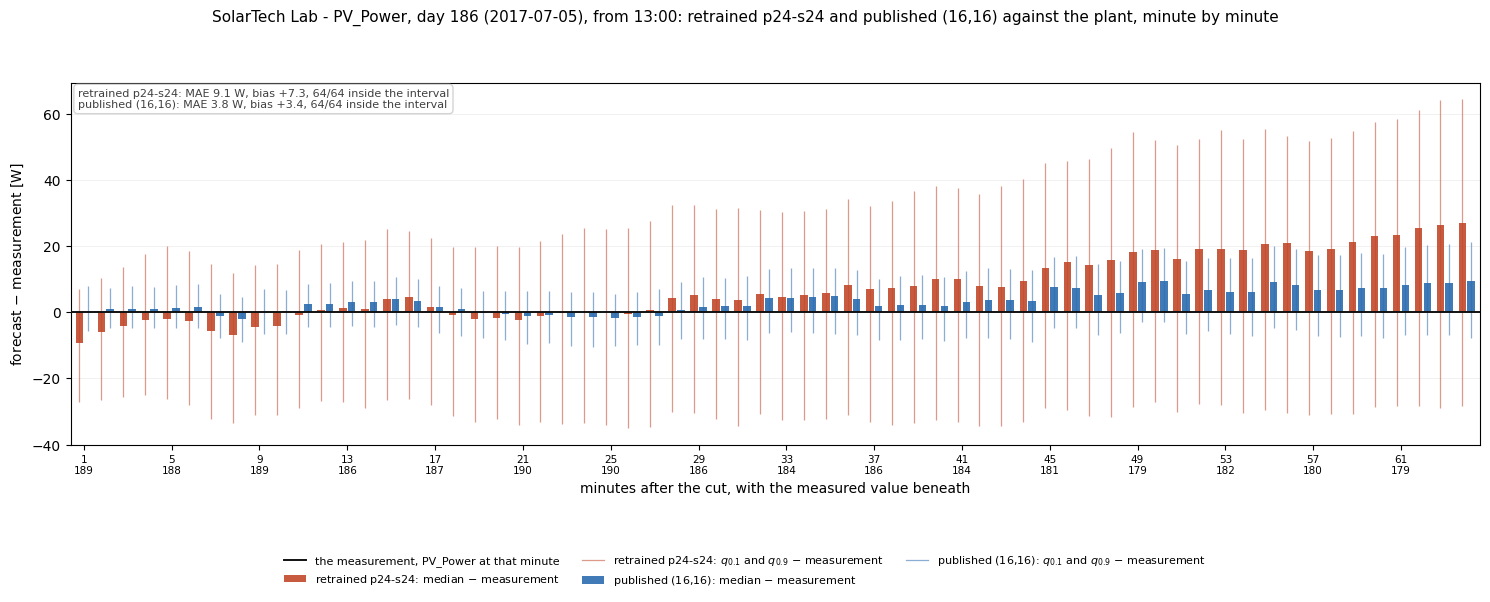

wrote _run\solar\solar_forecast_day186_1300_p32-s8_both.png


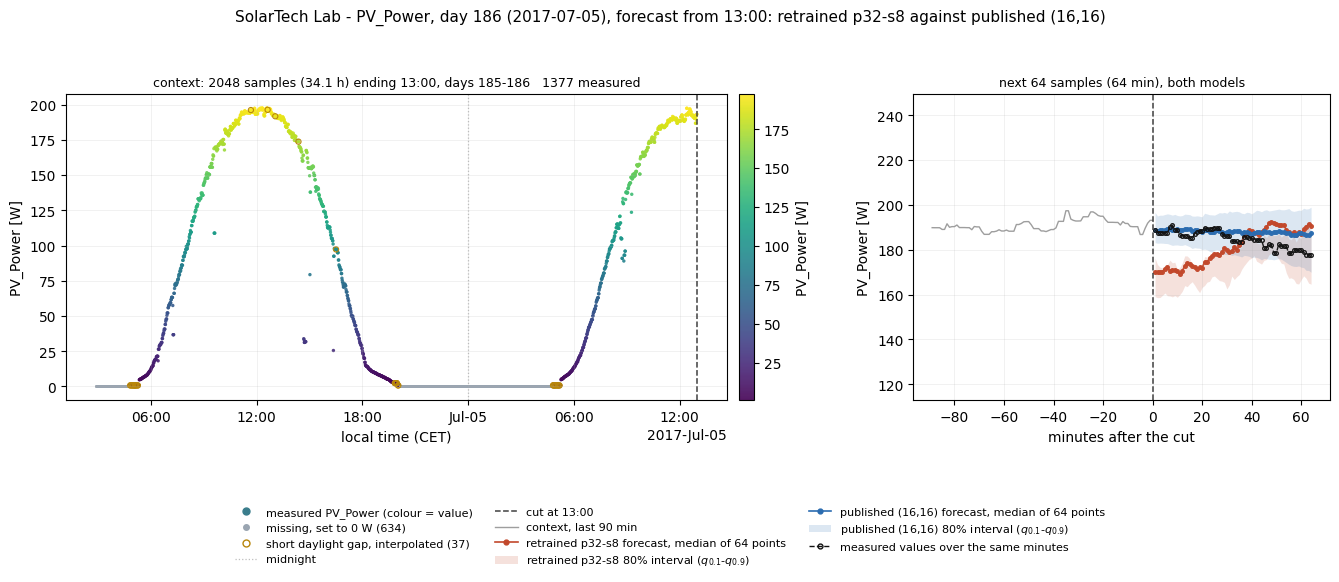

wrote _run\solar\solar_forecast_day186_1300_p32-s8_horizon.png


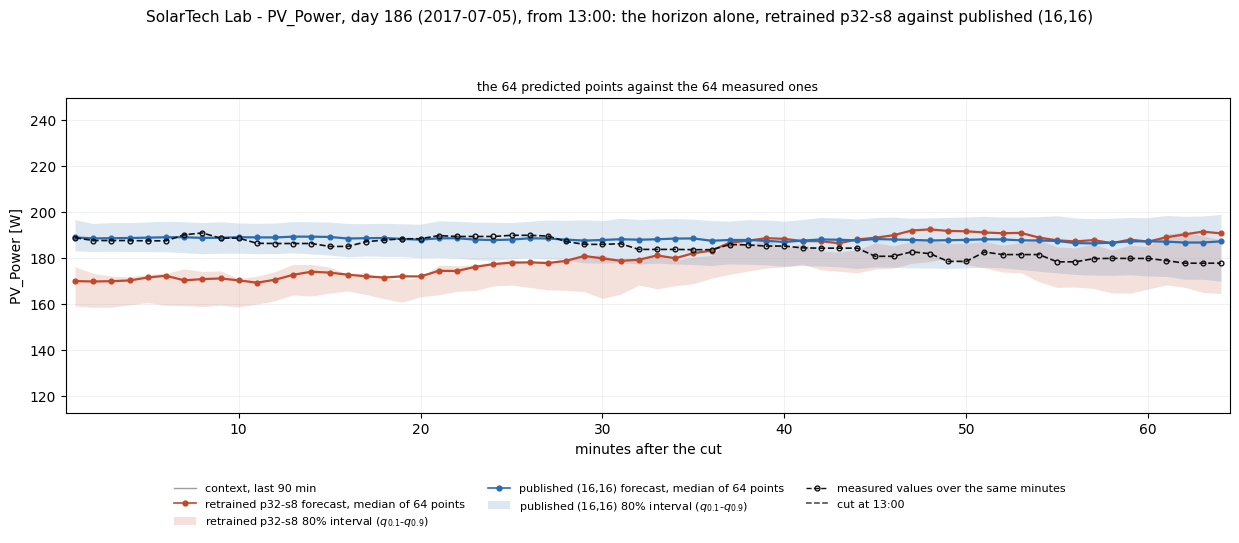

wrote _run\solar\solar_forecast_day186_1300_p32-s8_error.png


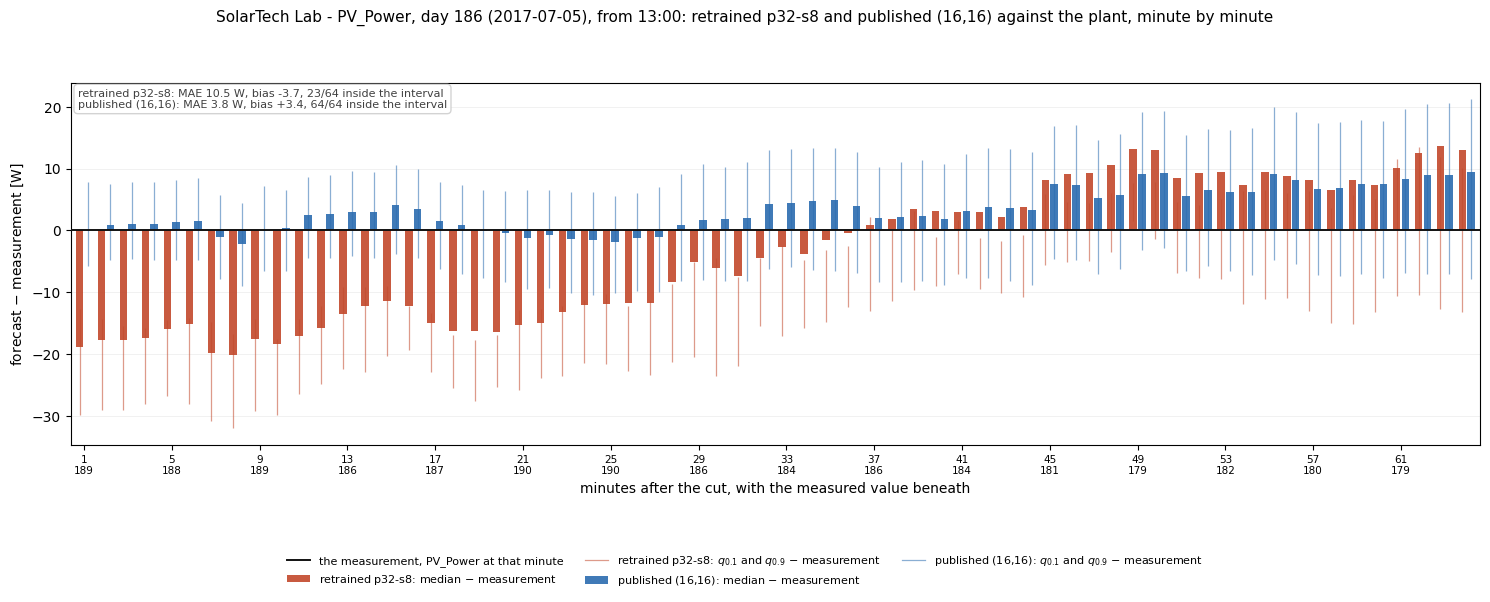

wrote _run\solar\solar_forecast_day186_1300_p32-s12_both.png


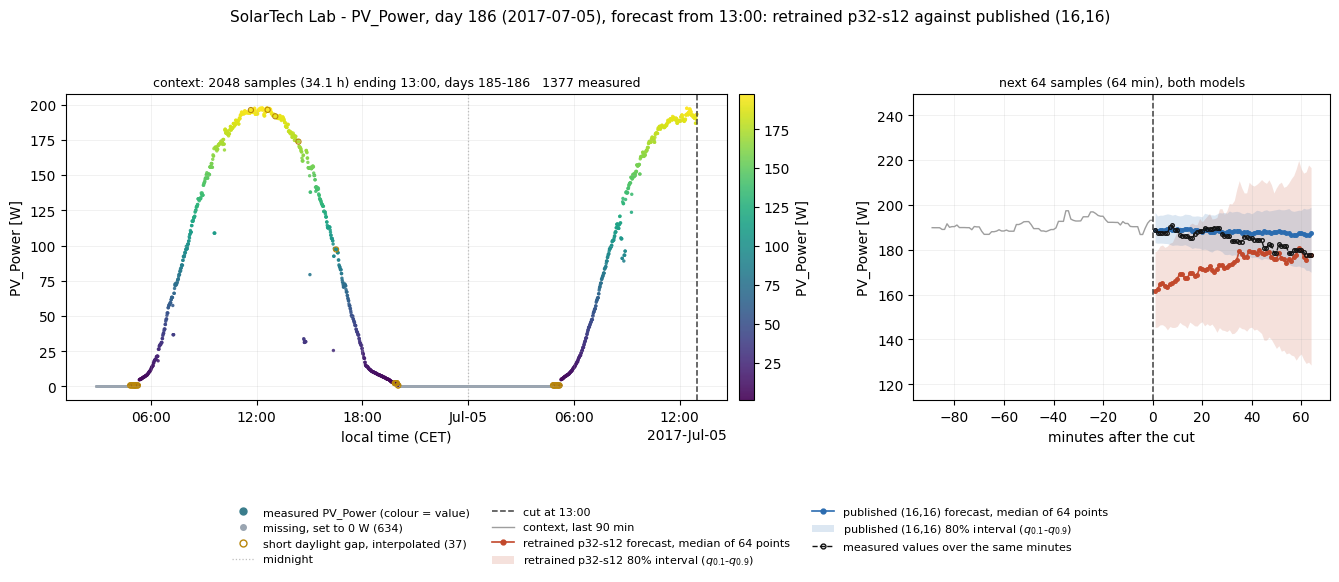

wrote _run\solar\solar_forecast_day186_1300_p32-s12_horizon.png


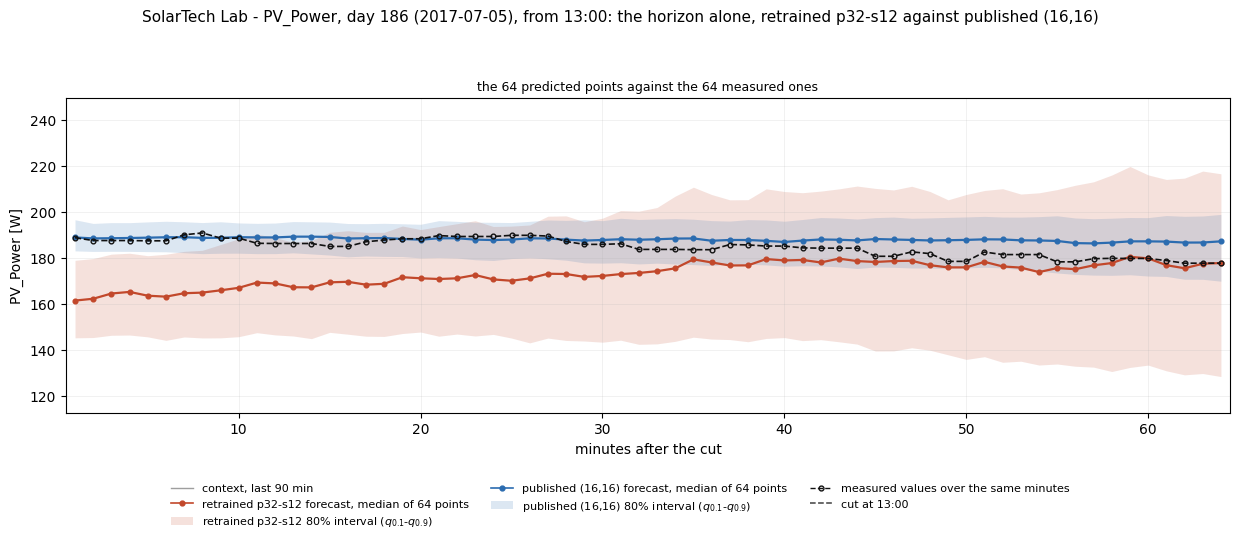

wrote _run\solar\solar_forecast_day186_1300_p32-s12_error.png


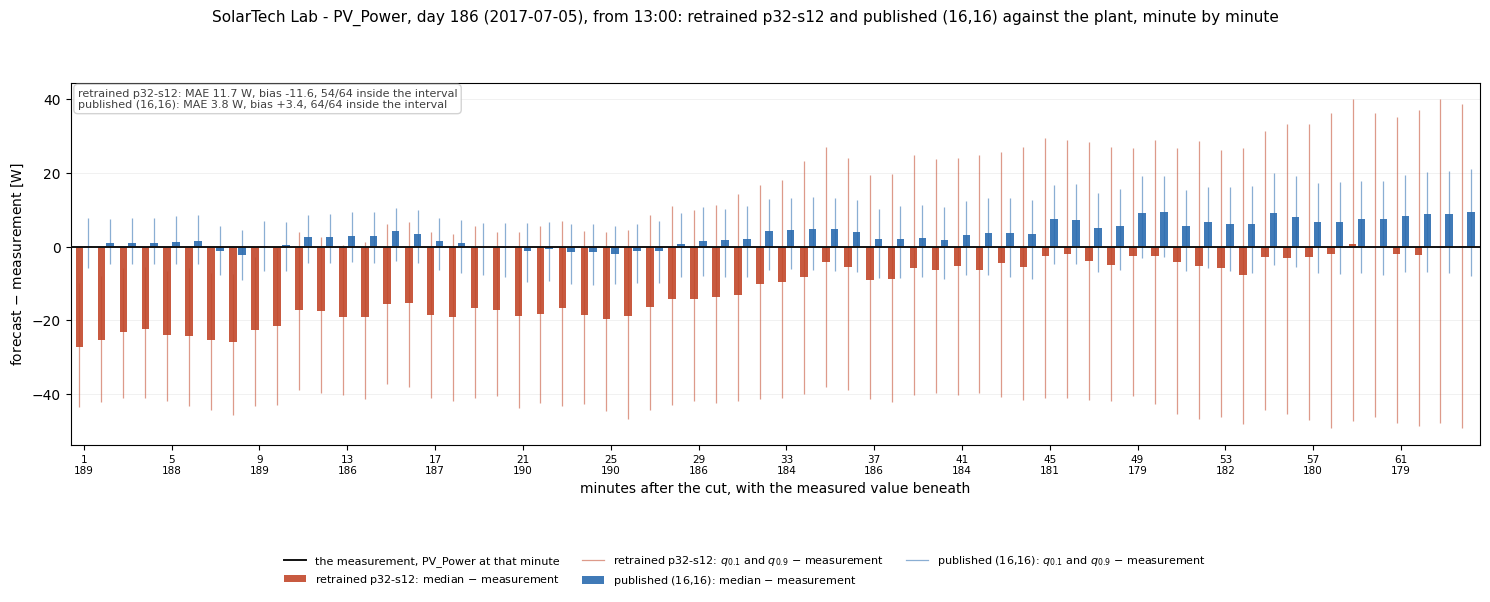

wrote _run\solar\solar_forecast_day186_1300_p32-s16_both.png


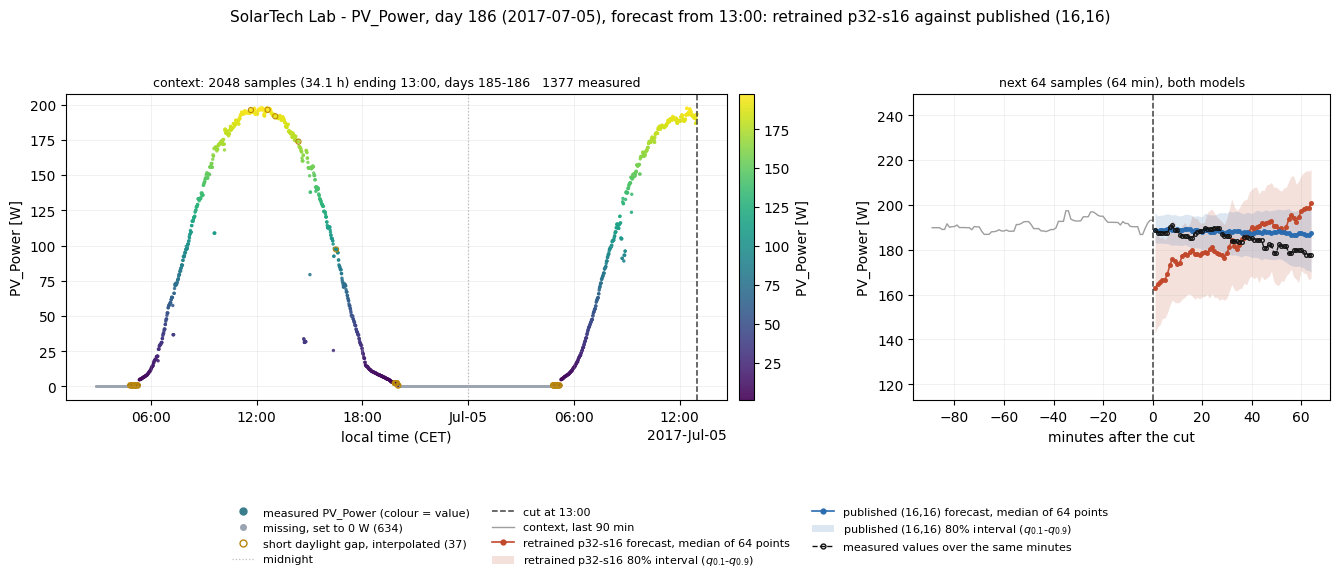

wrote _run\solar\solar_forecast_day186_1300_p32-s16_horizon.png


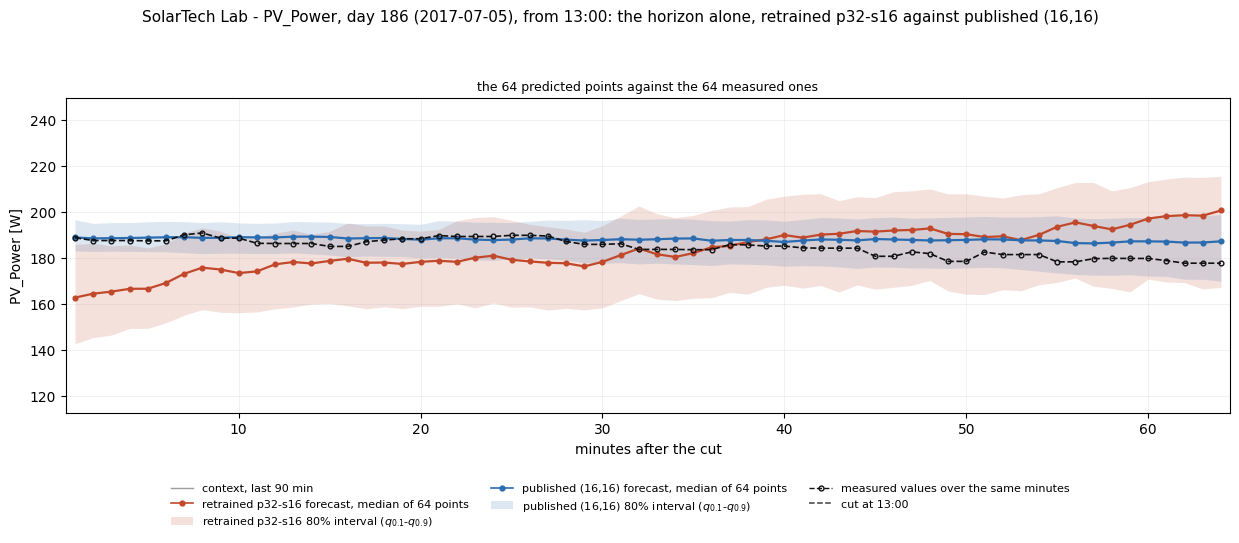

wrote _run\solar\solar_forecast_day186_1300_p32-s16_error.png


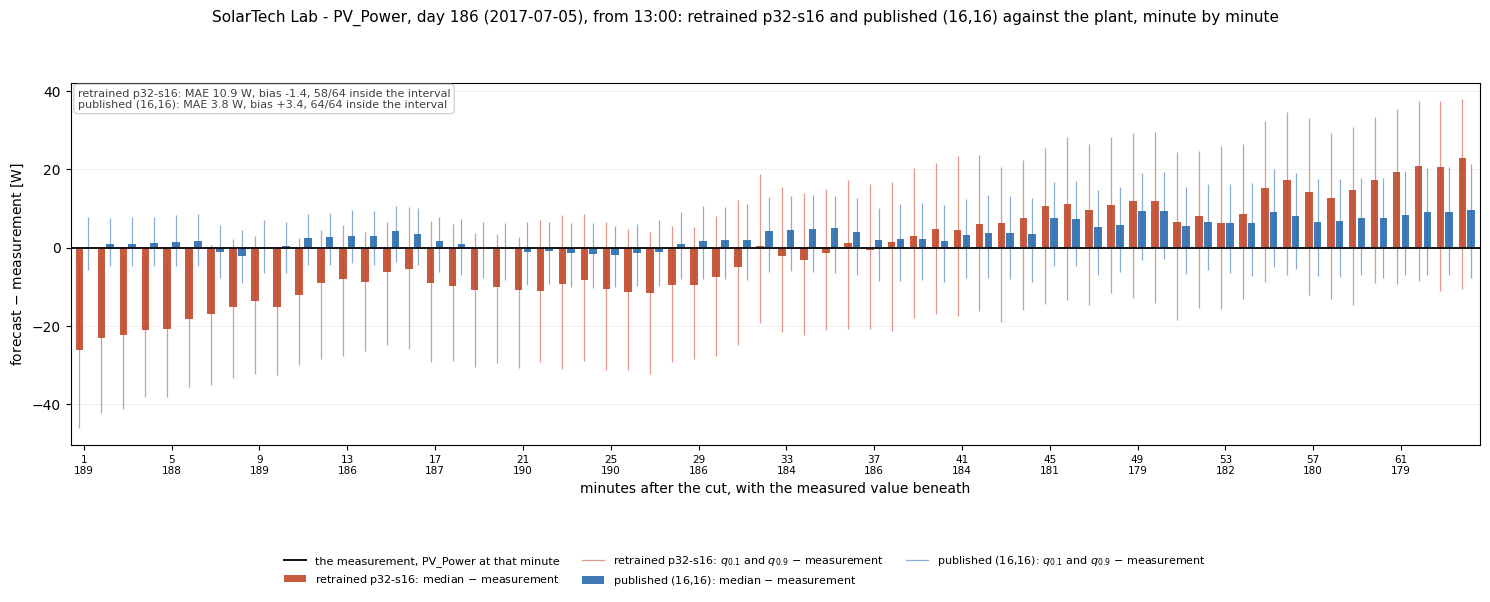

wrote _run\solar\solar_forecast_day186_1300_p32-s20_both.png


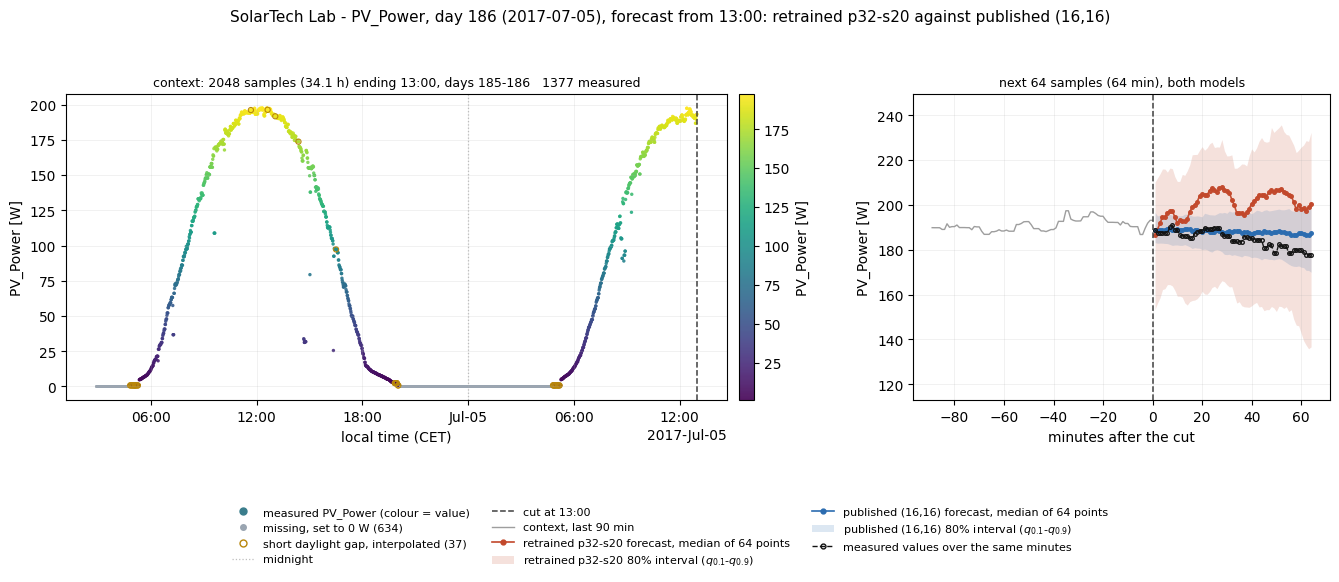

wrote _run\solar\solar_forecast_day186_1300_p32-s20_horizon.png


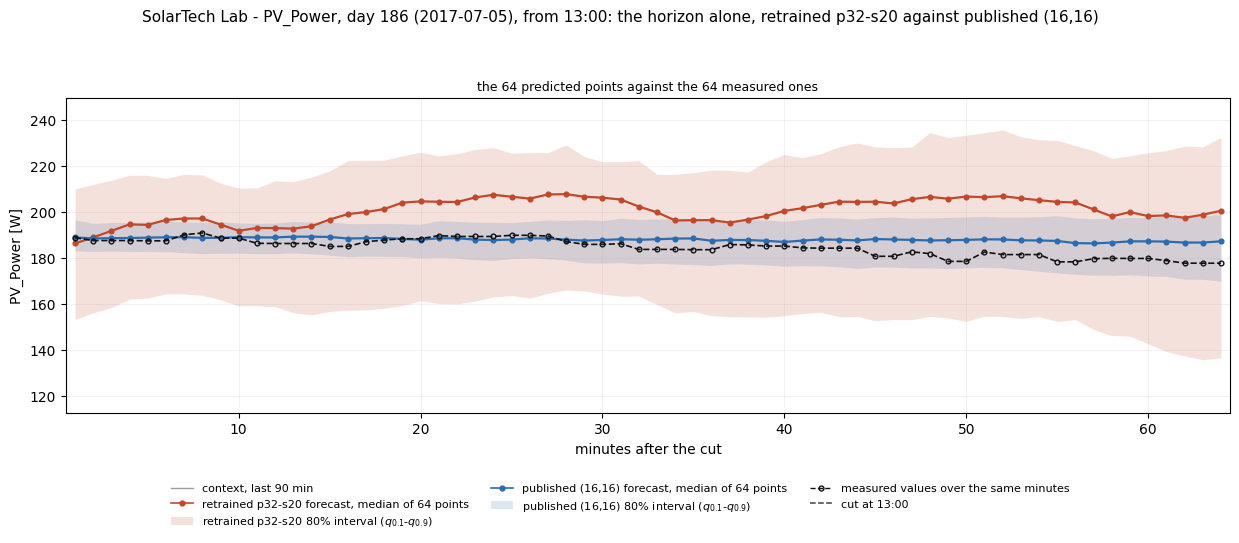

wrote _run\solar\solar_forecast_day186_1300_p32-s20_error.png


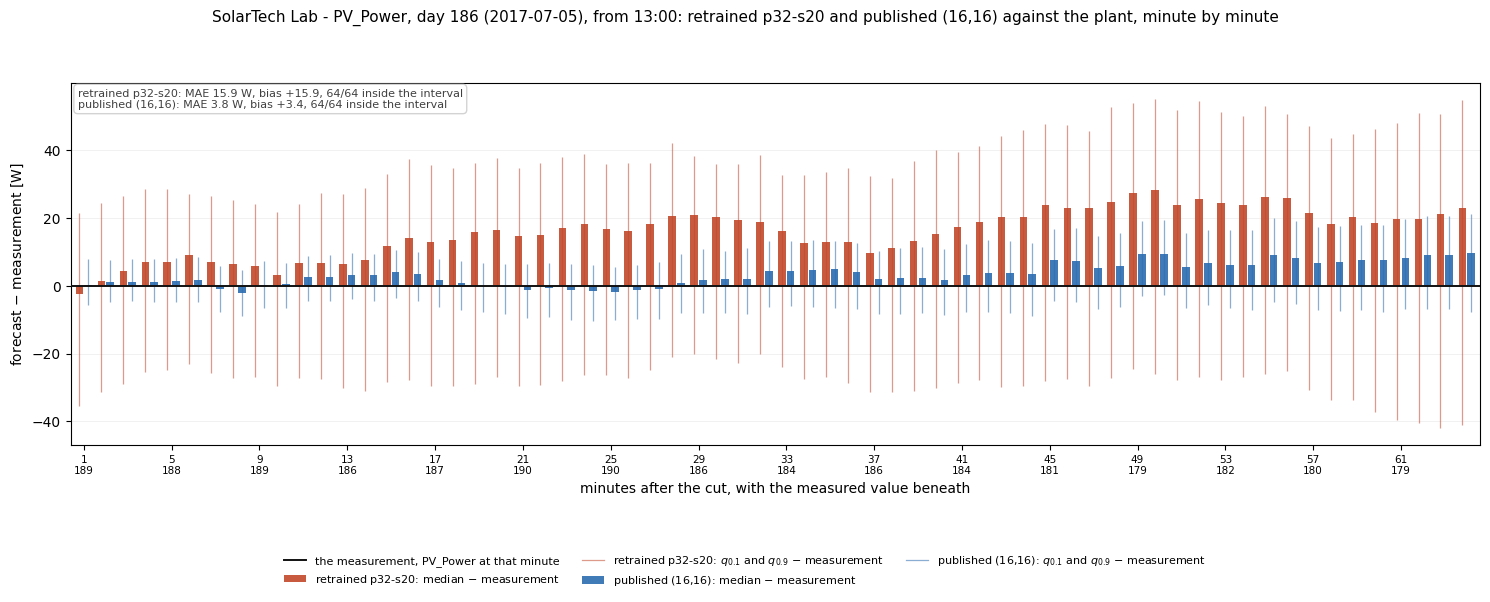

wrote _run\solar\solar_forecast_day186_1300_p32-s24_both.png


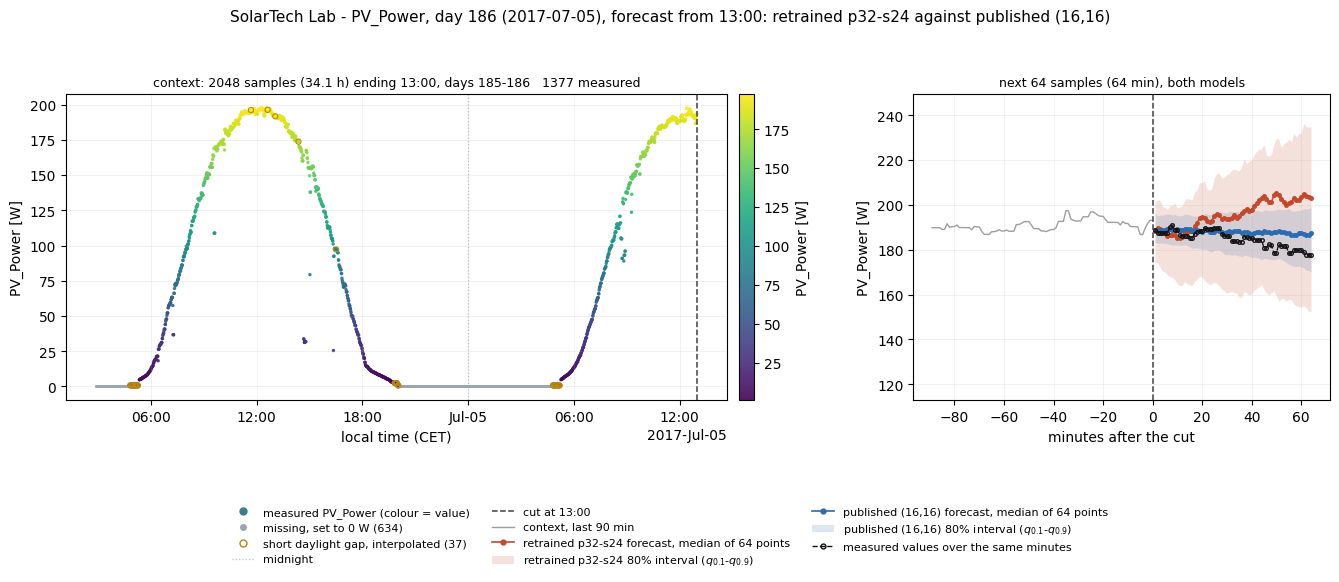

wrote _run\solar\solar_forecast_day186_1300_p32-s24_horizon.png


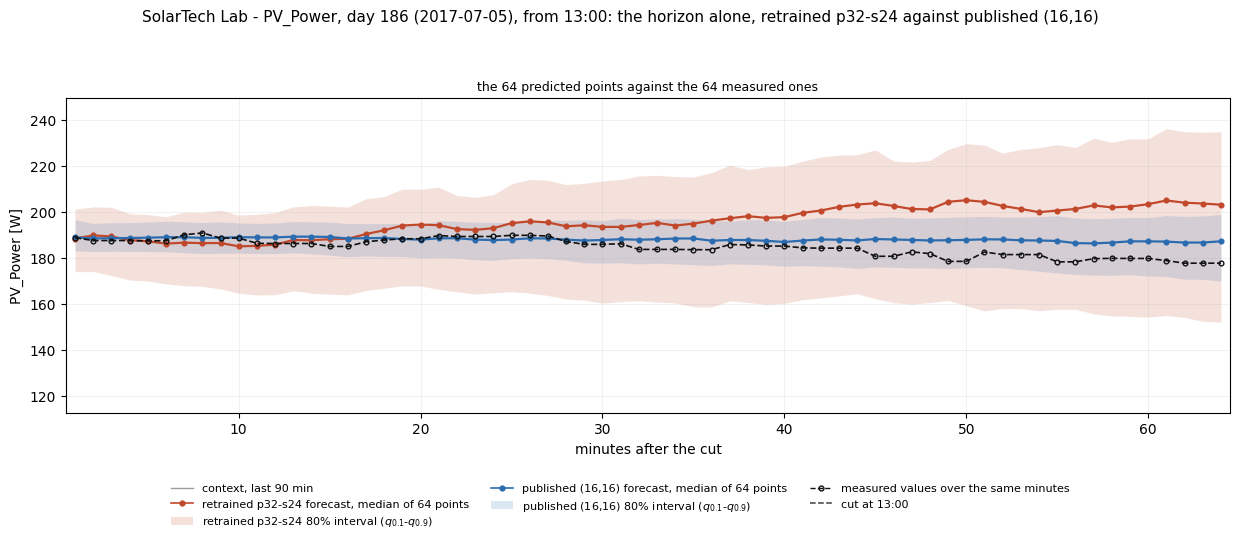

wrote _run\solar\solar_forecast_day186_1300_p32-s24_error.png


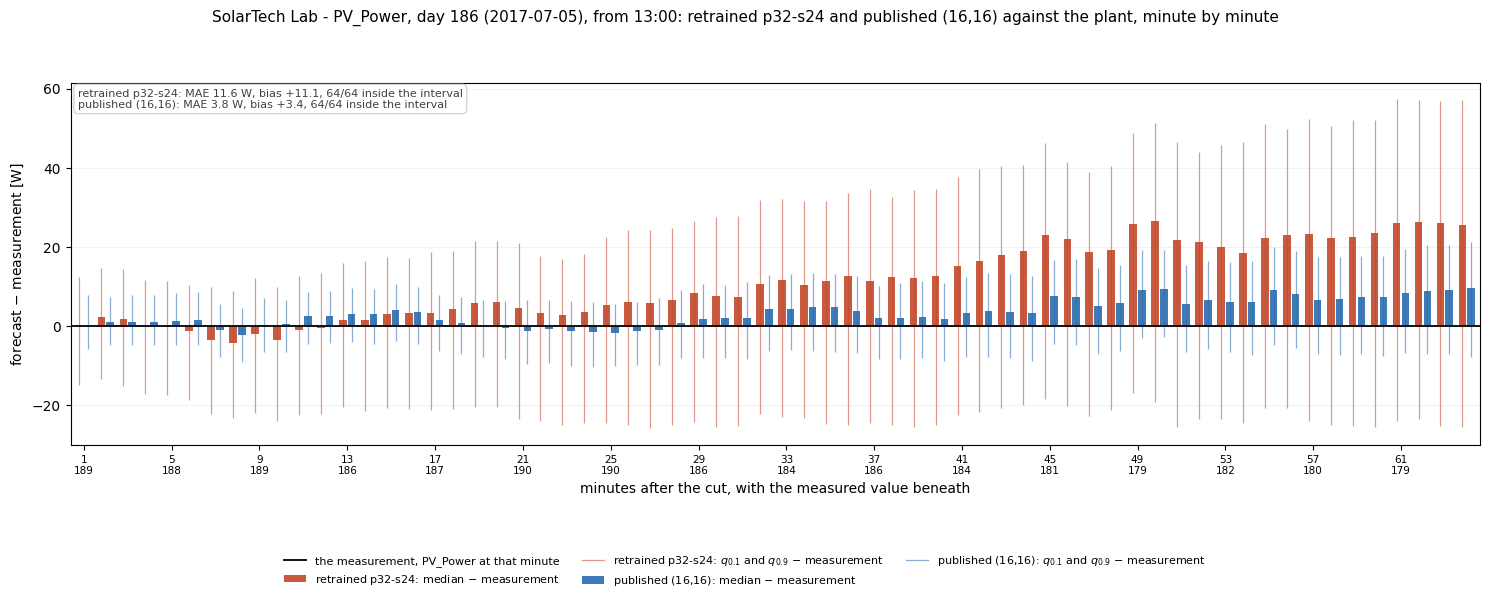

wrote _run\solar\solar_forecast_day186_1300_p32-s32_both.png


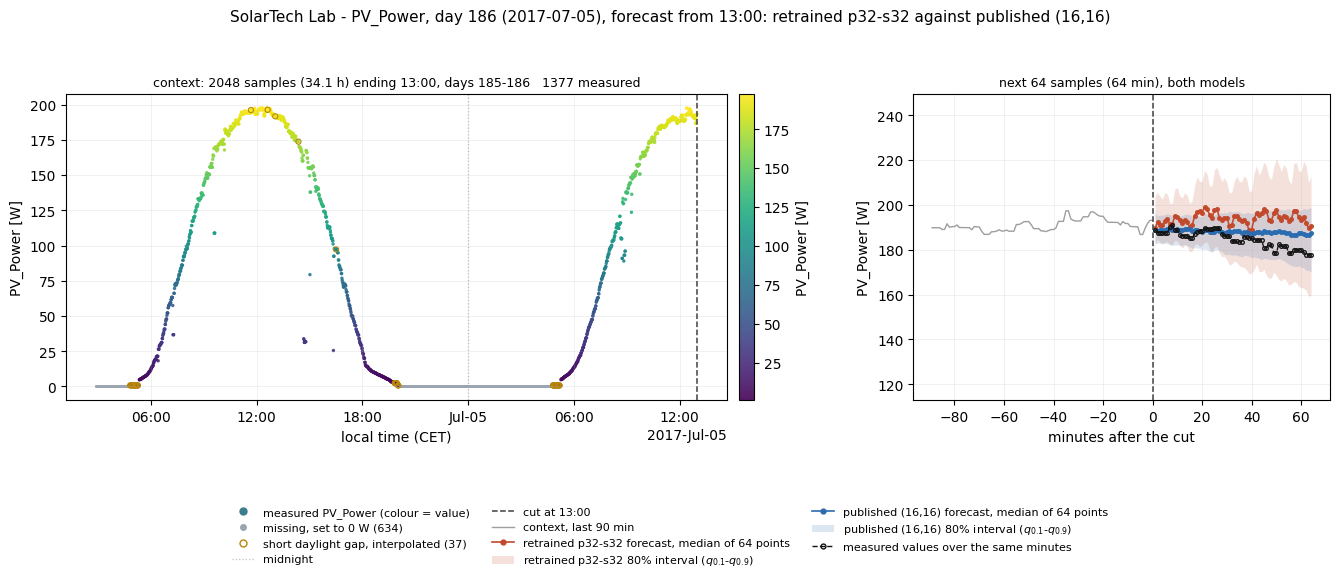

wrote _run\solar\solar_forecast_day186_1300_p32-s32_horizon.png


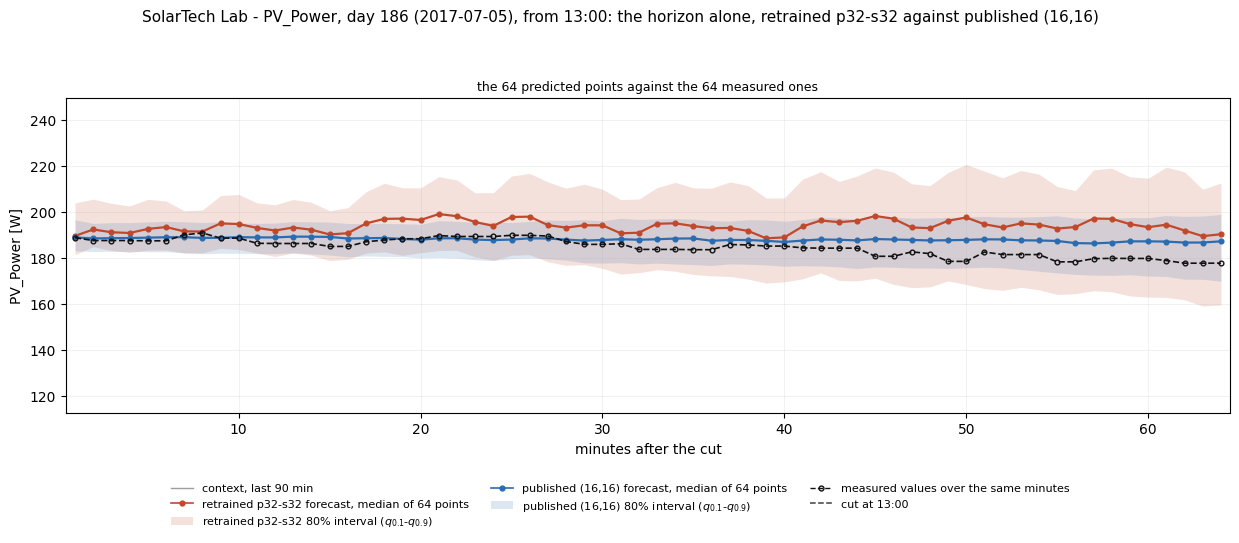

wrote _run\solar\solar_forecast_day186_1300_p32-s32_error.png


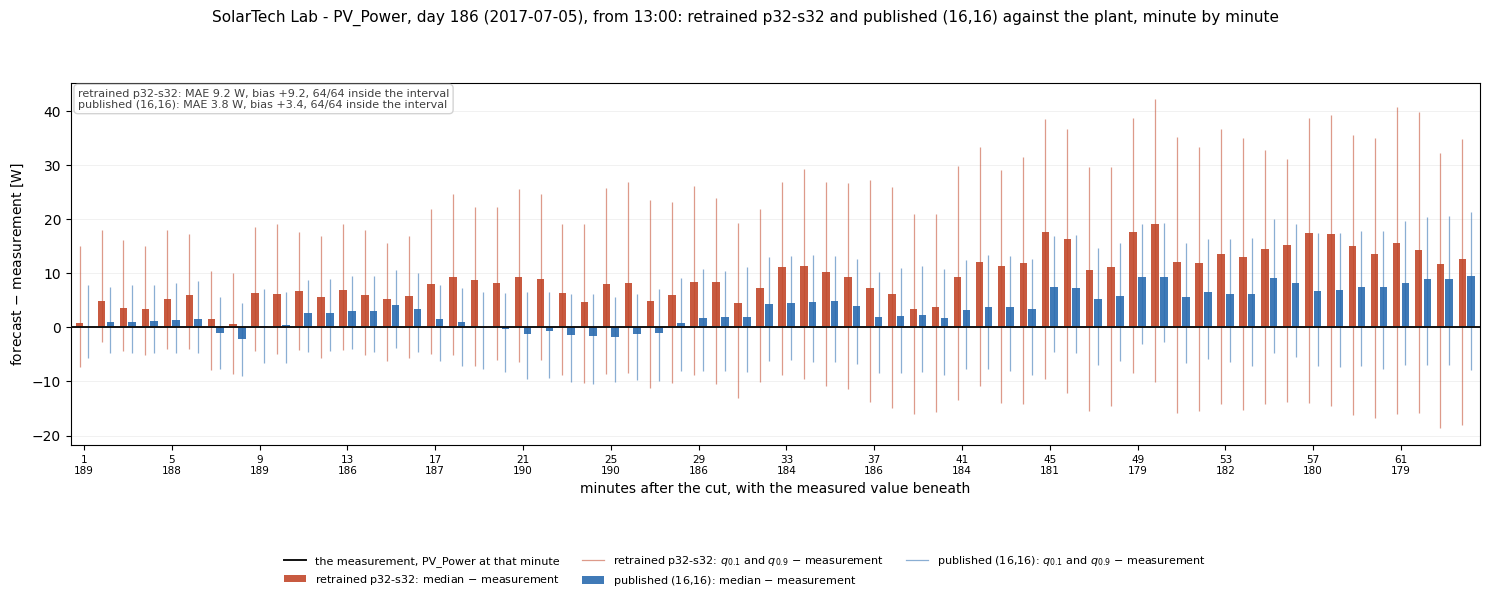

In [131]:
def pair_figures(name):
    """The three paired views for one retrained geometry against the published checkpoint."""
    names = [name, PUB]
    t = np.arange(1, WIN["horizon"] + 1)
    truth = WIN["fut"]

    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13.5, 5.8),
                                   gridspec_kw={"width_ratios": [1.9, 1.0]})
    draw_context(axL, WIN, colorbar_fig=fig)
    draw_horizon(axR, WIN, names)
    axR.set_title(f"next {PRED} samples ({PRED} min), both models", fontsize=9)
    fig.suptitle(f"SolarTech Lab - {CHANNEL}, day {WIN['doy']} ({WIN['cut'].date()}), "
                 f"forecast from {FCST_TIME}: {name} against published (16,16)",
                 y=0.985, fontsize=11)
    fig.tight_layout(rect=(0, 0.21, 1, 0.95))
    figure_legend(fig, context_handles(WIN), horizon_handles(names))
    if SAVE_FIGURES:
        p = Path(OUT_DIR) / f"{STEM}_{tag_of(name)}_both.png"
        fig.savefig(p, dpi=160, bbox_inches="tight"); print("wrote", p)
    plt.show()

    fig, ax = plt.subplots(figsize=(12.5, 5.4))
    for n in names:
        f = FC[n]
        ax.fill_between(t, f["q10"], f["q90"], color=colour_of(n), alpha=0.16, lw=0, zorder=1)
        ax.plot(t, f["q50"], color=colour_of(n), lw=1.6, marker="o", ms=3.4, zorder=3)
    ax.plot(t, truth, color=C_TRUE, lw=1.2, ls="--", marker="o", ms=3.4, mfc="none", zorder=4)
    ax.set_xlabel("minutes after the cut"); ax.set_ylabel(f"{CHANNEL} [{UNIT}]")
    ax.set_xlim(0.5, WIN["horizon"] + 0.5)
    if YLIM is not None:
        ax.set_ylim(*YLIM)
    ax.grid(alpha=0.25, lw=0.5)
    ax.set_title(f"the {PRED} predicted points against the {PRED} measured ones", fontsize=9)
    fig.suptitle(f"SolarTech Lab - {CHANNEL}, day {WIN['doy']} ({WIN['cut'].date()}), from "
                 f"{FCST_TIME}: the horizon alone, {name} against published (16,16)",
                 y=0.985, fontsize=11)
    fig.tight_layout(rect=(0, 0.13, 1, 0.94))
    figure_legend(fig, horizon_handles(names))
    if SAVE_FIGURES:
        p = Path(OUT_DIR) / f"{STEM}_{tag_of(name)}_horizon.png"
        fig.savefig(p, dpi=160, bbox_inches="tight"); print("wrote", p)
    plt.show()

    width = 0.80 / len(names)
    fig, ax = plt.subplots(figsize=(15.0, 6.0))
    for k, n in enumerate(names):
        f = FC[n]
        off = (k - (len(names) - 1) / 2) * width
        ax.vlines(t + off, f["q10"] - truth, f["q90"] - truth,
                  color=colour_of(n), lw=0.9, alpha=0.55, zorder=2)
        ax.bar(t + off, f["q50"] - truth, width=width * 0.86, color=colour_of(n),
               alpha=0.9, linewidth=0, zorder=3)
    ax.axhline(0, color=C_TRUE, lw=1.4, zorder=4)
    ax.set_xlim(0.4, WIN["horizon"] + 0.6)
    ax.set_xlabel("minutes after the cut, with the measured value beneath")
    ax.set_ylabel(f"forecast $-$ measurement [{UNIT}]")
    ax.grid(axis="y", alpha=0.25, lw=0.5); ax.set_axisbelow(True)
    ticks = t[::4]
    ax.set_xticks(ticks, [f"{i}\n{truth[i - 1]:.0f}" for i in ticks], fontsize=7.5)
    lines = [f"{n}: MAE {np.abs(FC[n]['q50'] - truth).mean():.1f} {UNIT}, "
             f"bias {(FC[n]['q50'] - truth).mean():+.1f}, "
             f"{int(((truth >= FC[n]['q10']) & (truth <= FC[n]['q90'])).sum())}/{len(t)} inside the interval"
             for n in names]
    ax.text(0.005, 0.985, "\n".join(lines), transform=ax.transAxes, va="top", ha="left",
            fontsize=8, color="0.25",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.8", alpha=0.85))
    handles = [Line2D([], [], color=C_TRUE, lw=1.4,
                      label=f"the measurement, {CHANNEL} at that minute")]
    for n in names:
        handles.append(Patch(facecolor=colour_of(n), alpha=0.9,
                             label=f"{n}: median $-$ measurement"))
        handles.append(Line2D([], [], color=colour_of(n), lw=0.9, alpha=0.55,
                              label=f"{n}: $q_{{0.1}}$ and $q_{{0.9}}$ $-$ measurement"))
    fig.suptitle(f"SolarTech Lab - {CHANNEL}, day {WIN['doy']} ({WIN['cut'].date()}), from {FCST_TIME}: "
                 f"{name} and published (16,16) against the plant, minute by minute",
                 y=0.985, fontsize=11)
    fig.tight_layout(rect=(0, 0.15, 1, 0.94))
    figure_legend(fig, handles)
    if SAVE_FIGURES:
        p = Path(OUT_DIR) / f"{STEM}_{tag_of(name)}_error.png"
        fig.savefig(p, dpi=160, bbox_inches="tight"); print("wrote", p)
    plt.show()


if RUN_FORECAST:
    for name in RETRAINED:
        pair_figures(name)


### The sweep grouped by patch size and by stride

Two figures that take the whole configured list at once. The first groups the retrained models by
patch size, the second by stride, one panel per group, and both draw **medians only**: with several
models in a panel the $80\%$ bands would overlap into a single wash and hide the curves they belong
to, so the intervals are left to the paired figures above, where there are only two of them. Within
a panel the colour runs with the parameter that varies, so the ordering is readable rather than
arbitrary.

The published checkpoint is excluded by default. Its geometry is $(16,16)$, so it would sit inside
two of these panels as if it were another member of the sweep, and it is not comparable to them in
the same sense: the retrained models differ from one another only in tokenisation geometry, while
the published one differs from all of them in training corpus as well. Setting
`GROUP_INCLUDE_PUBLISHED = True` adds it as a separate dashed reference rather than as a member.


wrote _run\solar\solar_forecast_day186_1300_bypatch.png


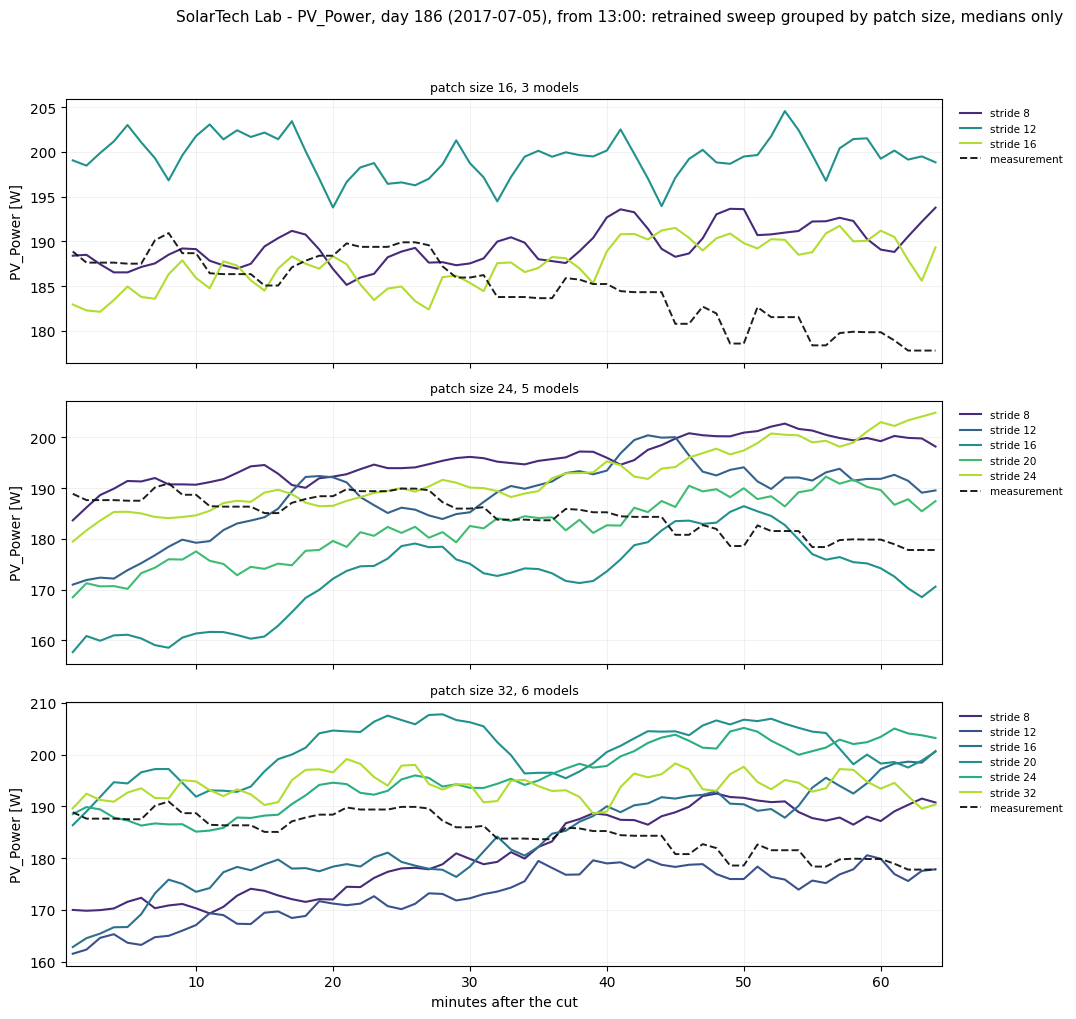

wrote _run\solar\solar_forecast_day186_1300_bystride.png


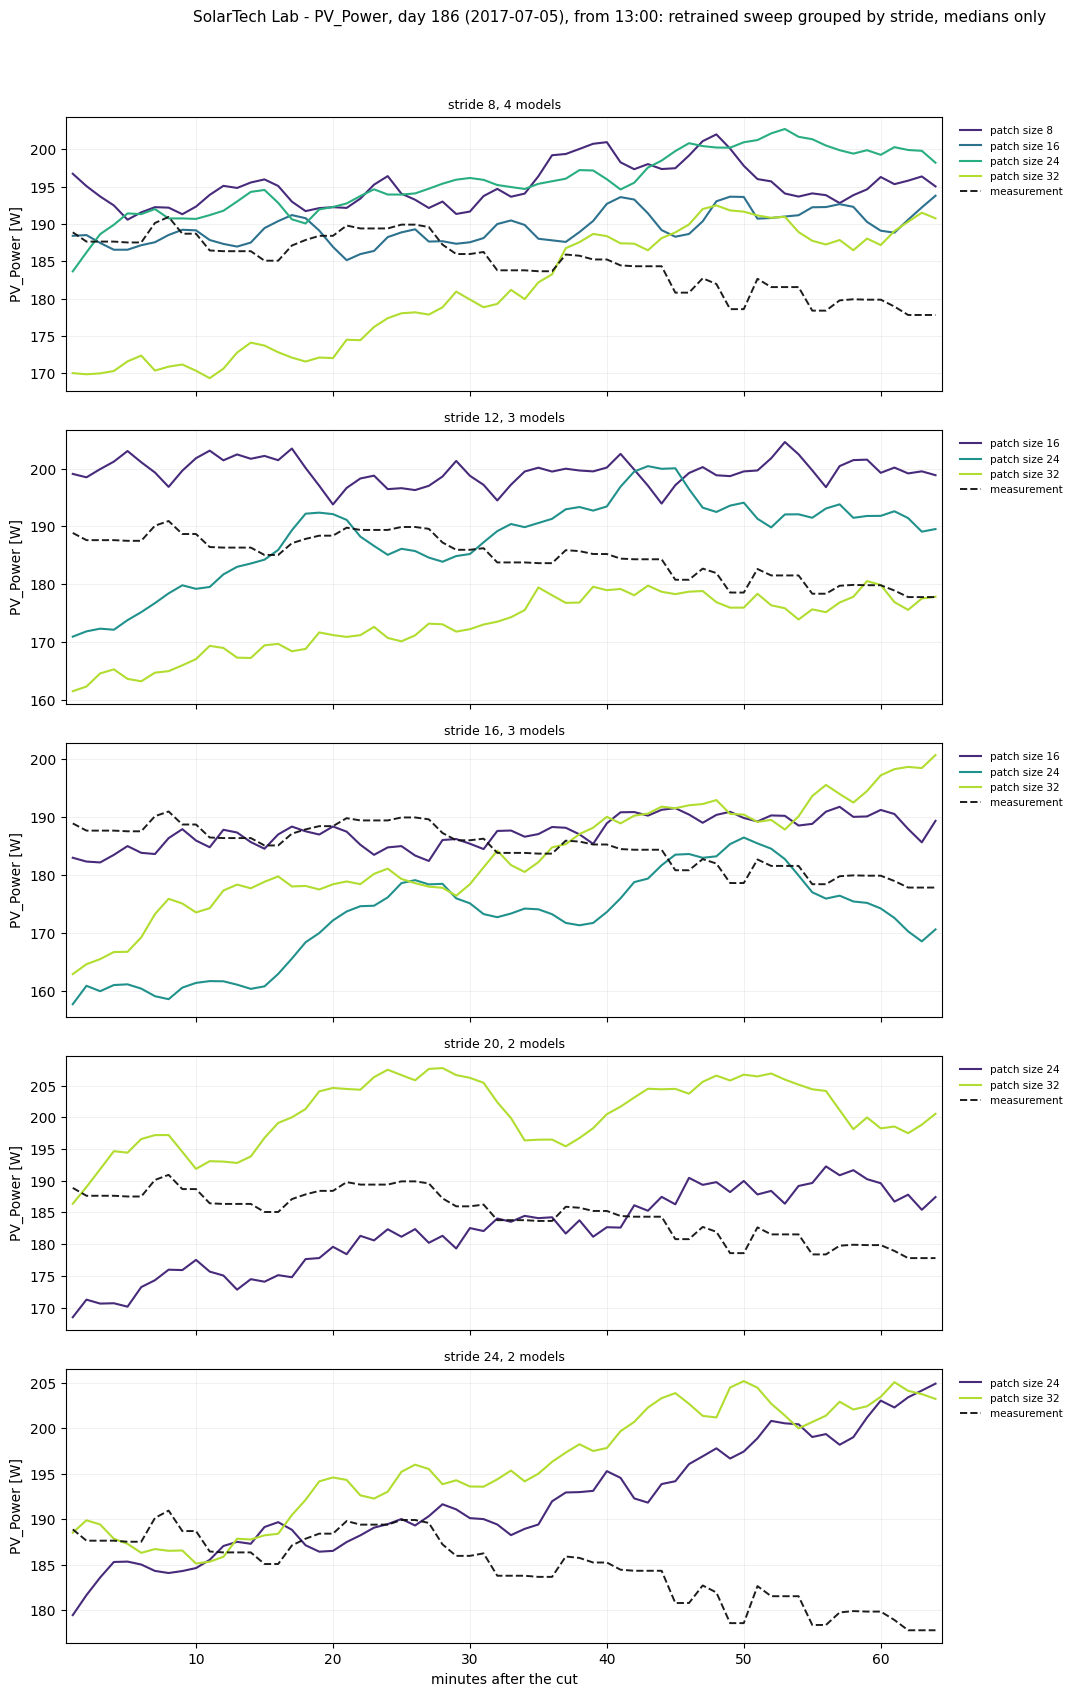

In [132]:
def _groups(by):
    """{group value: [model names]} over the retrained geometries, by 'P' or 'S'."""
    idx = 0 if by == "P" else 1
    out = {}
    for name, ps in GEOM.items():
        out.setdefault(ps[idx], []).append(name)
    other = 1 - idx
    for k in out:
        out[k].sort(key=lambda n: GEOM[n][other])
    return {k: out[k] for k in sorted(out) if len(out[k]) >= GROUP_MIN_MEMBERS}


def group_page(by, fname=None):
    """One panel per patch size (by='P') or per stride (by='S'). Medians only, no intervals."""
    groups = _groups(by)
    if not groups:
        print(f"no group by {by} reaches GROUP_MIN_MEMBERS={GROUP_MIN_MEMBERS}; nothing drawn")
        return None
    fixed, varying = ("patch size", "stride") if by == "P" else ("stride", "patch size")
    other = 1 if by == "P" else 0

    t = np.arange(1, WIN["horizon"] + 1)
    n = len(groups)
    fig, axes = plt.subplots(n, 1, figsize=(12.5, 3.4 * n), squeeze=False, sharex=True)
    cmap = colormaps["viridis"]

    for ax, (key, members) in zip(axes[:, 0], groups.items()):
        values = [GEOM[m][other] for m in members]
        lo, hi = min(values), max(values)
        for m, v in zip(members, values):
            frac = 0.0 if hi == lo else (v - lo) / (hi - lo)
            ax.plot(t, FC[m]["q50"], lw=1.5, color=cmap(0.12 + 0.76 * frac),
                    label=f"{varying} {v}")
        if GROUP_INCLUDE_PUBLISHED:
            ax.plot(t, FC[PUB]["q50"], lw=1.4, ls=(0, (4, 2)), color=C_PUBLISHED,
                    label="published (16,16), reference")
        ax.plot(t, WIN["fut"], color=C_TRUE, lw=1.4, ls="--", alpha=0.95, label="measurement")
        ax.set_ylabel(f"{CHANNEL} [{UNIT}]")
        ax.set_xlim(0.5, WIN["horizon"] + 0.5)
        ax.grid(alpha=0.25, lw=0.5)
        ax.set_title(f"{fixed} {key}, {len(members)} model{'s' if len(members) > 1 else ''}",
                     fontsize=9)
        # outside the axes: inside, a legend lands on the curves whenever a panel is full
        ax.legend(fontsize=7.5, ncol=1, frameon=False, loc="upper left",
                  bbox_to_anchor=(1.01, 1.0))
    axes[-1, 0].set_xlabel("minutes after the cut")

    fig.suptitle(f"SolarTech Lab - {CHANNEL}, day {WIN['doy']} ({WIN['cut'].date()}), from "
                 f"{FCST_TIME}: retrained sweep grouped by {fixed}, medians only",
                 y=0.995, fontsize=11)
    fig.tight_layout(rect=(0, 0, 0.87, 0.97))
    if SAVE_FIGURES:
        p = Path(OUT_DIR) / (fname or f"{STEM}_by{'patch' if by == 'P' else 'stride'}.png")
        fig.savefig(p, dpi=160, bbox_inches="tight"); print("wrote", p)
    plt.show()
    return fig


if RUN_FORECAST and len(RETRAINED) >= 2:
    group_page("P")
    group_page("S")
elif RUN_FORECAST:
    print(f"{len(RETRAINED)} retrained geometry configured; the grouped figures need at least two. "
          f"Set FCST_GEOMETRIES to the sweep list in section 0.")


## 5, Reading these minutes in the report's units

The synthetic design is written at $f_s = 512$ Hz and this series is one sample per minute. The two
are reconciled **without resampling**, because the quantity the report carries between them is
dimensionless.

A tokeniser sees a sequence of samples and has no notion of seconds. A component whose period is
$T$ **samples** completes $P/T$ cycles inside one patch and $S/T$ inside one stride, whatever the
wall-clock rate:

$$\mathrm{cpp} = \frac{P}{T}, \qquad \mathrm{cps} = \frac{S}{T}.$$

So a solar window is fed to the model as-is, and its sample index is read as if sampled at
$f_s = 512$ Hz. A component of period $T$ minutes then appears at $f = 512/T$ Hz on the notebook's
axis and at the same $\mathrm{cpp}$ it would have had in the synthetic study. The lock condition —
a whole number of cycles per patch or per stride — is therefore **the same predicate in both
worlds**, which is what makes the synthetic result transferable at all.

The table below is that mapping for the reference geometry.

In [133]:
periods_min = [4, 8, 12, 16, 20, 24, 32, 48, 60, 96, 120, 240, 480]
tab = pd.DataFrame({
    "period [min]": periods_min,
    "f at fs=512 [Hz]": [round(FS / T, 2) for T in periods_min],
    "cpp (P=%d)" % REF_P: [round(REF_P / T, 4) for T in periods_min],
    "cps (S=%d)" % REF_S: [round(REF_S / T, 4) for T in periods_min],
})
tab["patch lock"] = ["yes" if abs(v - round(v)) < 1e-9 and v >= 1 else ""
                     for v in (REF_P / np.array(periods_min))]
tab["stride lock"] = ["yes" if abs(v - round(v)) < 1e-9 and v >= 1 else ""
                      for v in (REF_S / np.array(periods_min))]
print(f"reference geometry P={REF_P}, S={REF_S}\n")
print(tab.to_string(index=False))
print(f"\nA candidate site is a whole number of cycles per patch or per stride.")
print(f"At P={REF_P} that is a period of {REF_P} minutes (cpp=1), {REF_P/2:g} minutes (cpp=2), "
      f"{REF_P/3:.2f} minutes (cpp=3), and so on.")


reference geometry P=16, S=16

 period [min]  f at fs=512 [Hz]  cpp (P=16)  cps (S=16) patch lock stride lock
            4            128.00      4.0000      4.0000        yes         yes
            8             64.00      2.0000      2.0000        yes         yes
           12             42.67      1.3333      1.3333                       
           16             32.00      1.0000      1.0000        yes         yes
           20             25.60      0.8000      0.8000                       
           24             21.33      0.6667      0.6667                       
           32             16.00      0.5000      0.5000                       
           48             10.67      0.3333      0.3333                       
           60              8.53      0.2667      0.2667                       
           96              5.33      0.1667      0.1667                       
          120              4.27      0.1333      0.1333                       
          240        

## 6, What this notebook is for, and what it is not

It shows the telemetry the agent of Section 11 would read, it decides which days can be handed to
the decomposition notebook, and it illustrates one forecast the agent would be acting on. It
performs no test: the photovoltaic series is the application domain of this study and not an
experimental corpus, and no hypothesis is evaluated on it. In particular the two-model comparison
of section 4 is an illustration on a single day, not an evaluation of either model.